In [1]:
# Obiettivo del Notebook
# Approfondimento delle tecniche avanzate di modellazione su larga scala. Il notebook esplora l'applicazione 
# di architetture di Deep Learning per la gestione di dataset ospedalieri complessi, con l'obiettivo di 
# supportare i processi decisionali (screening preventivo vs ottimizzazione delle risorse).

# Attività Svolte:
# Feature Engineering: Gestione di dataset ad alta dimensionalità (oltre 100k record) con variabili categoriche (codici ICD-9, specializzazioni).
# Deep Learning Frameworks: Implementazione e confronto di reti neurali feed-forward utilizzando sia PyTorch che TensorFlow.
# Gestione dello Sbilanciamento: Applicazione della tecnica SMOTE all'interno di una pipeline di modellazione per bilanciare le classi.
# Valutazione dell'Incertezza: Studio della calibrazione delle probabilità tramite Calibration Curves e Brier Score per garantire la robustezza clinica delle predizioni.
# Conclusioni Operative: Analisi critica dei framework rispetto agli obiettivi di prevenzione (Recall-oriented) e gestione risorse (Precision-oriented).

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, GroupShuffleSplit, StratifiedGroupKFold
import scipy.stats as stats
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, roc_auc_score, 
                             roc_curve, precision_score, recall_score, f1_score, 
                             ConfusionMatrixDisplay, brier_score_loss)
from sklearn.inspection import permutation_importance
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import calibration_curve

In [3]:
df_hospital = pd.read_csv("diabetes+130-us+hospitals+for+years+1999-2008\diabetic_data.csv")

In [4]:
print("Prime 5 righe del Dataset")
display(df_hospital.head())

Prime 5 righe del Dataset


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
print("\nInformazioni generali")
df_hospital.info()


Informazioni generali
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non

In [6]:
#DataSet decisamente molto più grande 101766 righe e 50 colonne; quindi 50 feature.
#Inoltre notiamo che non tutte le variabili sono numeriche (13), alcune variabili sono categoriche (37)

In [7]:
print("\nStatistiche descrittive")
display(df_hospital.describe())


Statistiche descrittive


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [8]:
# 1. Identificazione dei '?' (Valori mancanti espliciti nel dataset)
# Creiamo un conteggio per ogni colonna che contiene almeno un '?'
missing_questions = (df_hospital == '?').sum()
missing_questions = missing_questions[missing_questions > 0].sort_values(ascending=False)

# 2. Identificazione degli Zeri sospetti (Valori numerici)
# Definiamo le colonne dove lo zero è clinicamente impossibile o altamente sospetto
# Nota: number_emergency, number_inpatient ecc. POSSONO essere zero.
cols_numeric_critical = [
    'time_in_hospital', 
    'num_lab_procedures', 
    'num_medications', 
    'number_diagnoses'
]

zeros_report = (df_hospital[cols_numeric_critical] == 0).sum()
zeros_report = zeros_report[zeros_report > 0]

# 3. Identificazione di valori "Unknown" o "Invalid" nelle stringhe
invalid_gender_count = df_hospital[df_hospital['gender'].isin(['Unknown/Invalid'])].shape[0]

# 4. Creazione del Report Riassuntivo Finale
print("=== ANALISI CRITICITÀ DATI (PRIMA DELLA PULIZIA) ===\n")

if not missing_questions.empty:
    print("1. VALORI MANCANTI IDENTIFICATI CON '?'")
    for col, count in missing_questions.items():
        percentage = (count / len(df_hospital)) * 100
        print(f"   - {col}: {count} occorrenze ({percentage:.2f}%)")
else:
    print("1. Nessun '?' trovato.")

print("\n2. ZERI CLINICAMENTE SOSPETTI (In colonne numeriche)")
if not zeros_report.empty:
    for col, count in zeros_report.items():
        print(f"   - {col}: {count} zeri trovati")
else:
    print("   - Nessuno zero anomalo trovato nelle colonne critiche.")

print(f"\n3. VALORI CATEGORICI INVALIDI")
print(f"   - gender (Unknown/Invalid): {invalid_gender_count} occorrenze")

# 5. Visualizzazione opzionale: Tabella riassuntiva per le anomalie principali
report_df = pd.DataFrame({
    'Colonna': missing_questions.index,
    'Conteggio ?': missing_questions.values,
    'Percentuale %': (missing_questions.values / len(df_hospital)) * 100
})

=== ANALISI CRITICITÀ DATI (PRIMA DELLA PULIZIA) ===

1. VALORI MANCANTI IDENTIFICATI CON '?'
   - weight: 98569 occorrenze (96.86%)
   - medical_specialty: 49949 occorrenze (49.08%)
   - payer_code: 40256 occorrenze (39.56%)
   - race: 2273 occorrenze (2.23%)
   - diag_3: 1423 occorrenze (1.40%)
   - diag_2: 358 occorrenze (0.35%)
   - diag_1: 21 occorrenze (0.02%)

2. ZERI CLINICAMENTE SOSPETTI (In colonne numeriche)
   - Nessuno zero anomalo trovato nelle colonne critiche.

3. VALORI CATEGORICI INVALIDI
   - gender (Unknown/Invalid): 3 occorrenze


=== NUOVO CONTEGGIO VALORI MANCANTI (NaN) ===
                   Totale NaN  Percentuale %
weight                  98569      96.858479
max_glu_serum           96420      94.746772
A1Cresult               84748      83.277322
medical_specialty       49949      49.082208
payer_code              40256      39.557416
race                     2273       2.233555
diag_3                   1423       1.398306
diag_2                    358       0.351787
diag_1                     21       0.020636
gender                      3       0.002948


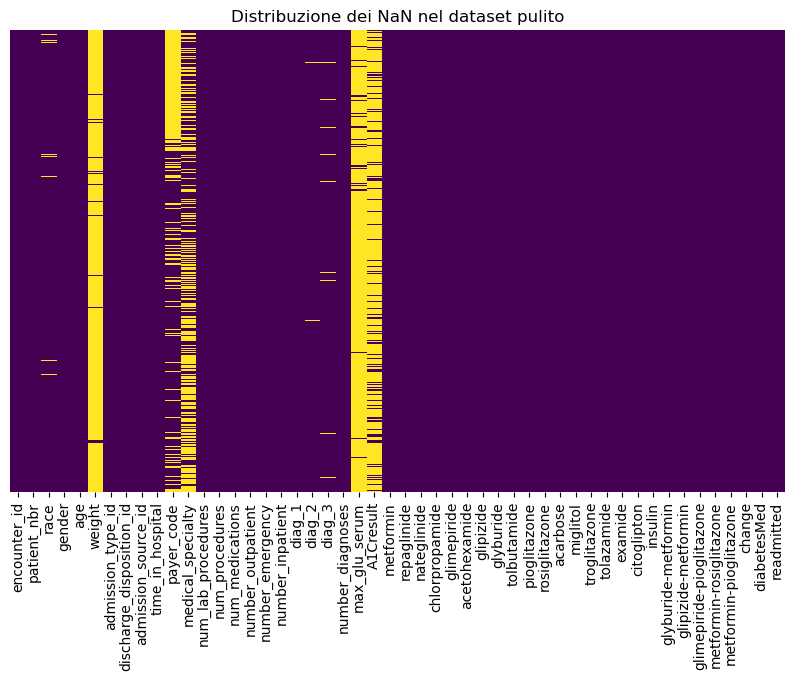

In [9]:
#ora i valori mancanti sia numerici che non devono essere sostituiti con valori NaN
df_hospital_clean = df_hospital.copy()
#1)sostituisco ? con NaN
df_hospital_clean.replace('?', np.nan, inplace=True)
#2)sostituisco valori 'Unknown/Invalid' con NaN
df_hospital_clean.replace('Unknown/Invalid', np.nan, inplace=True)
#3). Sostituzione degli zeri clinicamente impossibili con NaN
# Solo nelle colonne dove lo zero non ha senso logico
cols_zero_invalid = ['time_in_hospital', 'num_lab_procedures', 'num_medications']
for col in cols_zero_invalid:
    df_hospital_clean[col] = df_hospital_clean[col].astype(float)
    df_hospital_clean[col] = df_hospital_clean[col].replace(0, np.nan)

#4) Verifica finale: vediamo il nuovo conteggio dei veri NaN
print("=== NUOVO CONTEGGIO VALORI MANCANTI (NaN) ===")
nan_report = df_hospital_clean.isnull().sum()
nan_report = nan_report[nan_report > 0].sort_values(ascending=False)

# Aggiungiamo la percentuale per chiarezza
nan_summary = pd.DataFrame({
    'Totale NaN': nan_report,
    'Percentuale %': (nan_report / len(df_hospital_clean)) * 100
})

print(nan_summary)

#densità dei vuoti
plt.figure(figsize=(10, 6))
sns.heatmap(df_hospital_clean.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Distribuzione dei NaN nel dataset pulito')
plt.show()

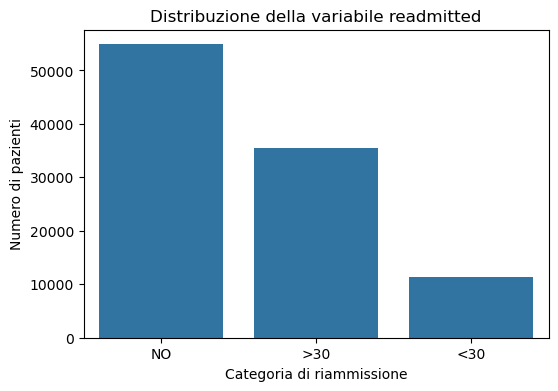

In [10]:
#Grafico per l'osservazione della distrubzionde della variabile target
plt.figure(figsize=(6,4))
sns.countplot(x="readmitted", data=df_hospital_clean)
#countplot conta quante osservazioni appartengono ad una classe
plt.title("Distribuzione della variabile readmitted")
plt.xlabel("Categoria di riammissione")
plt.ylabel("Numero di pazienti")
plt.show()

In [11]:
#La variabile indica se un paziente è stato riammesso in ospedale dopo le dimissioni.
#Osserviamo 3 categorie: riammissione < 30, > 30, NO; le tre categorie non sono perfettamente 
#bilanciate. La categoria non riammessi o riammessi dopo più di 30 giorni sono più frequenti
#rispetto alla riammissioni entro 30 giorni.

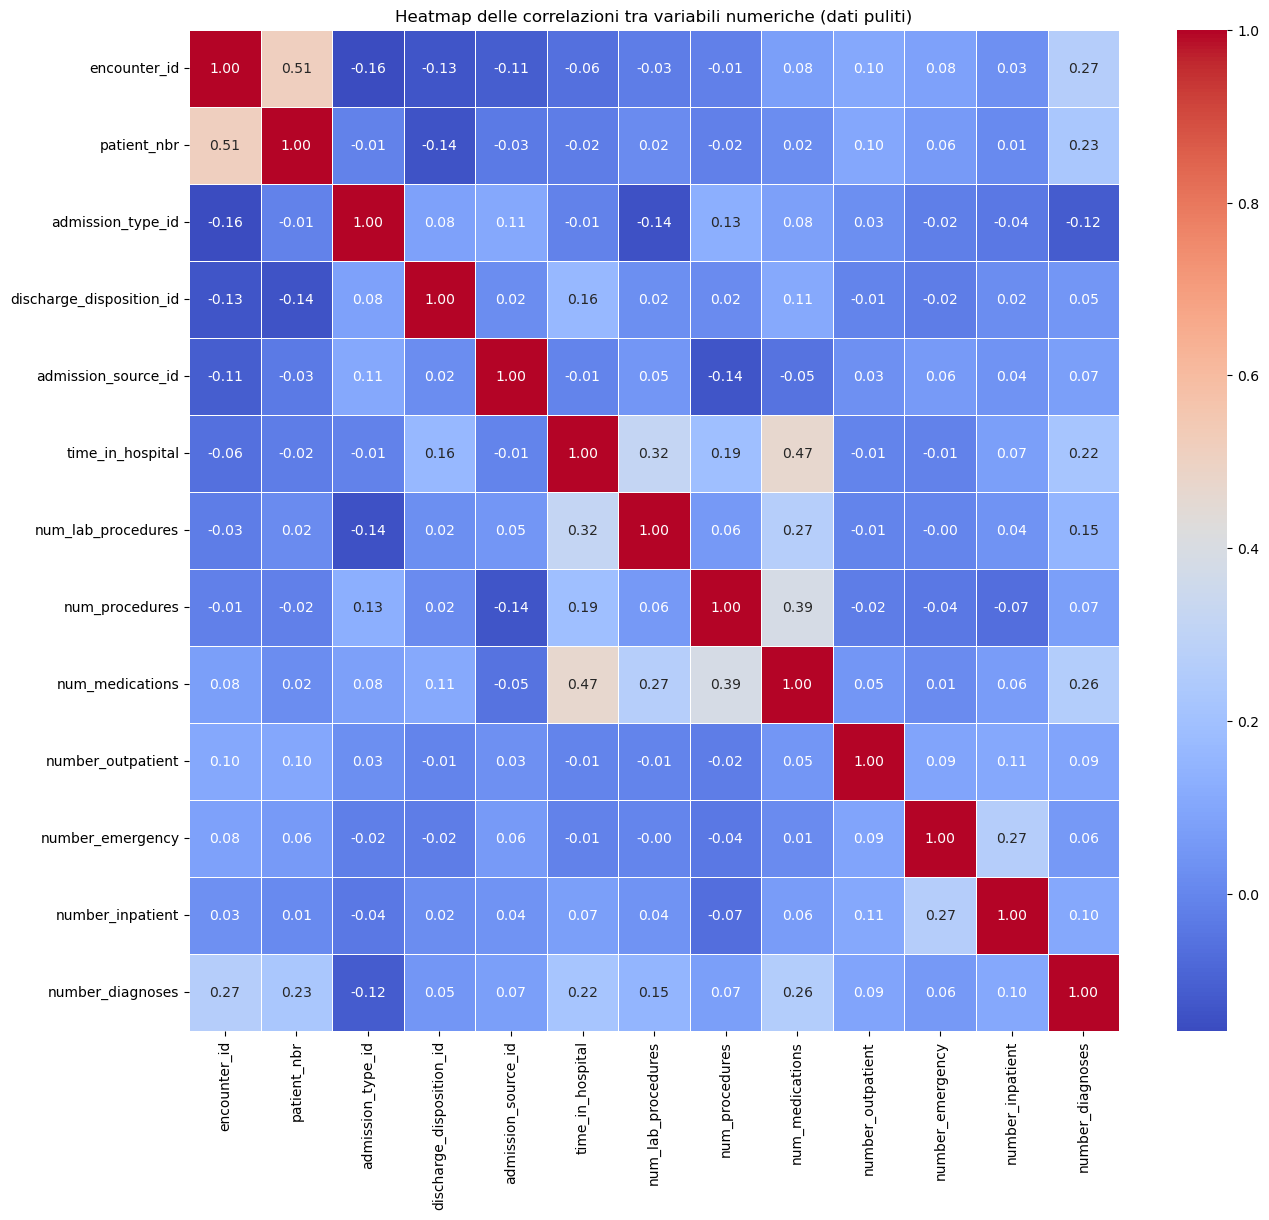

In [12]:
#seleziono solo le feature numeriche
plt.figure(figsize=(15,13))
# Calcoliamo la correlazione solo sulle colonne numeriche
corr_matrix = df_hospital_clean.corr(numeric_only=True)

# Generiamo la heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Heatmap delle correlazioni tra variabili numeriche (dati puliti)")
plt.show()

In [13]:
#In generale, la matrice mostra correlazioni deboli tra la maggior parte delle variabili, indicando una bassa ridondanza 
#dei dati. Si osservano però alcune relazioni degne di nota:
#RELAZIONI CLINICHE: esiste una correlazione moderata tra num_medications e time_in_hospital (0.47), seguita da quella tra
#num_medications e num_procedures (0.39). Ciò suggerisce che la complessità del trattamento e la durata della degenza sono legate tra loro.
#RELAZIONI TECNICHE: La correlazione tra encounter_id e patient_nbr (0.51) è dovuto alla natura incrementale degli ID e non ha valore predittivo.
#INDIPENDENZA: variabili relative ai pregressi (emergency, outpatient, inpatient) mostrano correlazioni quasi nulle con la durata del ricovero attuale,
#suggerendo che la degenza non è fortemente influenzata dalla frequenza delle visite precedenti.

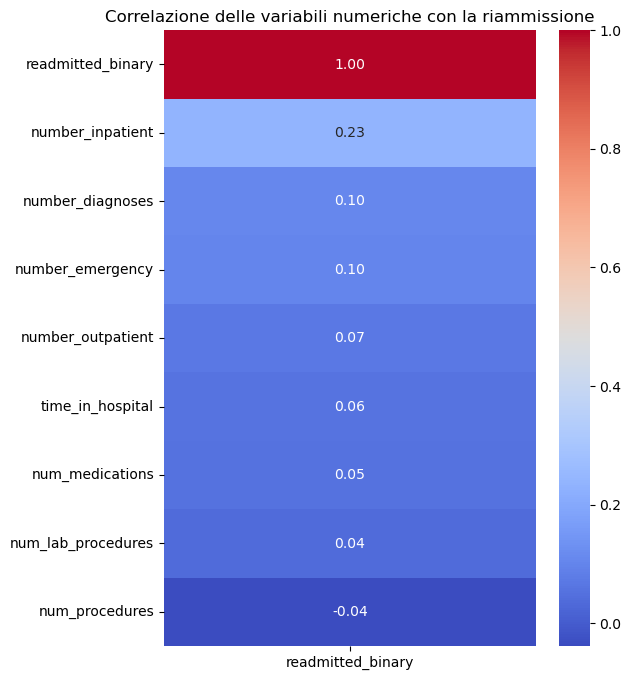

<Axes: >

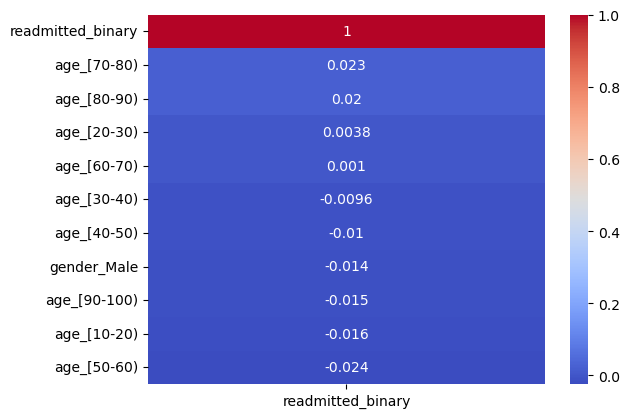

In [14]:
#correlazione tra le features e la variabile readmitted
#per permettere di fare questa correlazione calcoliamo la versione numerica della variabile readmitted
df_hospital_clean['readmitted_binary'] = df_hospital_clean['readmitted'].map({
    "NO":0,
    ">30":1,
    "<30":2
})
cols_to_corr = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 
    'num_medications', 'number_outpatient', 'number_emergency', 
    'number_inpatient', 'number_diagnoses', 'readmitted_binary'
]
df_corr = df_hospital_clean[cols_to_corr]
corr_matrix = df_corr.corr()
plt.figure(figsize=(6,8))
sns.heatmap(corr_matrix[['readmitted_binary']].sort_values(by='readmitted_binary', ascending=False), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlazione delle variabili numeriche con la riammissione")
plt.show()

# Creiamo le variabili dummy per le colonne categoriche scelte
df_with_dummies = pd.get_dummies(df_hospital_clean[['gender', 'age', 'readmitted_binary']], drop_first=True)

# Calcoliamo la correlazione
dummy_corr = df_with_dummies.corr()[['readmitted_binary']].sort_values(by='readmitted_binary', ascending=False)

# Heatmap
sns.heatmap(dummy_corr, annot=True, cmap="coolwarm")

In [15]:
#Le correlazioni tra le variabili numeriche e la riammissione (readmitted_binary) risultano estremamente deboli,
#con quasi tutti i valori inferiori a 0.10. L'unica eccezione parziale è number_inpatient (0.23), che si conferma
#il principale indicatore numerico: un paziente che è già stato ricoverato in passato ha una probabilità leggermente superiore di essere riammesso.
#Variabili cliniche come time_in_hospital o num_medications non sembrano influenzare direttamente la riammissione in modo lineare.
#Questo suggerisce che la riammissione è un fenomeno complesso che non può essere spiegato da un singolo fattore numerico,
#ma richiede probabilmente un'analisi congiunta di variabili categoriche (es. patologie pregresse, età) e l'utilizzo di modelli di machine learning
#capaci di cogliere interazioni non lineari tra i dati.
#Per l'analisi delle variabili categoriche, è stata effettuata una selezione mirata (age, gender) anziché includerle tutte indistintamente per diversi motivi tecnici:
#1) Molte variabili categoriche (come i codici diagnostici specifici) hanno centinaia di valori unici. Trasformarle tutte in dummy variables avrebbe creato migliaia di colonne,
#rendendo la matrice illeggibile.
#2) Sono state privilegiate le variabili che, da letteratura medica, hanno una probabile influenza sulla riammissione, evitando variabili puramente amministrative o con troppi dati mancanti.
#3) Includere variabili con categorie rare o irrilevanti introduce 'rumore' nei dati, che può portare a correlazioni casuali e rendere il modello meno affidabile.


Analisi della feature: admission_type_id


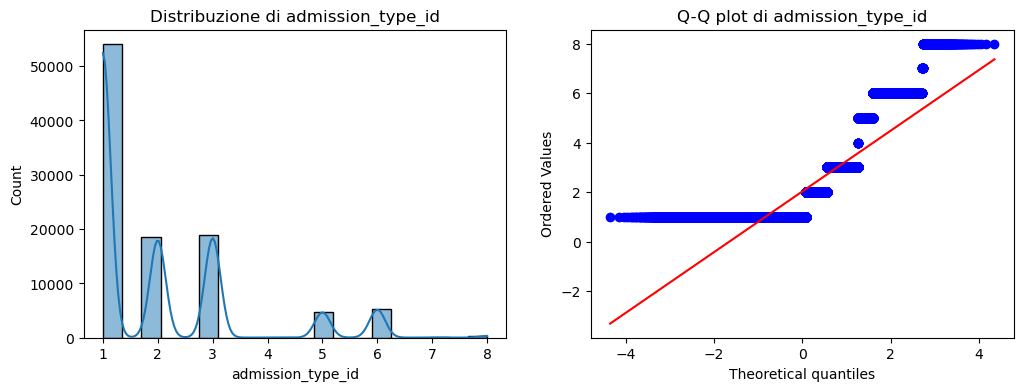

Test Shapiro-Wilk: admission_type_id ha distribuzione asimmetrica o valori estremi (p=0.0000)
Skewness (Asimmetria): 1.59 (Coda a destra)
------------------------------------------------------------

Analisi della feature: discharge_disposition_id


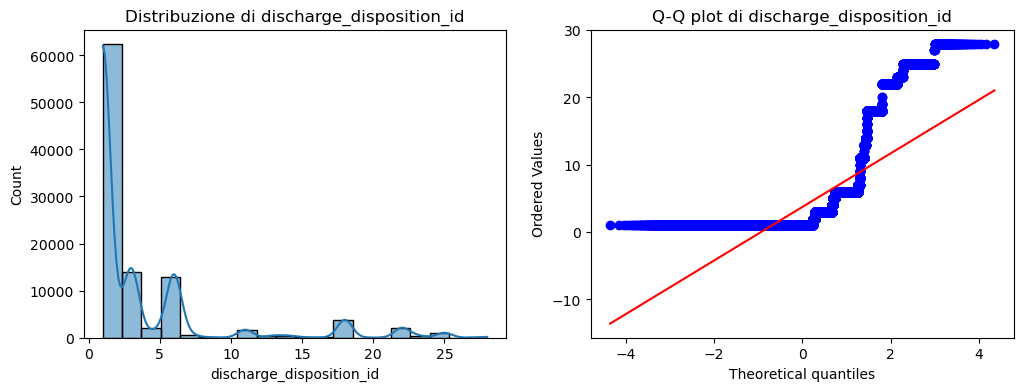

Test Shapiro-Wilk: discharge_disposition_id ha distribuzione asimmetrica o valori estremi (p=0.0000)
Skewness (Asimmetria): 2.56 (Coda a destra)
------------------------------------------------------------

Analisi della feature: admission_source_id


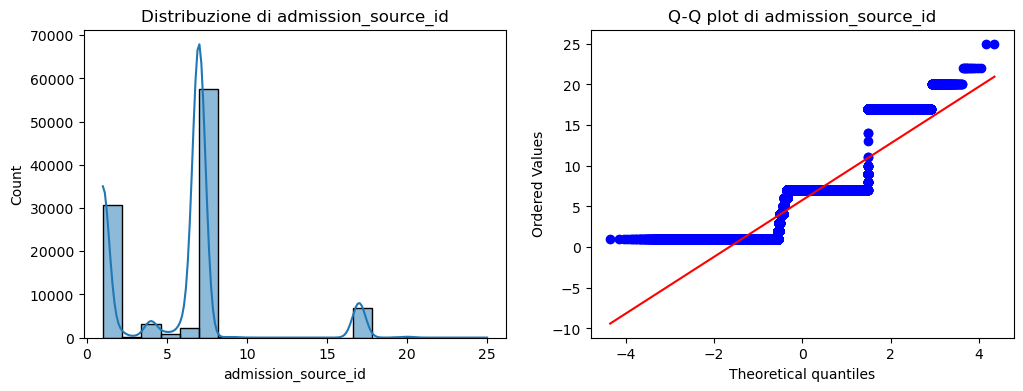

Test Shapiro-Wilk: admission_source_id ha distribuzione asimmetrica o valori estremi (p=0.0000)
Skewness (Asimmetria): 1.03 (Coda a destra)
------------------------------------------------------------

Analisi della feature: time_in_hospital


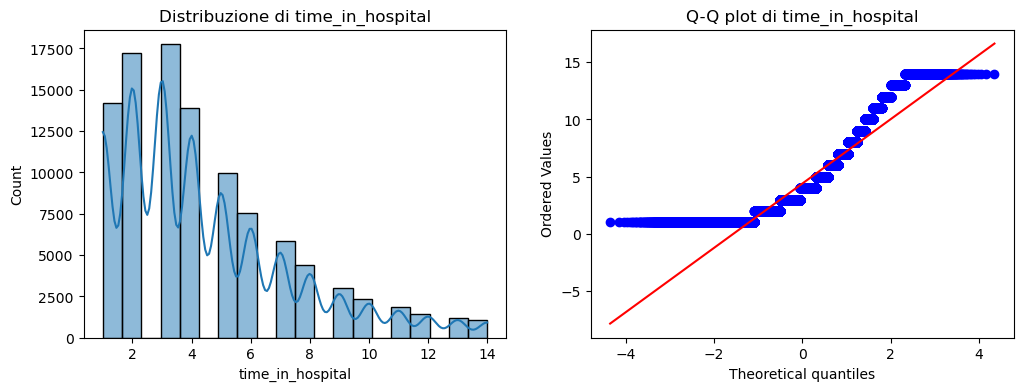

Test Shapiro-Wilk: time_in_hospital ha distribuzione asimmetrica o valori estremi (p=0.0000)
Skewness (Asimmetria): 1.13 (Coda a destra)
------------------------------------------------------------

Analisi della feature: num_lab_procedures


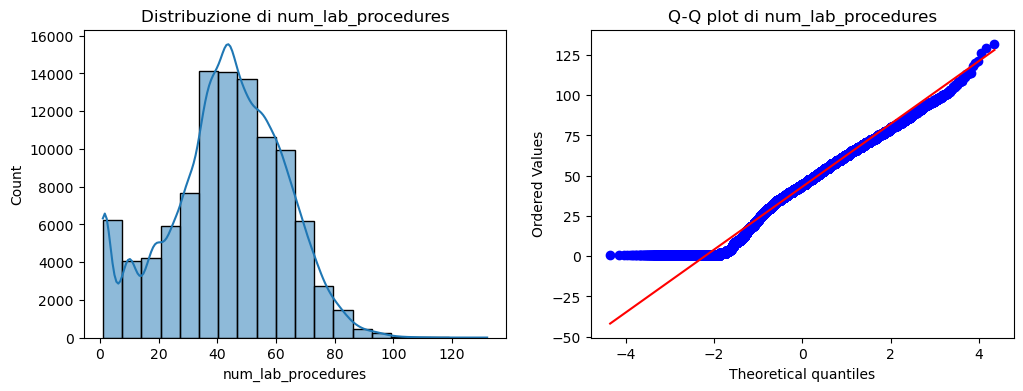

Test Shapiro-Wilk: num_lab_procedures ha distribuzione asimmetrica o valori estremi (p=0.0000)
Skewness (Asimmetria): -0.24 (Coda a sinistra)
------------------------------------------------------------

Analisi della feature: num_procedures


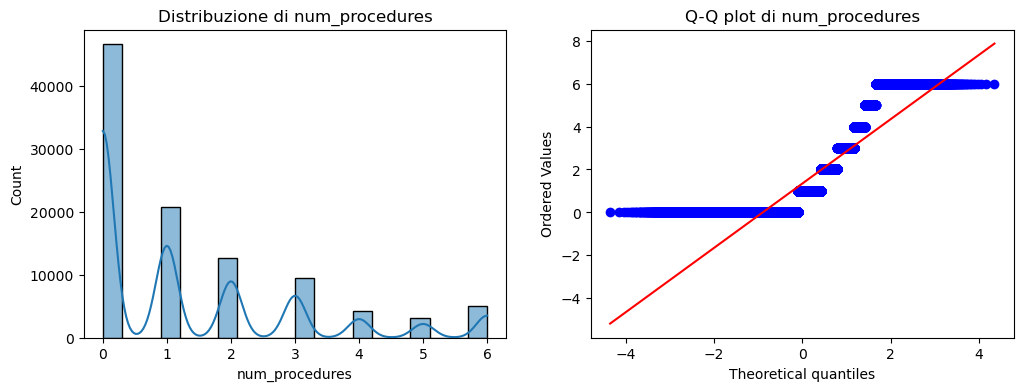

Test Shapiro-Wilk: num_procedures ha distribuzione asimmetrica o valori estremi (p=0.0000)
Skewness (Asimmetria): 1.32 (Coda a destra)
------------------------------------------------------------

Analisi della feature: num_medications


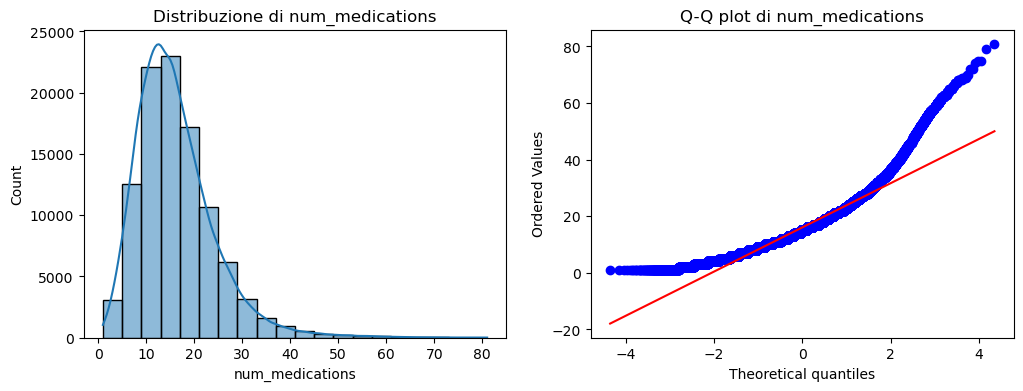

Test Shapiro-Wilk: num_medications ha distribuzione asimmetrica o valori estremi (p=0.0000)
Skewness (Asimmetria): 1.33 (Coda a destra)
------------------------------------------------------------

Analisi della feature: number_outpatient


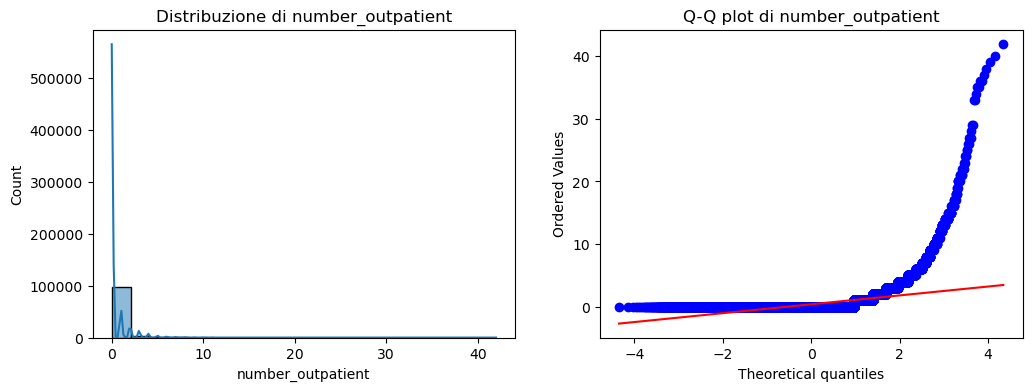

Test Shapiro-Wilk: number_outpatient ha distribuzione asimmetrica o valori estremi (p=0.0000)
Skewness (Asimmetria): 8.83 (Coda a destra)
------------------------------------------------------------

Analisi della feature: number_emergency


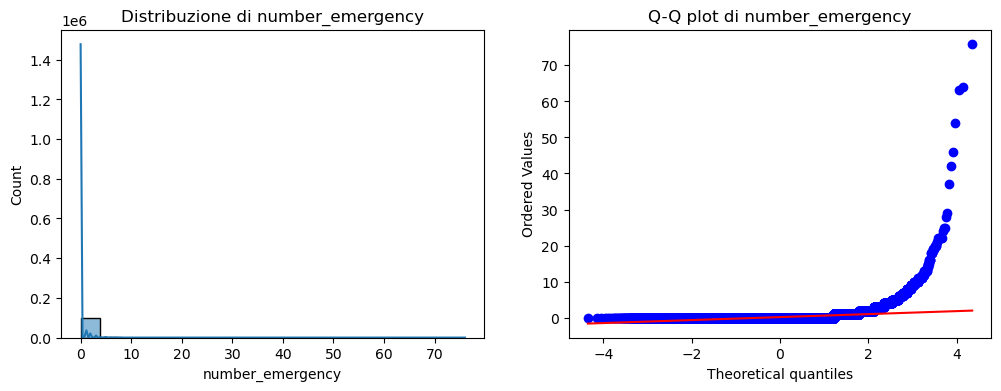

Test Shapiro-Wilk: number_emergency ha distribuzione asimmetrica o valori estremi (p=0.0000)
Skewness (Asimmetria): 22.86 (Coda a destra)
------------------------------------------------------------

Analisi della feature: number_inpatient


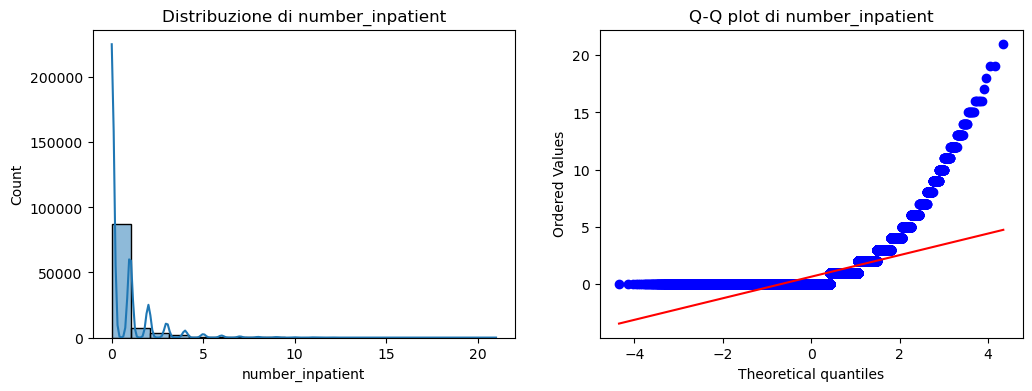

Test Shapiro-Wilk: number_inpatient ha distribuzione asimmetrica o valori estremi (p=0.0000)
Skewness (Asimmetria): 3.61 (Coda a destra)
------------------------------------------------------------

Analisi della feature: number_diagnoses


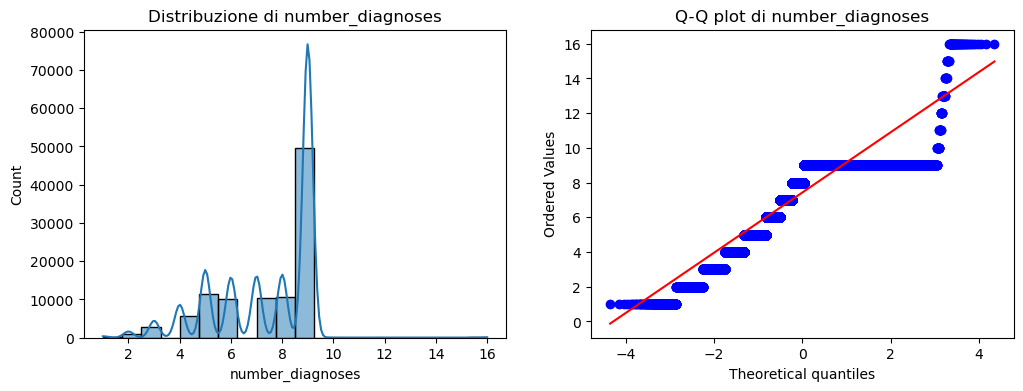

Test Shapiro-Wilk: number_diagnoses ha distribuzione asimmetrica o valori estremi (p=0.0000)
Skewness (Asimmetria): -0.88 (Coda a sinistra)
------------------------------------------------------------

Analisi della feature: readmitted_binary


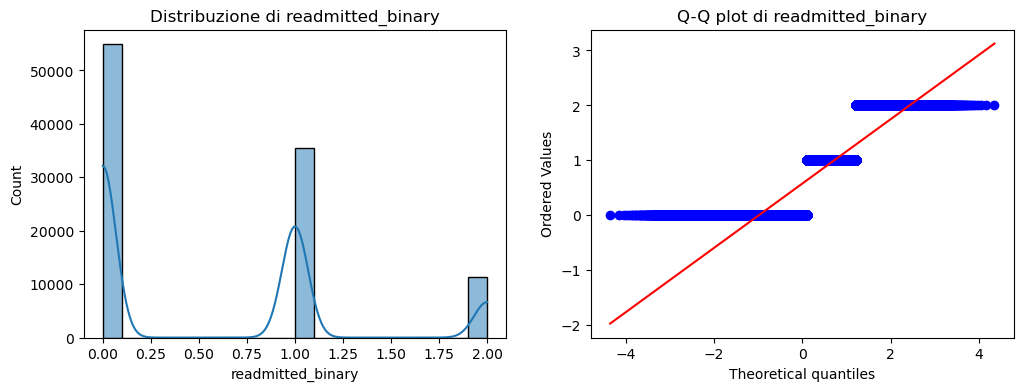

Test Shapiro-Wilk: readmitted_binary ha distribuzione asimmetrica o valori estremi (p=0.0000)
Skewness (Asimmetria): 0.78 (Coda a destra)
------------------------------------------------------------


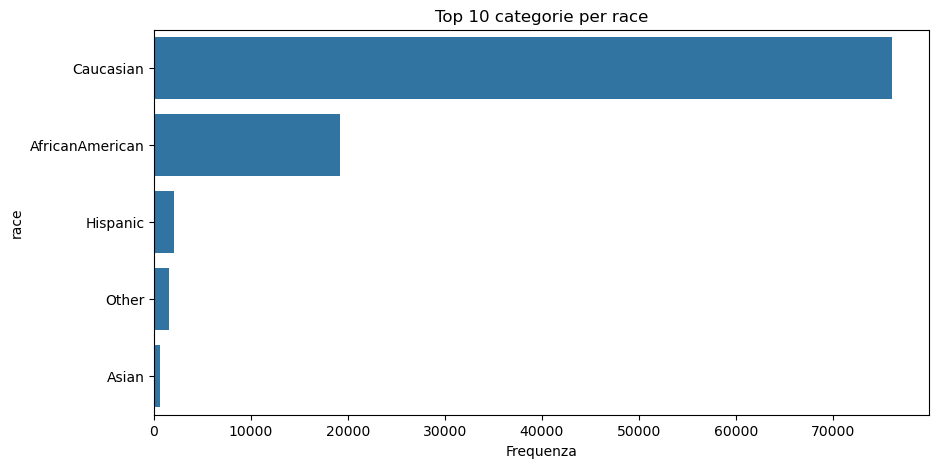

Commento: race ha 5 categorie uniche.
------------------------------------------------------------


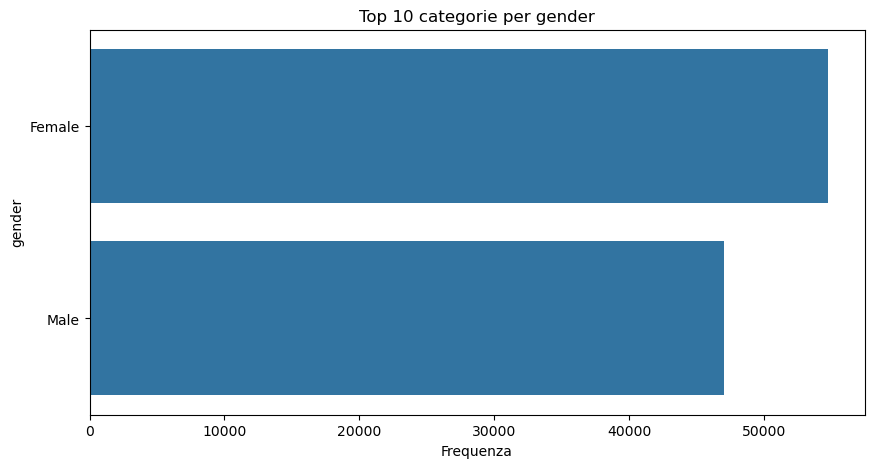

Commento: gender ha 2 categorie uniche.
------------------------------------------------------------


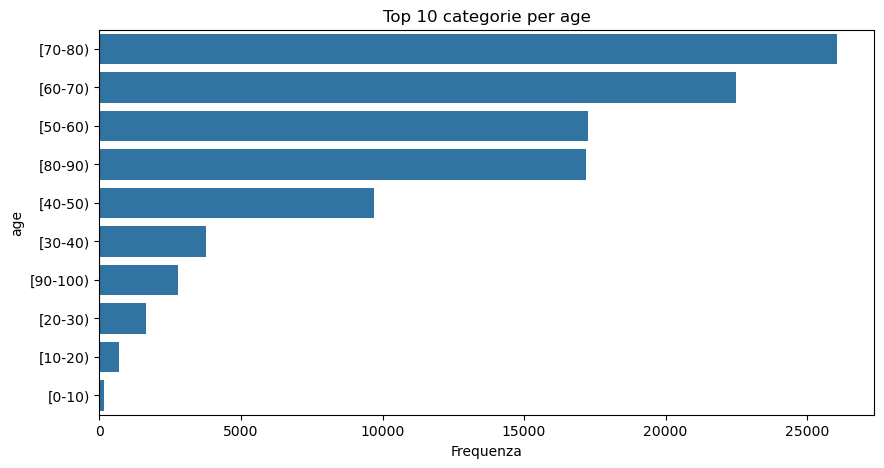

Commento: age ha 10 categorie uniche.
------------------------------------------------------------


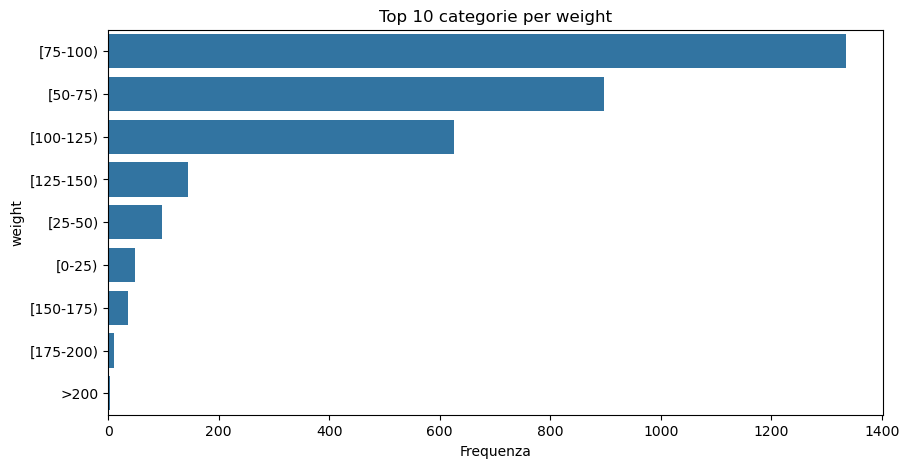

Commento: weight ha 9 categorie uniche.
------------------------------------------------------------


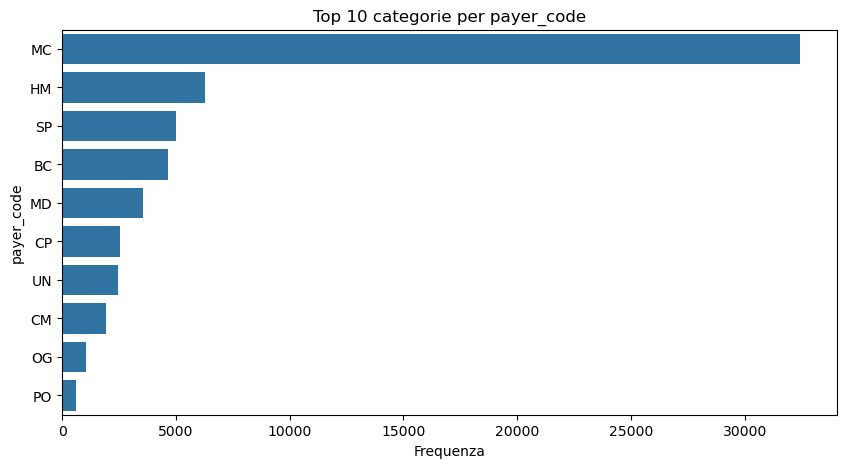

Commento: payer_code ha 17 categorie uniche.
Nota: Il grafico mostra solo le 10 categorie più frequenti.
------------------------------------------------------------


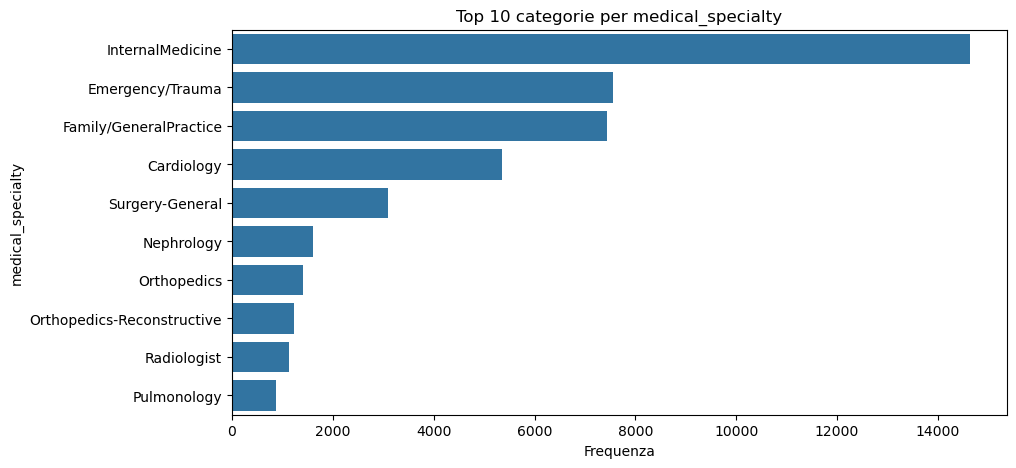

Commento: medical_specialty ha 72 categorie uniche.
Nota: Il grafico mostra solo le 10 categorie più frequenti.
------------------------------------------------------------


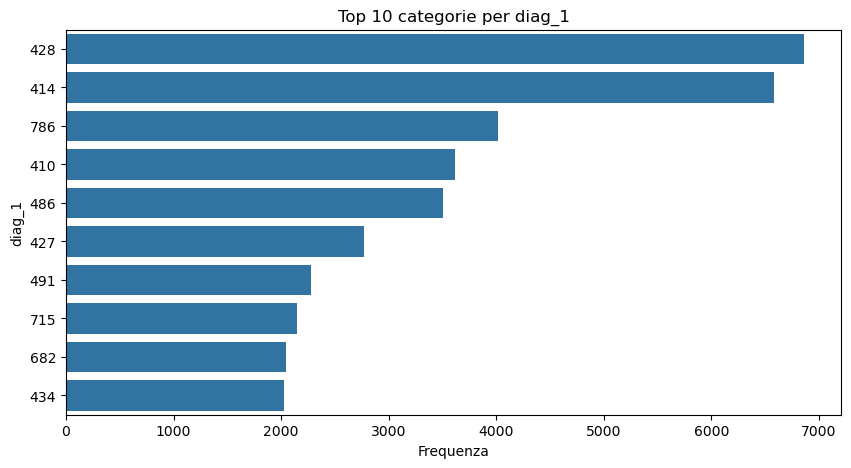

Commento: diag_1 ha 716 categorie uniche.
Nota: Il grafico mostra solo le 10 categorie più frequenti.
------------------------------------------------------------


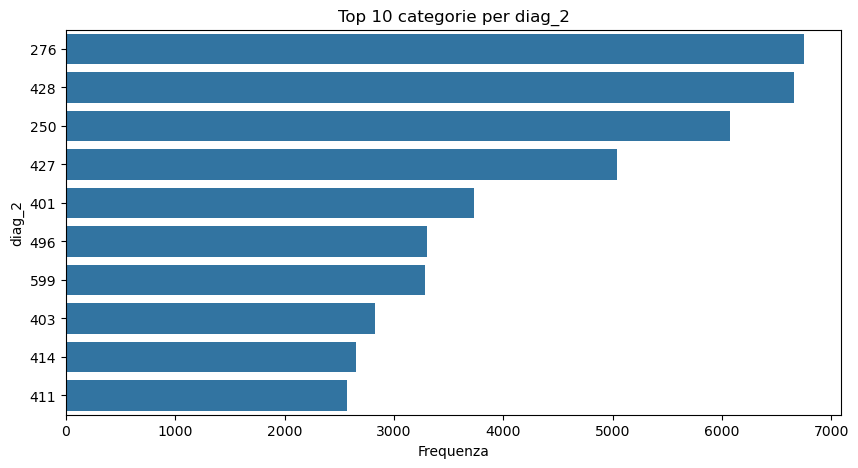

Commento: diag_2 ha 748 categorie uniche.
Nota: Il grafico mostra solo le 10 categorie più frequenti.
------------------------------------------------------------


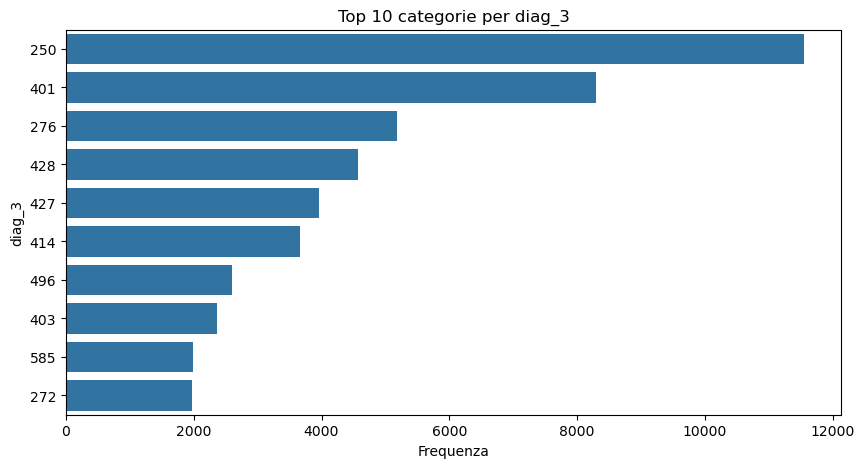

Commento: diag_3 ha 789 categorie uniche.
Nota: Il grafico mostra solo le 10 categorie più frequenti.
------------------------------------------------------------


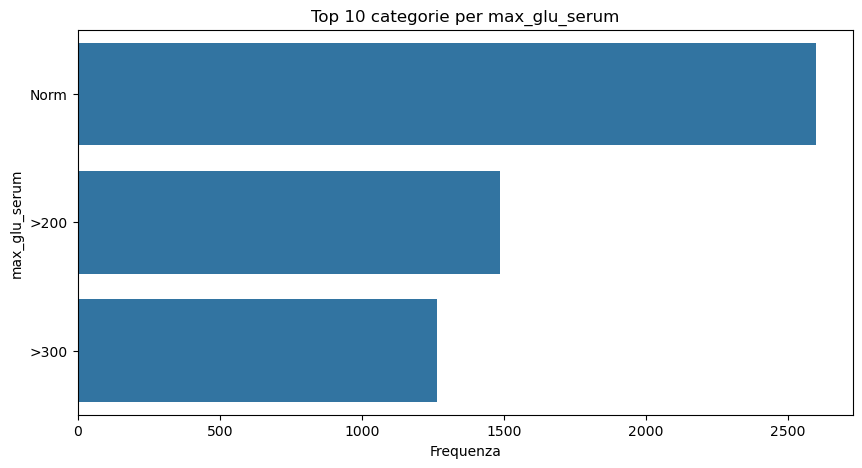

Commento: max_glu_serum ha 3 categorie uniche.
------------------------------------------------------------


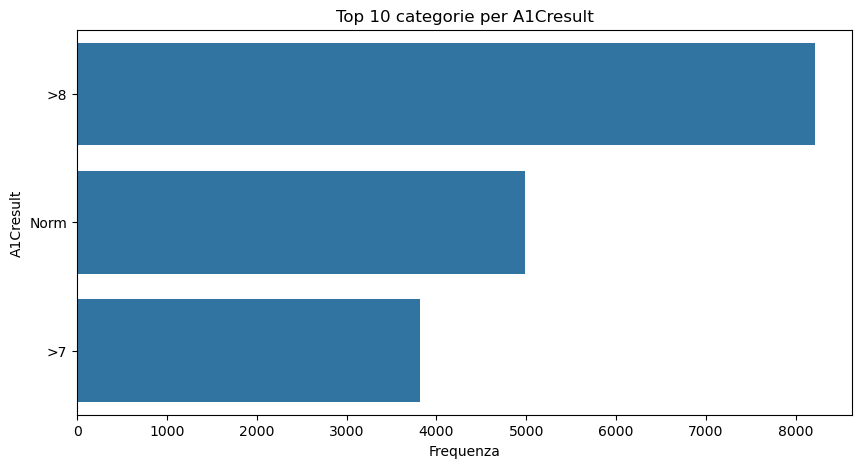

Commento: A1Cresult ha 3 categorie uniche.
------------------------------------------------------------


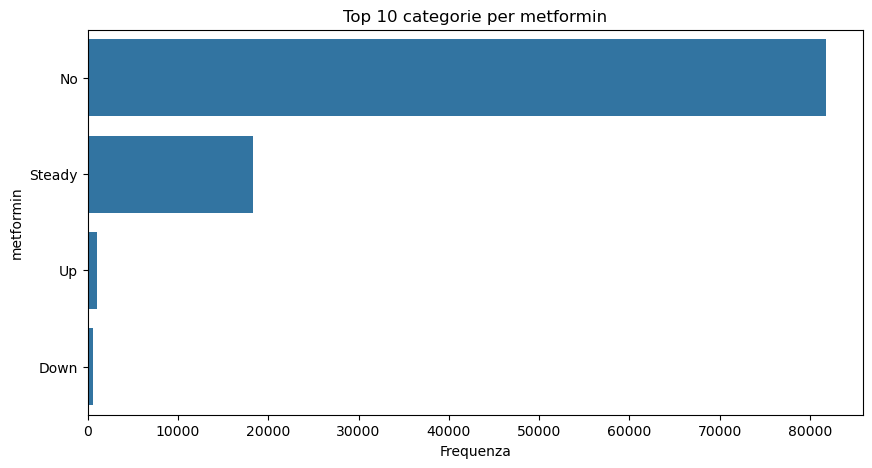

Commento: metformin ha 4 categorie uniche.
------------------------------------------------------------


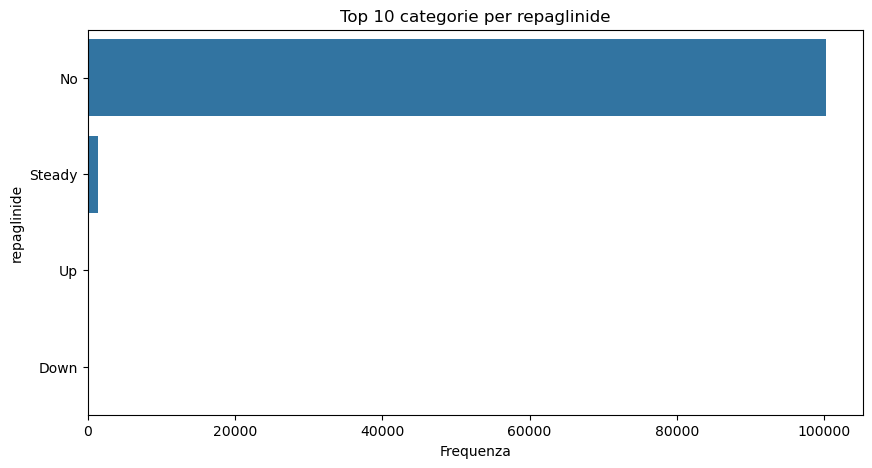

Commento: repaglinide ha 4 categorie uniche.
------------------------------------------------------------


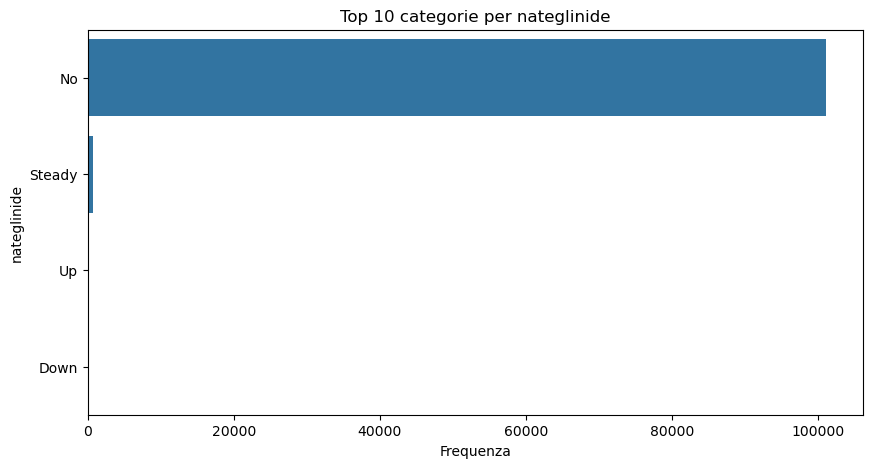

Commento: nateglinide ha 4 categorie uniche.
------------------------------------------------------------


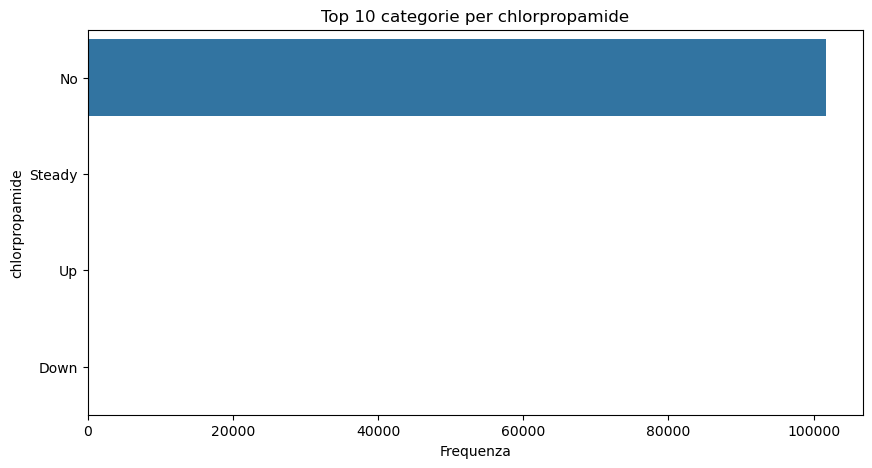

Commento: chlorpropamide ha 4 categorie uniche.
------------------------------------------------------------


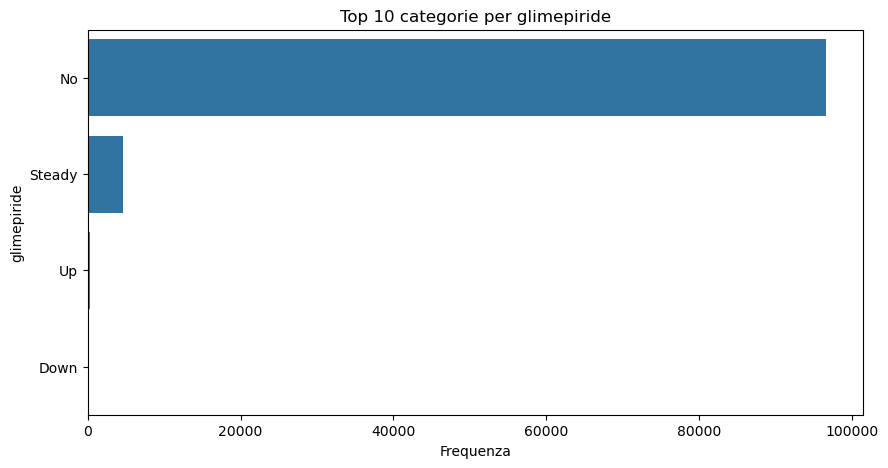

Commento: glimepiride ha 4 categorie uniche.
------------------------------------------------------------


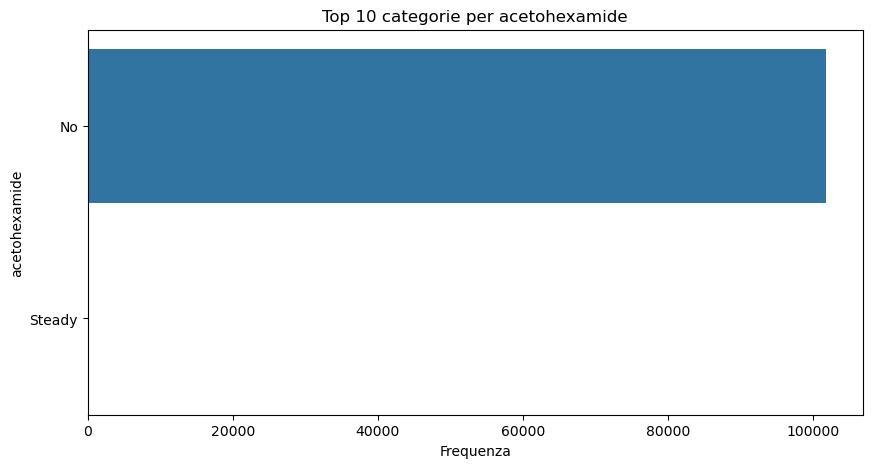

Commento: acetohexamide ha 2 categorie uniche.
------------------------------------------------------------


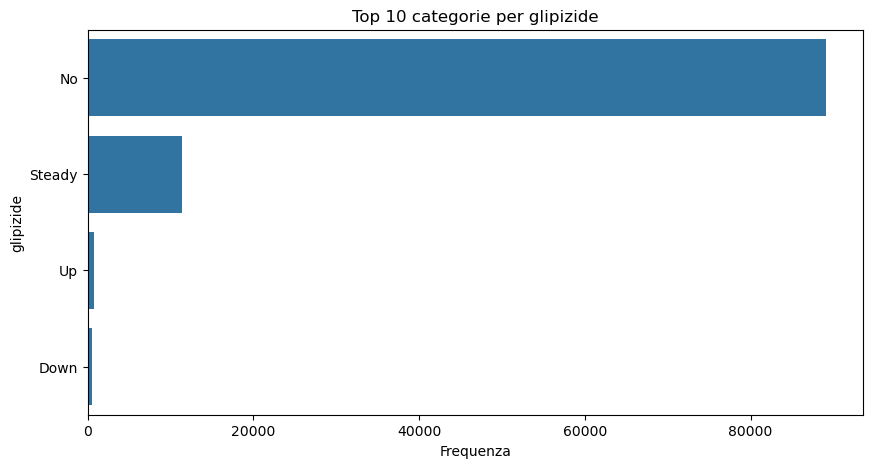

Commento: glipizide ha 4 categorie uniche.
------------------------------------------------------------


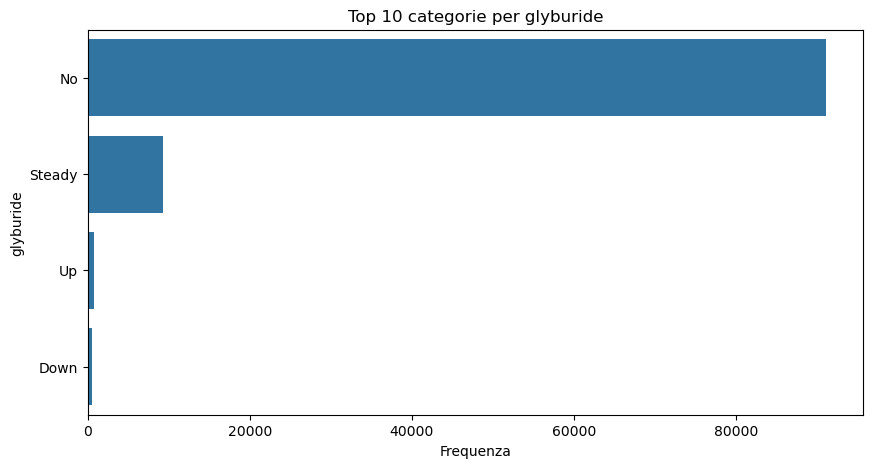

Commento: glyburide ha 4 categorie uniche.
------------------------------------------------------------


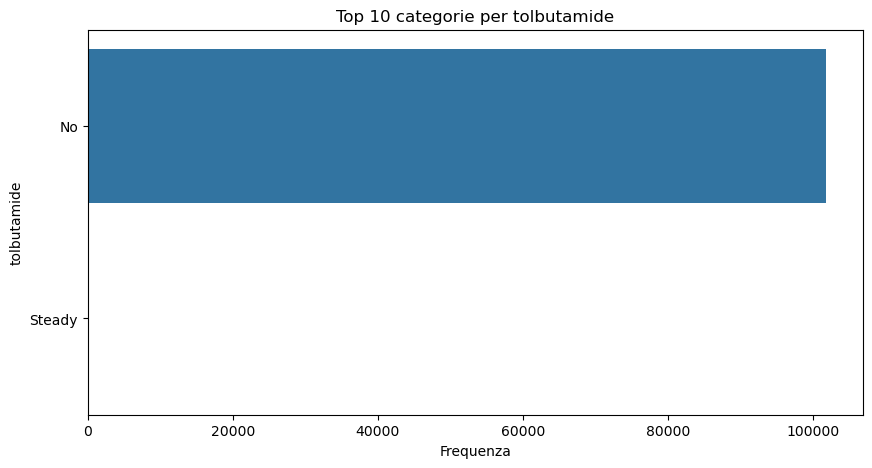

Commento: tolbutamide ha 2 categorie uniche.
------------------------------------------------------------


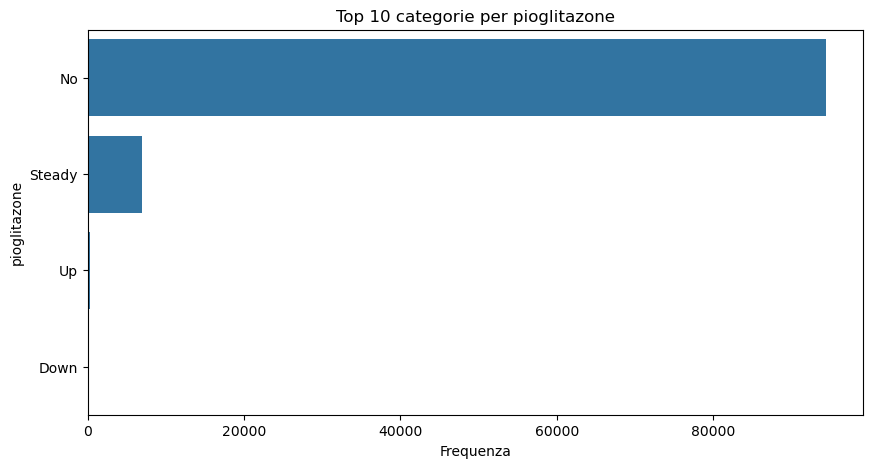

Commento: pioglitazone ha 4 categorie uniche.
------------------------------------------------------------


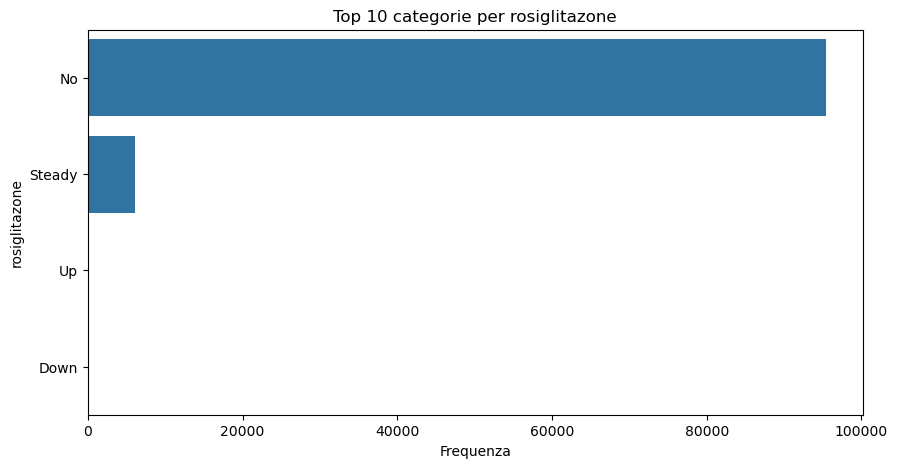

Commento: rosiglitazone ha 4 categorie uniche.
------------------------------------------------------------


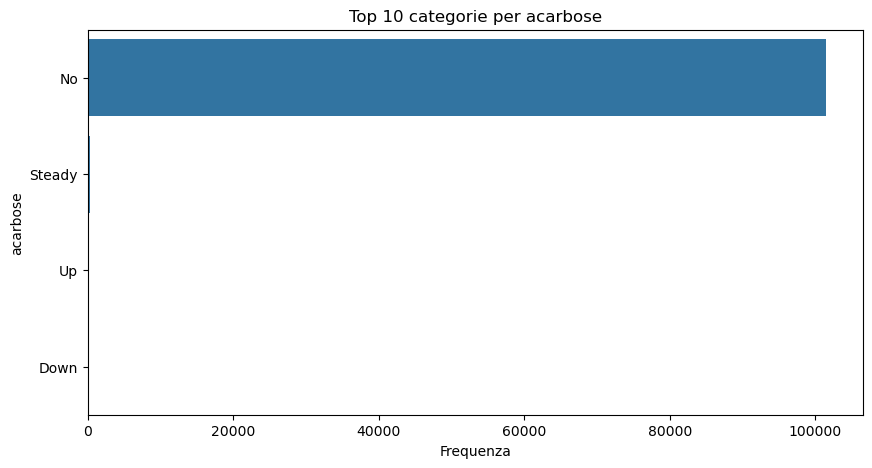

Commento: acarbose ha 4 categorie uniche.
------------------------------------------------------------


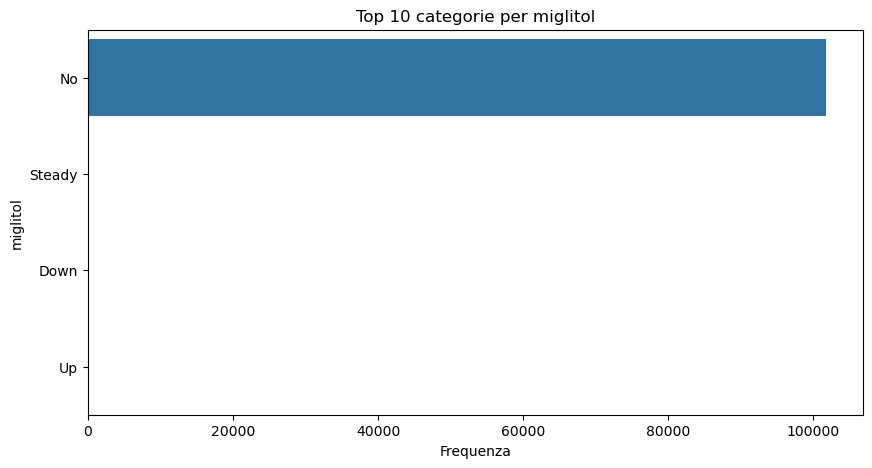

Commento: miglitol ha 4 categorie uniche.
------------------------------------------------------------


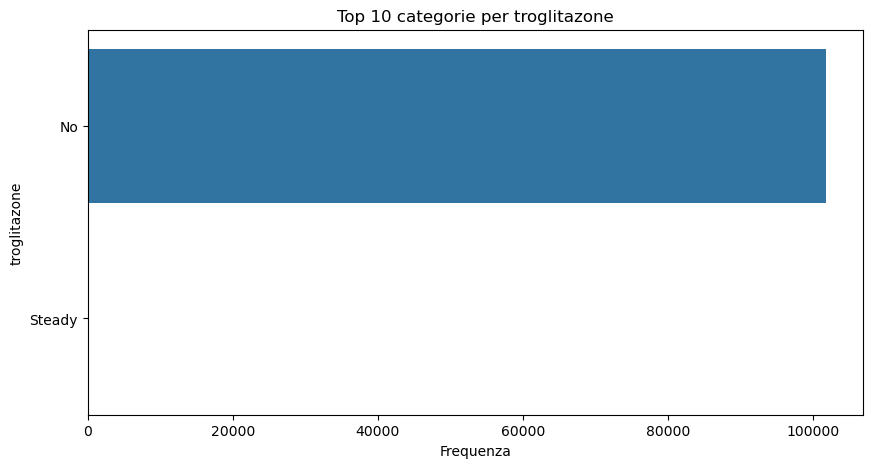

Commento: troglitazone ha 2 categorie uniche.
------------------------------------------------------------


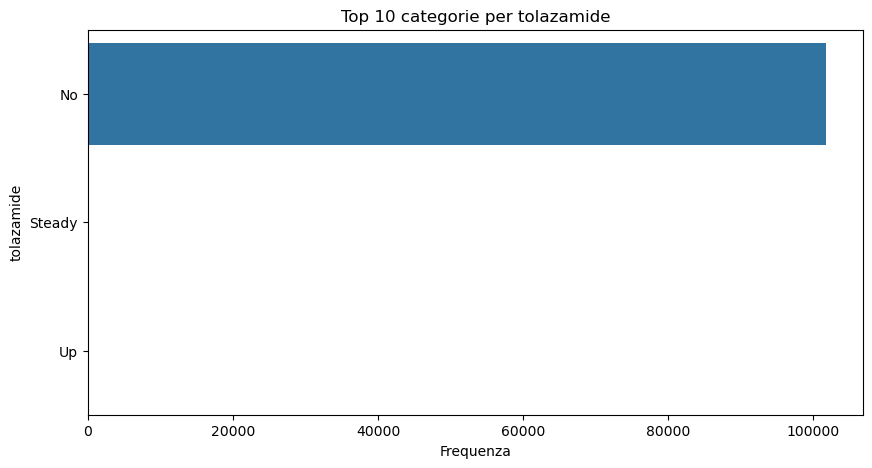

Commento: tolazamide ha 3 categorie uniche.
------------------------------------------------------------


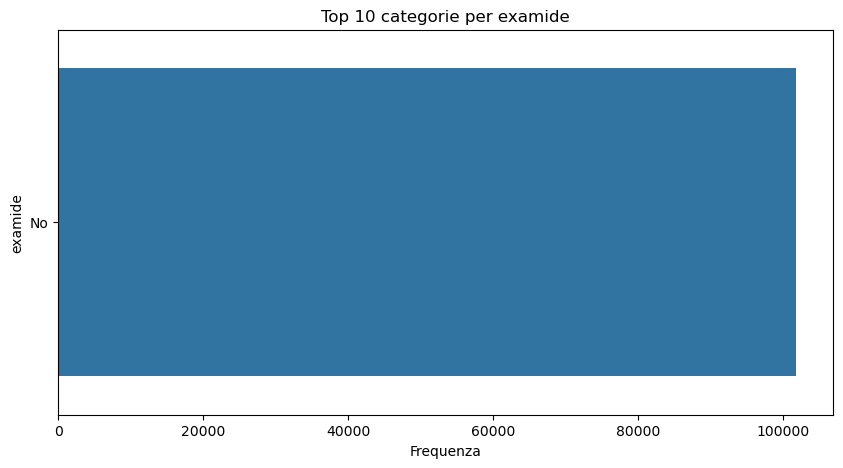

Commento: examide ha 1 categorie uniche.
------------------------------------------------------------


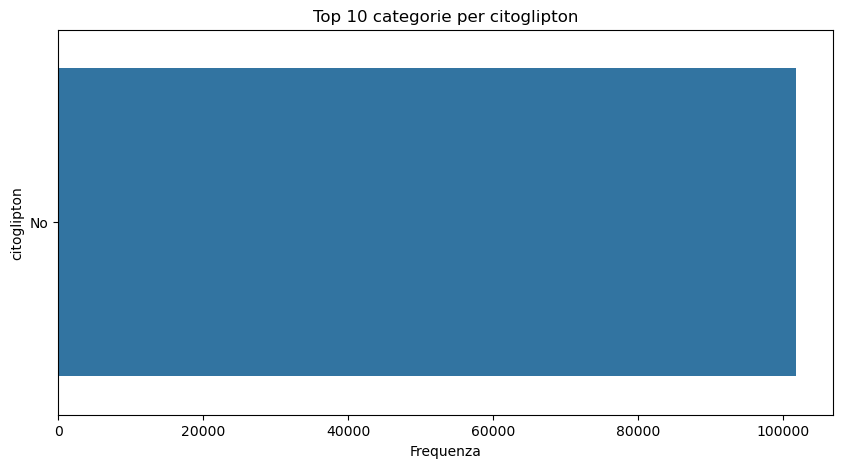

Commento: citoglipton ha 1 categorie uniche.
------------------------------------------------------------


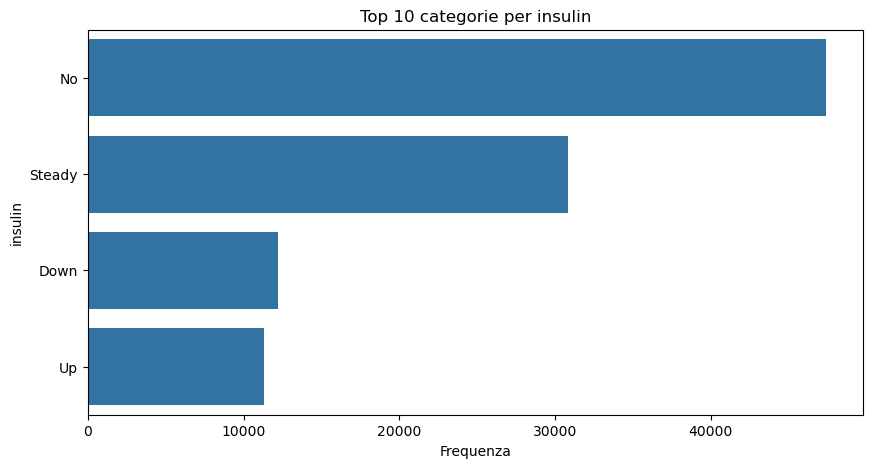

Commento: insulin ha 4 categorie uniche.
------------------------------------------------------------


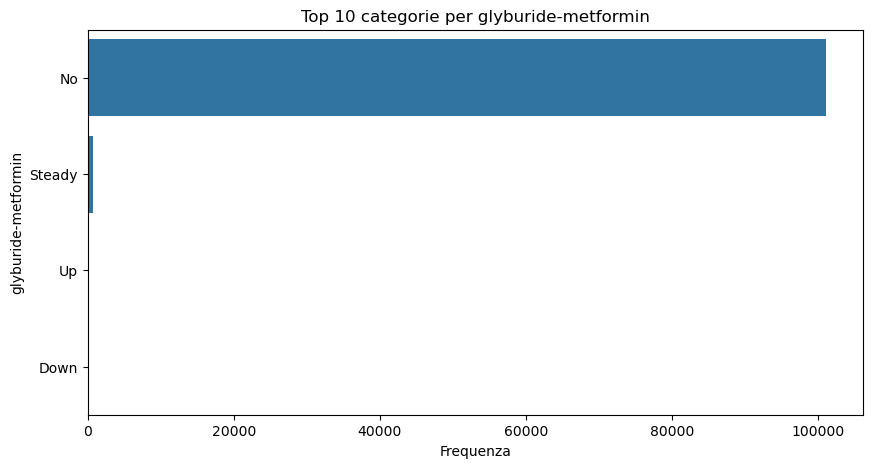

Commento: glyburide-metformin ha 4 categorie uniche.
------------------------------------------------------------


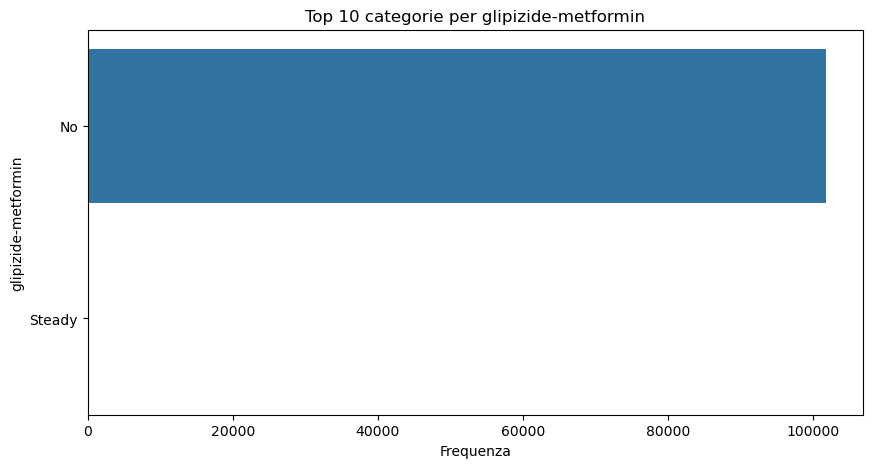

Commento: glipizide-metformin ha 2 categorie uniche.
------------------------------------------------------------


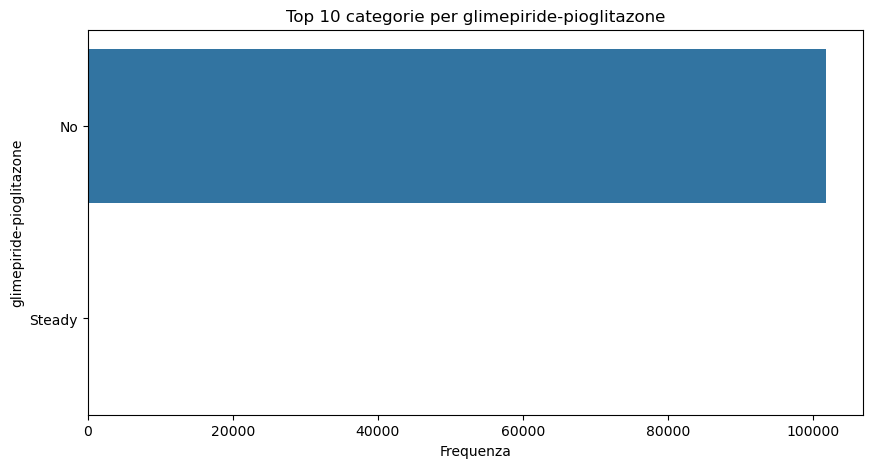

Commento: glimepiride-pioglitazone ha 2 categorie uniche.
------------------------------------------------------------


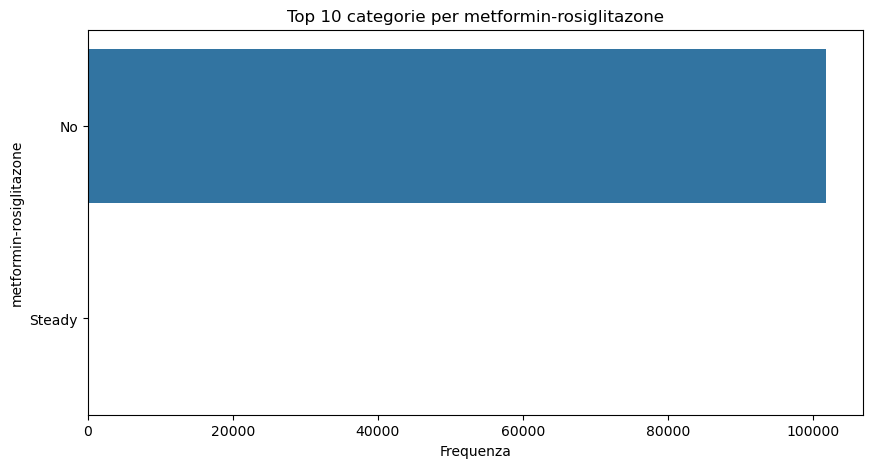

Commento: metformin-rosiglitazone ha 2 categorie uniche.
------------------------------------------------------------


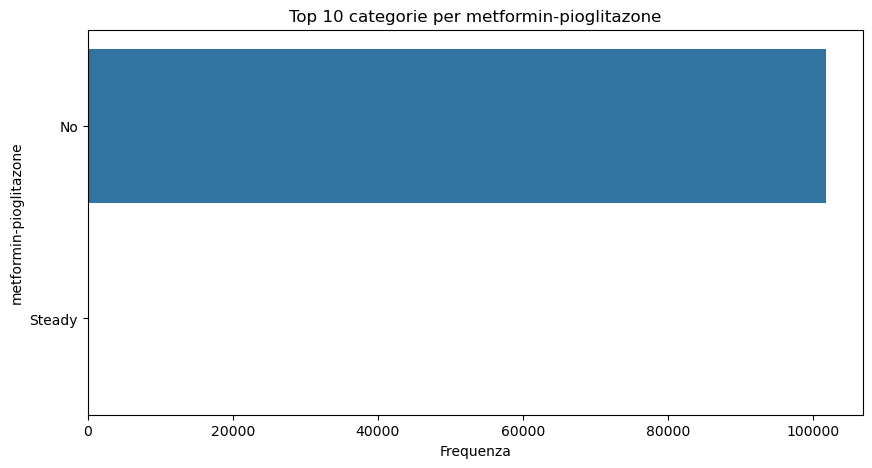

Commento: metformin-pioglitazone ha 2 categorie uniche.
------------------------------------------------------------


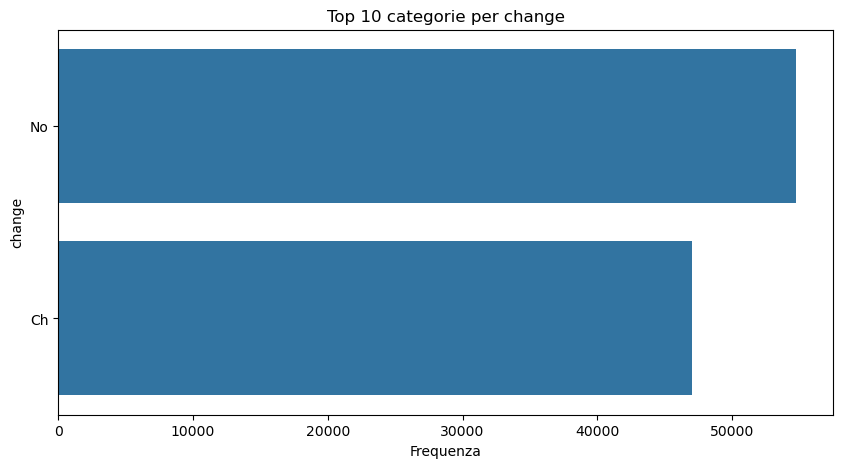

Commento: change ha 2 categorie uniche.
------------------------------------------------------------


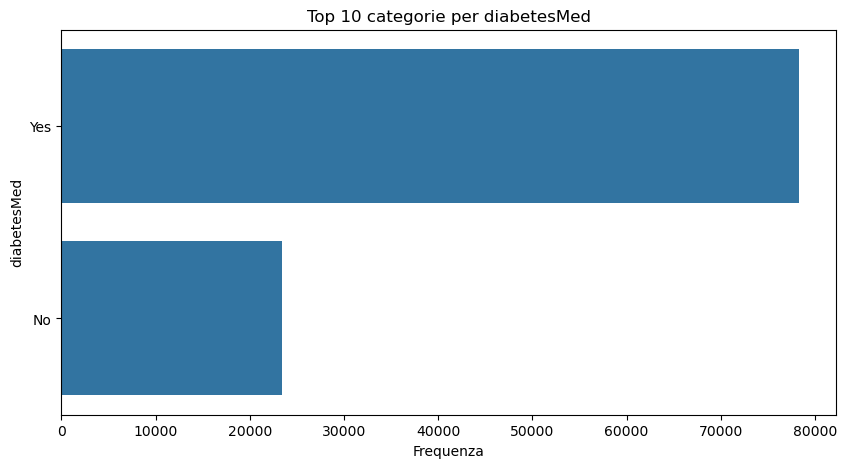

Commento: diabetesMed ha 2 categorie uniche.
------------------------------------------------------------


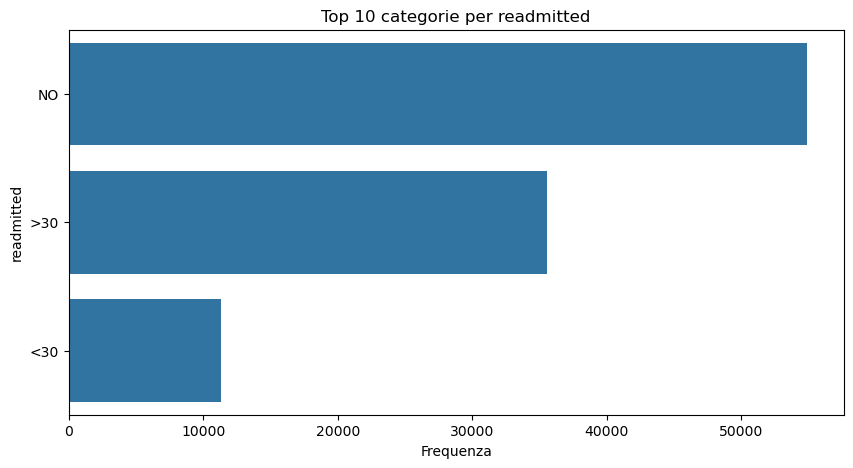

Commento: readmitted ha 3 categorie uniche.
------------------------------------------------------------


In [16]:
#Seleziono solo le feature numeriche
features_num = df_hospital_clean.select_dtypes(include=[np.number]).columns

# Escludiamo gli ID che non ha senso analizzare statisticamente
features_num = [f for f in features_num if f not in ['encounter_id', 'patient_nbr', 'readmitted_numeric']]

for col in features_num:
    #rimuoviamo i NaN solo per l'analisi di questa colonna
    data_column = df_hospital_clean[col].dropna()
    if data_column.empty: 
        continue
    print(f"\nAnalisi della feature: {col}")

    #Istogramma + Q-Q plot affiancati
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    #Istogramma
    sns.histplot(data_column, bins=20, kde=True, ax=ax1)
    ax1.set_title(f"Distribuzione di {col}")
    # Q-Q plot
    stats.probplot(data_column, dist="norm", plot=ax2)
    ax2.set_title(f"Q-Q plot di {col}")
    plt.show()
   
    #Test di normalità di Shapiro-Wilk
    stat, p = stats.shapiro(data_column.sample(min(5000, len(data_column)), random_state=42))
    skew = data_column.skew()
    if p > 0.05:
        res = f"{col} ha distribuzione vicina alla normale"
    else:
        res = f"{col} ha distribuzione asimmetrica o valori estremi"
    print(f"Test Shapiro-Wilk: {res} (p={p:.4f})")
    print(f"Skewness (Asimmetria): {skew:.2f} " + ("(Coda a destra)" if skew > 0 else "(Coda a sinistra)"))
    print("-" * 60)

categorical_features = df_hospital_clean.select_dtypes(include=['object']).columns

for col in categorical_features:
    plt.figure(figsize=(10, 5))
    
    # Prendiamo solo le prime 10 categorie più frequenti per evitare grafici illeggibili
    top_10 = df_hospital_clean[col].value_counts().nlargest(10).index
    sns.countplot(y=col, data=df_hospital_clean[df_hospital_clean[col].isin(top_10)], order=top_10)
    
    plt.title(f"Top 10 categorie per {col}")
    plt.xlabel("Frequenza")
    plt.ylabel(col)
    plt.show()
    
    unique_vals = df_hospital_clean[col].nunique()
    print(f"Commento: {col} ha {unique_vals} categorie uniche.")
    if unique_vals > 10:
        print(f"Nota: Il grafico mostra solo le 10 categorie più frequenti.")
    print("-" * 60)

In [17]:
#L'analisi visiva e statistica effettuata sulle variabili numeriche e categoriche ha permesso di delineare il profilo del dataset e 
#di identificare le necessarie strategie di preprocessing.

#1)VARIABILI NUMERICHE
#L'integrazione di Istogrammi, Q-Q Plot e test di Shapiro-Wilk evidenzia quanto segue:
#-Tutte le feature numeriche mostrano un p-value < 0.05, confermando che le distribuzioni non sono normali.
#I Q-Q Plot mostrano deviazioni significative dalle rette teoriche, specialmente nelle code.
#- Si osserva una forte asimmetria positiva. Variabili come number_emergency (22.86) e number_outpatient (8.83) presentano
#valori estremi che indicano una piccola fetta di pazienti con altissima frequenza di accesso, mentre la maggioranza si attesta sullo zero.
#-La variabile number_diagnoses ha un picco marcato sul valore 9, suggerendo una standardizzazione clinica nei pazienti cronici complessi.

#2)VARIABILI CATEGORICHE
#I grafici a barre sulle frequenze delle categorie rivelano la struttura della popolazione e dei trattamenti:
#-Il dataset è sbilanciato verso la popolazione Caucasica e le fasce d'età senior (60-90 anni). Il genere appare invece equamente distribuito,
#riducendo il rischio di bias di genere nelle previsioni.
#-L'analisi sui farmaci per il diabete (da metformin e insulin fino a quelli meno comuni come acarbose, miglitol o troglitazone) mostra che
#la categoria "No" è dominante per la maggior parte dei principi attivi orali.
#Quando il farmaco è somministrato, la categoria "Steady" è la più frequente, indicando una bassa propensione alla modifica del dosaggio durante il singolo ricovero.
#L'Insulina si conferma come il trattamento più dinamico e diffuso, con una distribuzione più variegata tra le classi di dosaggio.
#-Le diagnosi (diag_1, diag_2, diag_3) presentano centinaia di valori univoci. La visualizzazione delle "Top 10" evidenzia una prevalenza di patologie circolatorie e metaboliche.


Distribuzione delle featureas rispetto alla riammissione


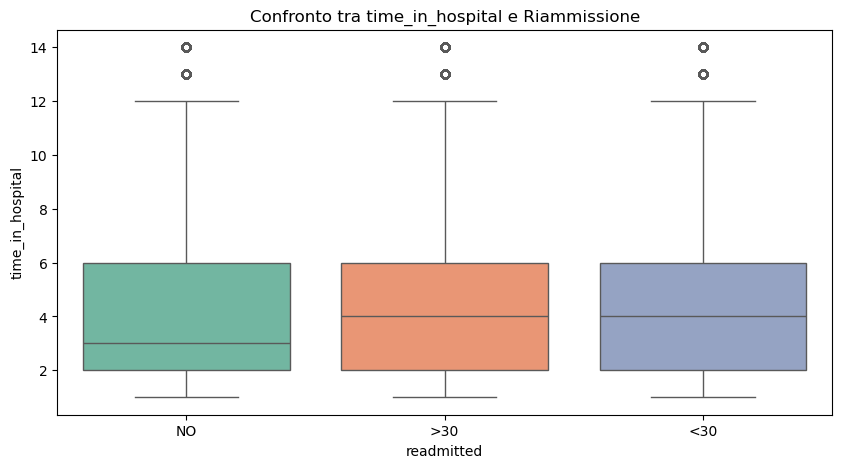

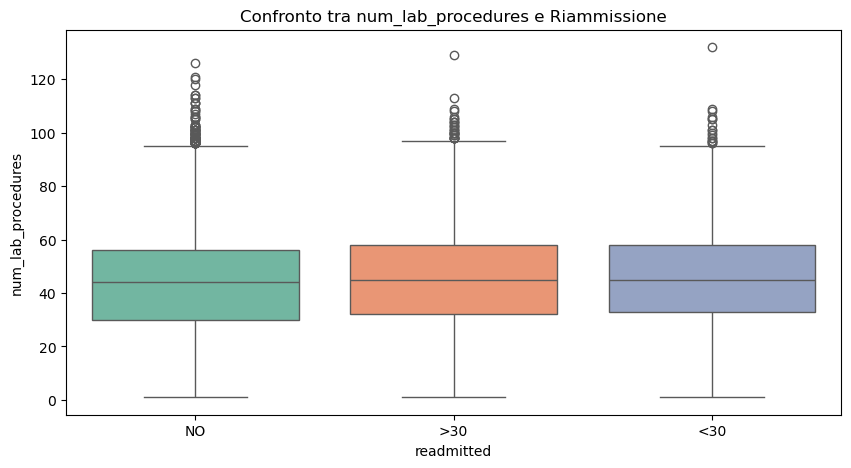

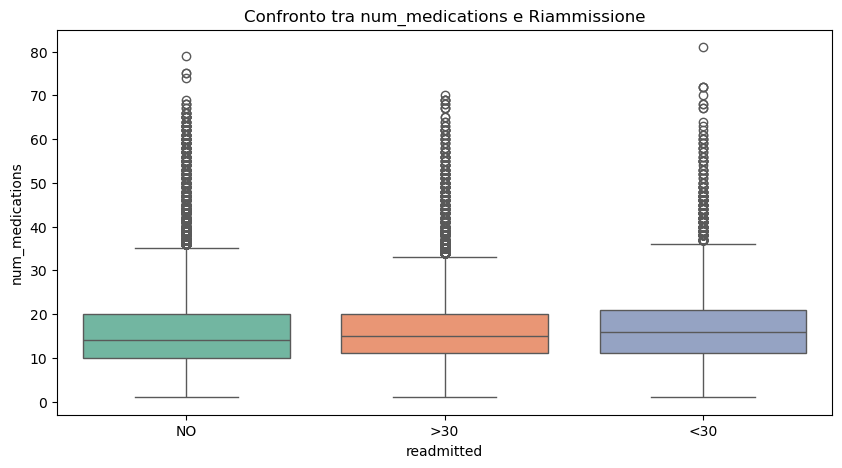

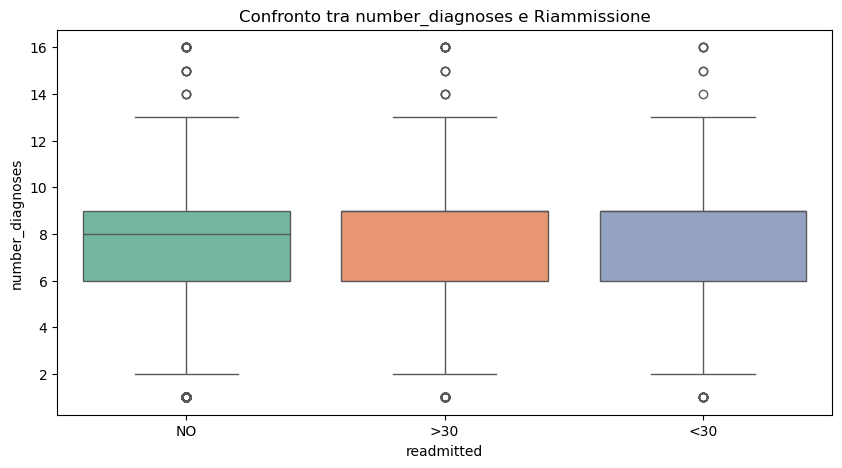

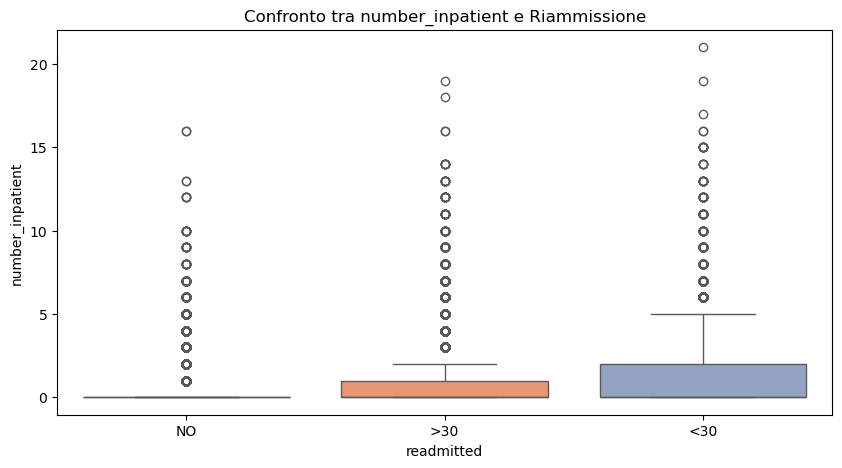

Medie delle variabili numeriche rispetto alla riammissione:


,time_in_hospital,num_lab_procedures,num_medications,number_diagnoses,number_inpatient
readmitted,,,,,
NO,4.254429,42.381598,15.670367,7.221366,0.381963
>30,4.495541,43.836601,16.282768,7.646898,0.838993
<30,4.768249,44.226028,16.903143,7.692789,1.224003


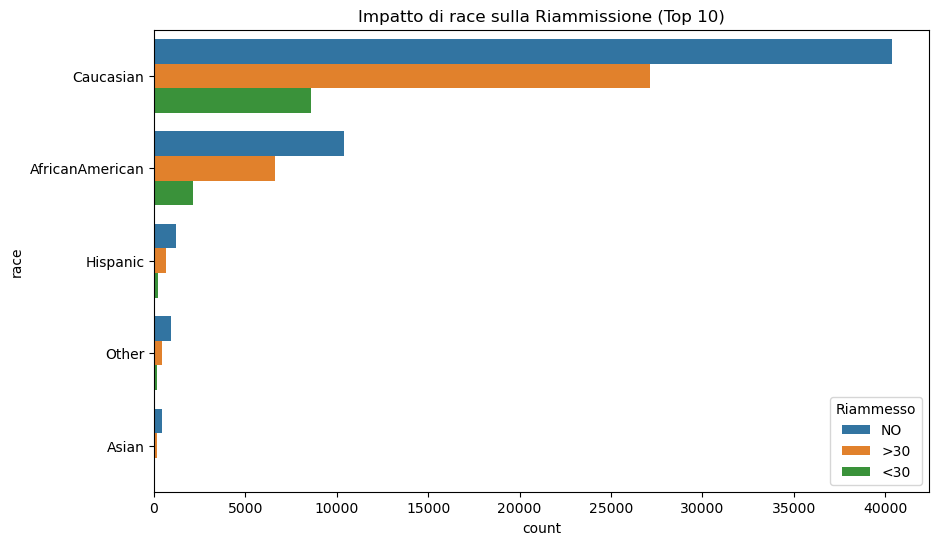

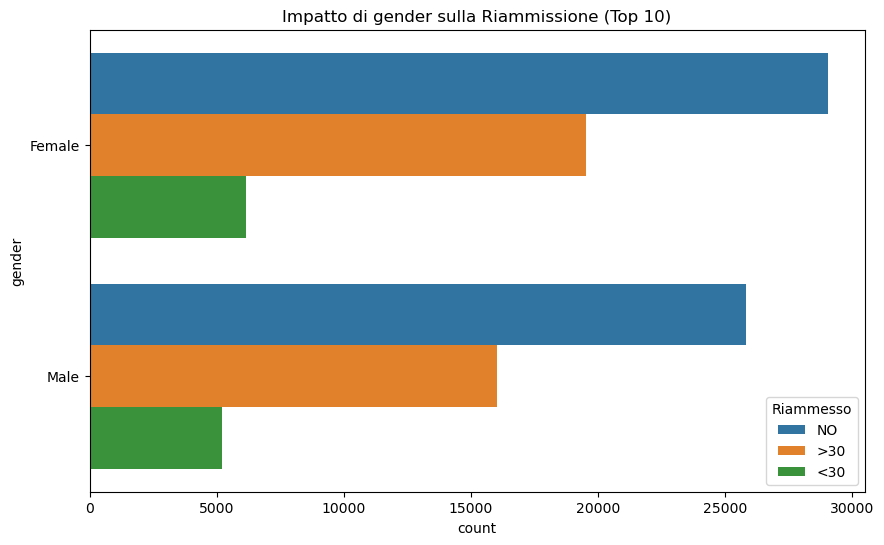

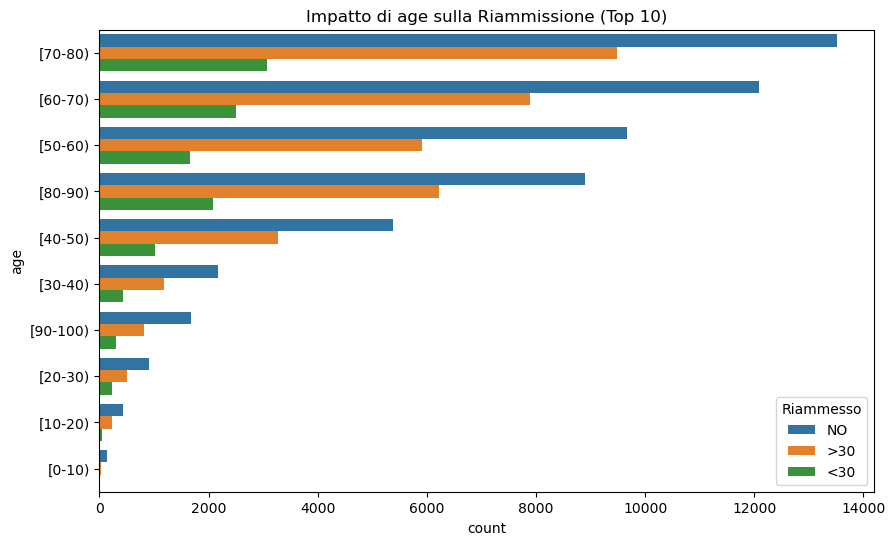

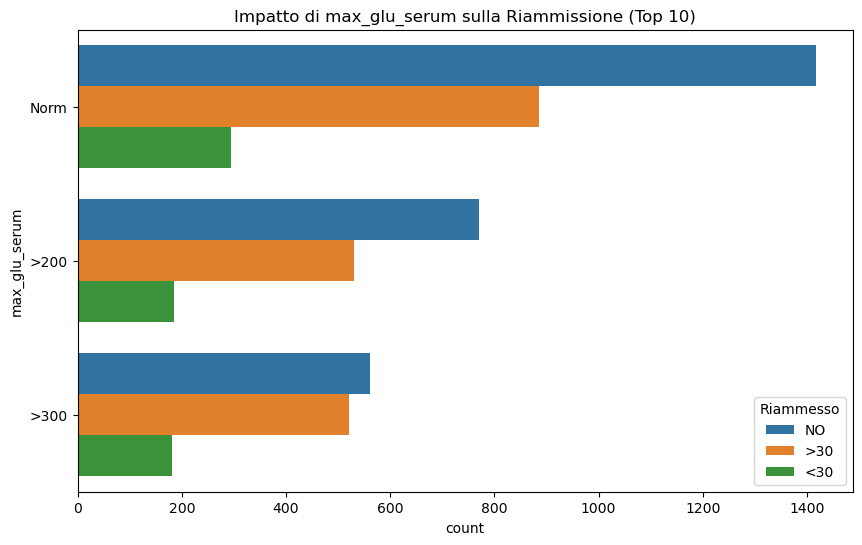

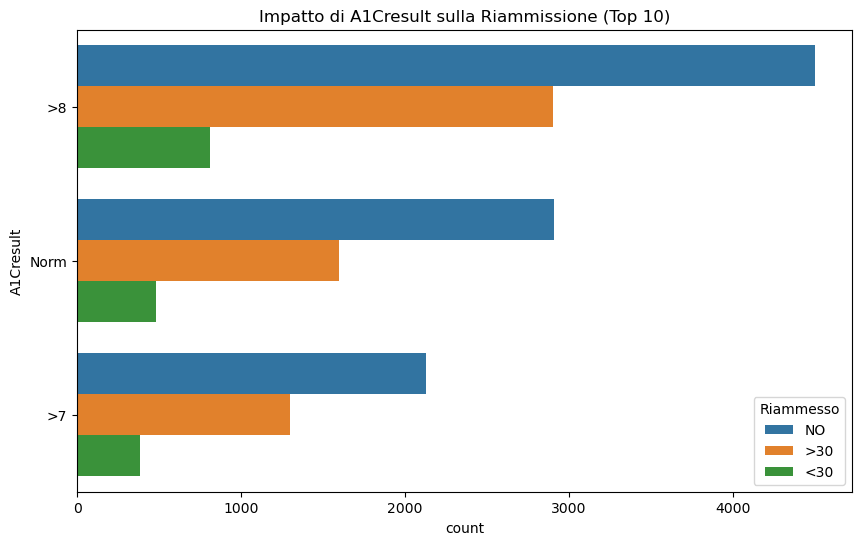

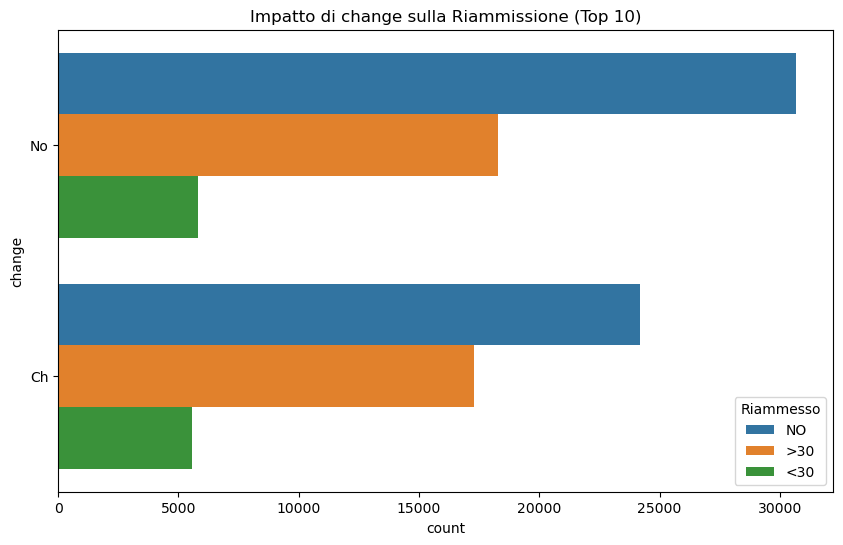

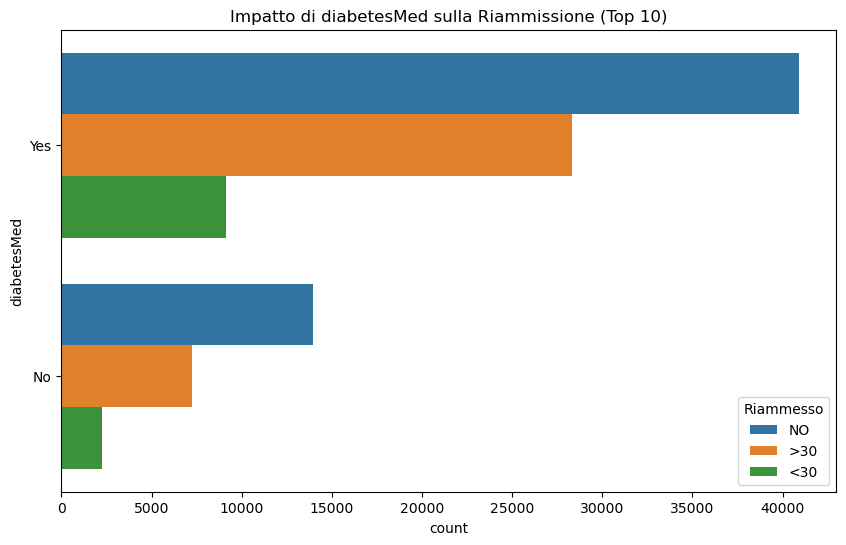

In [18]:
#Distribuzioni delle features rispetto alla riammissione
print("\nDistribuzione delle featureas rispetto alla riammissione")
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_diagnoses', 'number_inpatient']
order = ['NO','>30','<30']
#Feature numeriche: utilizziamo i boxplot, più chiari per il confronto
for col in numeric_cols:
    plt.figure(figsize=(10, 5))
    # Il Boxplot mostra subito se chi viene riammesso sta più tempo in ospedale
    sns.boxplot(data=df_hospital_clean, x='readmitted', y=col, hue='readmitted', order=order, palette="Set2", legend=False)
    plt.title(f"Confronto tra {col} e Riammissione")
    plt.show()

# Calcolo delle medie delle variabili numeriche per ogni categoria di riammissione
analisi_medie = df_hospital_clean.groupby('readmitted')[numeric_cols].mean().reindex(order)
print("Medie delle variabili numeriche rispetto alla riammissione:")
display(analisi_medie)
# Calcolo della variazione percentuale rispetto a chi NON viene riammesso
diff_percentuale = analisi_medie.pct_change() #per vedere il salto tra NO e <30

# 2. Feature Categoriche: Countplot filtrato e orizzontale
# Selezioniamo solo alcune categoriche chiave per non intasare il notebook
cat_cols_key = ['race', 'gender', 'age', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed']

for col in cat_cols_key:
    plt.figure(figsize=(10, 6))
    # Prendiamo le categorie più significative
    top_cats = df_hospital_clean[col].value_counts().nlargest(10).index
    df_filtered = df_hospital_clean[df_hospital_clean[col].isin(top_cats)]
    # Grafico a barre orizzontali: più facile da leggere
    sns.countplot(data=df_filtered, y=col, hue="readmitted", order=top_cats)
    
    plt.title(f"Impatto di {col} sulla Riammissione (Top 10)")
    plt.legend(title='Riammesso', loc='lower right')
    plt.show()

In [19]:
#Per comprendere la relazione tra le features e la probabilità di riammissione ospedaliera,
#è stata condotta un'analisi della distribuzione delle diverse variabili del dataset considerando la variabile target readmitted,
#che distingue tra pazienti non riammessi, riammessi dopo 30 giorni e riammessi entro 30 giorni.
#1) FEATURE NUMERICHE
#L'utilizzo dei Boxplot, supportato dal calcolo delle medie per gruppo, ha permesso di confrontare la tendenza centrale e la dispersione dei dati tra i tre gruppi di pazienti:
#-Variabili come time_in_hospital(che passa da una media di 4.33 per i non riammessi a 4.73 per i riammessi entro 30gg) e num_medications(da 15.99 a 17.71) 
#mostrano distribuzioni visivamente sovrapposte, ma medie che crescono linearmente con la criticità della riammissione. 
#Questo suggerisce che degenze più lunghe e terapie farmacologiche più ricche sono correlate a una maggiore fragilità del paziente.
#-Si osserva un balzo netto in number_inpatient, la cui media quasi triplica passando da 0.30 (NO) a 0.82 (<30).
#Questo dato numerico conferma che la storia di ricoveri precedenti è il predittore più solido della riammissione immediata.
#-Anche il numero di diagnosi mostra uno scarto significativo, con i pazienti riammessi entro 30 giorni che presentano la media più alta (7.71 contro 7.22 dei non riammessi),
#confermando che la multi-patologia aggrava il rischio di ritorno in struttura

#2) FEATURE CATEGORICHE
#L'impatto delle variabili categoriche è stato analizzato tramite grafici a barre orizzontali per valutarne la frequenza relativa:
#-Variabili come age, race e gender mostrano una distribuzione proporzionale delle classi di riammissione quasi identica tra le diverse categorie.
#Ad esempio, la prevalenza di riammissioni nel gruppo "Caucasian" o nelle fasce "70-80 anni" è elevata, ma riflette semplicemente la composizione demografica 
#del dataset, senza indicare un rischio specifico isolato per una singola categoria.
#-La presenza di farmaci per il diabete (diabetesMed) o il cambiamento della terapia (change) mostrano volumi di riammissione maggiori semplicemente perché
#rappresentano le categorie più popolose del dataset, ma il rapporto tra "riammissi" e "non riammessi" rimane costante.


#In questa fase è stata operata una scelta: limitare l'analisi a un sottoinsieme di variabili chiave, escludendo la totalità del dataset per i seguenti motivi:
#1)Esclusione di Variabili Non Informative: Identificatori univoci (come encounter_id o patient_nbr) sono stati rimossi in quanto parametri amministrativi privi di valore clinico o statistico.
#2)Prevenzione del Rumore: Analizzare variabili con varianza quasi nulla o con categorie eccessivamente numerose (alta cardinalità) avrebbe generato grafici illeggibili senza aggiungere potere predittivo reale.
#3)Focus Interpretativo: La selezione si è concentrata sulle variabili che, per letteratura medica o evidenza statistica, mostrano una potenziale correlazione con il fenomeno della riammissione,
#garantendo così una maggiore chiarezza espositiva.

In [20]:
df_hospital_clean['medications_per_day'] = df_hospital_clean['num_medications'] / (df_hospital_clean['time_in_hospital'] + 1)

df_hospital_clean['procedures_total'] = (
    df_hospital_clean['num_procedures'] + df_hospital_clean['num_lab_procedures']
)

df_hospital_clean['total_visits'] = (
    df_hospital_clean['number_outpatient'] +
    df_hospital_clean['number_emergency'] +
    df_hospital_clean['number_inpatient']
)

df_hospital_clean['is_frequent_patient'] = (
    df_hospital_clean['number_inpatient'] > 2
).astype(int)

In [21]:
# 1. medications_per_day: Rappresenta l'intensità della cura farmacologica in rapporto al tempo di degenza. 
#    Un alto numero di farmaci in pochi giorni può indicare una criticità acuta o una gestione complessa del paziente.
# 2. procedures_total: Somma le procedure di laboratorio e quelle cliniche per ottenere una metrica unica 
#    dell'impegno diagnostico/terapeutico complessivo durante l'ospedalizzazione.
# 3. total_visits: Combina accessi ambulatoriali, di emergenza e ricoveri precedenti. È un forte indicatore 
#    della "frequenza" del paziente nel sistema sanitario (utilization rate), spesso correlato alla fragilità cronica.
# 4. is_frequent_patient: Variabile binaria che isola i "frequent flyers" (pazienti con più di 2 ricoveri precedenti). 
#    In letteratura, questa categoria ha un rischio significativamente più alto di riammissione a breve termine.

In [53]:
# Per questo esperimento, l'obiettivo è la predizione del rischio di riammissione al momento della dimissione del paziente.
# Di conseguenza, l'utilizzo della feature discharge_disposition_id è considerato ammissibile, poiché tale informazione è 
# nota nel momento in cui il modello deve fornire il suo output.
# Se l'obiettivo del modello venisse spostato alla predizione del rischio al momento dell'ingresso (accettazione), la feature 
# discharge_disposition_id (così come altre variabili legate al decorso ospedaliero, es. time_in_hospital o risultati di esami 
# eseguiti durante il ricovero) andrebbe tassativamente esclusa. Inserirla in quel contesto causerebbe il fenomeno di temporal 
# leakage, ovvero l'utilizzo di informazioni provenienti dal futuro rispetto al momento della predizione, portando a una 
# valutazione del modello eccessivamente ottimistica e non applicabile nella realtà clinica.

In [22]:
df_ml = df_hospital_clean.copy()
# 1. PREPARAZIONE DATI

df_ml['readmitted'] = df_ml['readmitted'].astype(str).str.strip()
print("Classi uniche trovate:", df_ml['readmitted'].unique())

numeric_cols_1 = [
    'time_in_hospital',
    #'num_lab_procedures',
    'num_medications',
    'number_diagnoses',
    #'number_inpatient',
    'medications_per_day',
    'procedures_total',
    'total_visits',
    'is_frequent_patient'
]

cat_cols_key = ['race', 'gender', 'age', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed']

X = df_ml[numeric_cols_1 + cat_cols_key]
y = df_ml['readmitted']

# Split Training e Test (stratificato)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# 2. DEFINIZIONE PREPROCESSOR
# Trasformatore numerico: Imputazione (se ci sono zeri spuri) + Scaling
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Trasformatore categorico: OneHotEncoding
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_cols_1),
    ('cat', cat_transformer, cat_cols_key)
])

Classi uniche trovate: ['NO' '>30' '<30']


Inizio addestramento: Logistic Regression...
La classe <30 si trova all'indice: 0


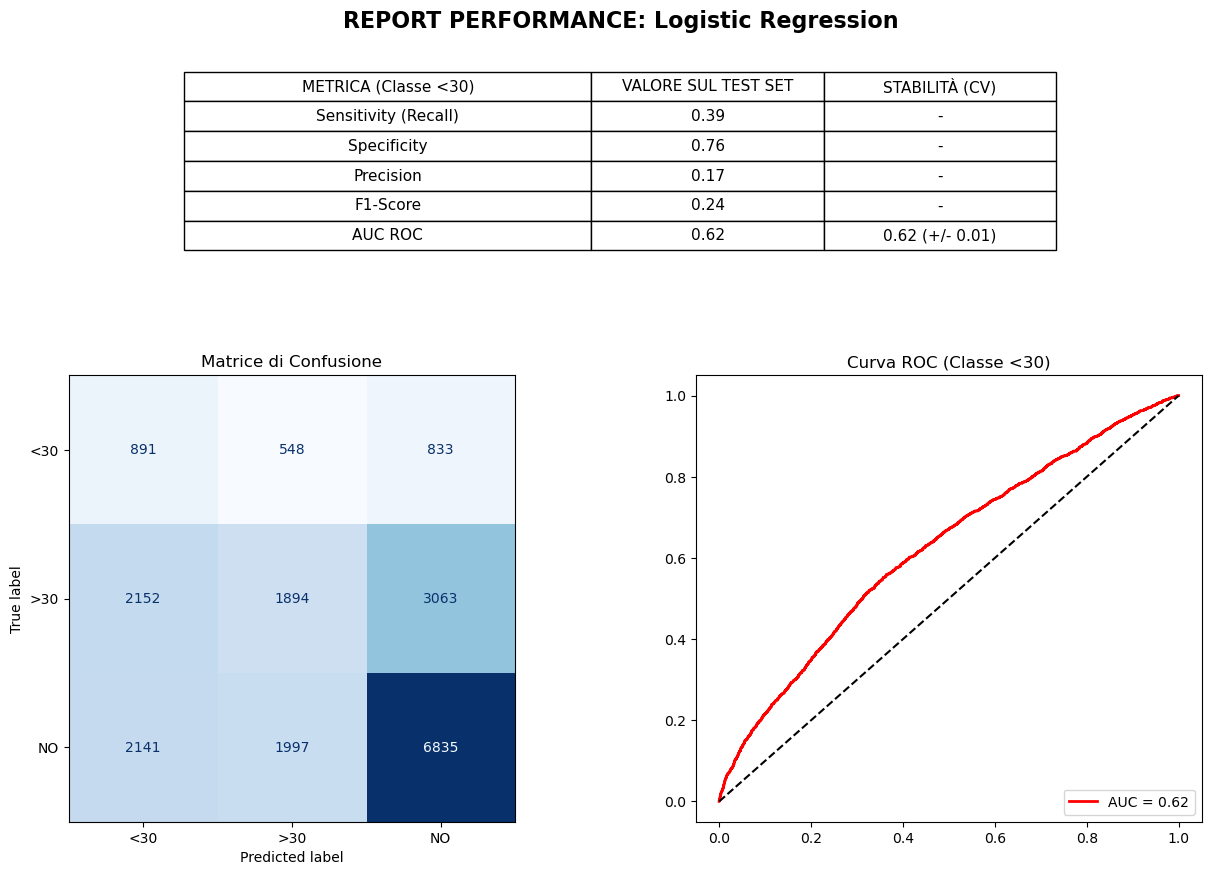

Inizio addestramento: Decision Tree...
La classe <30 si trova all'indice: 0


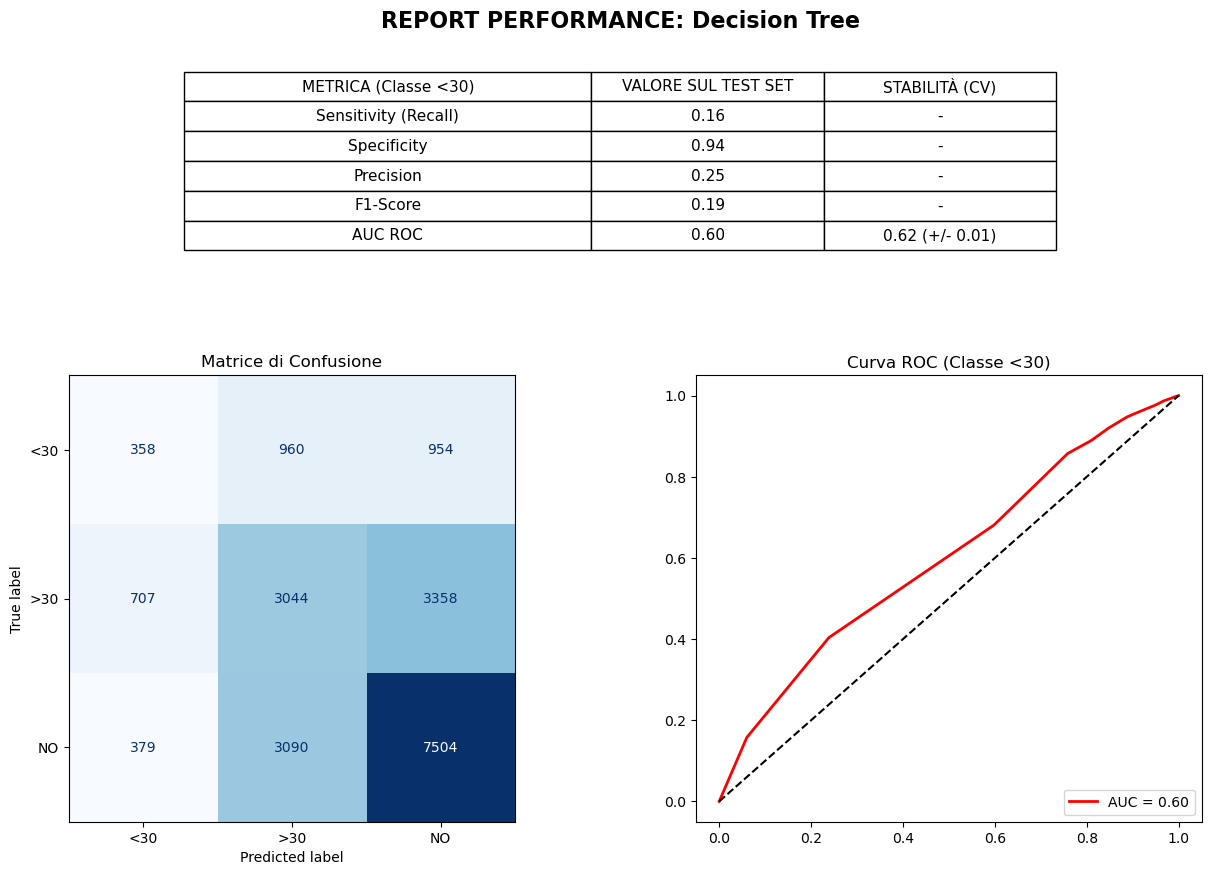

Inizio addestramento: Random Forest...
La classe <30 si trova all'indice: 0


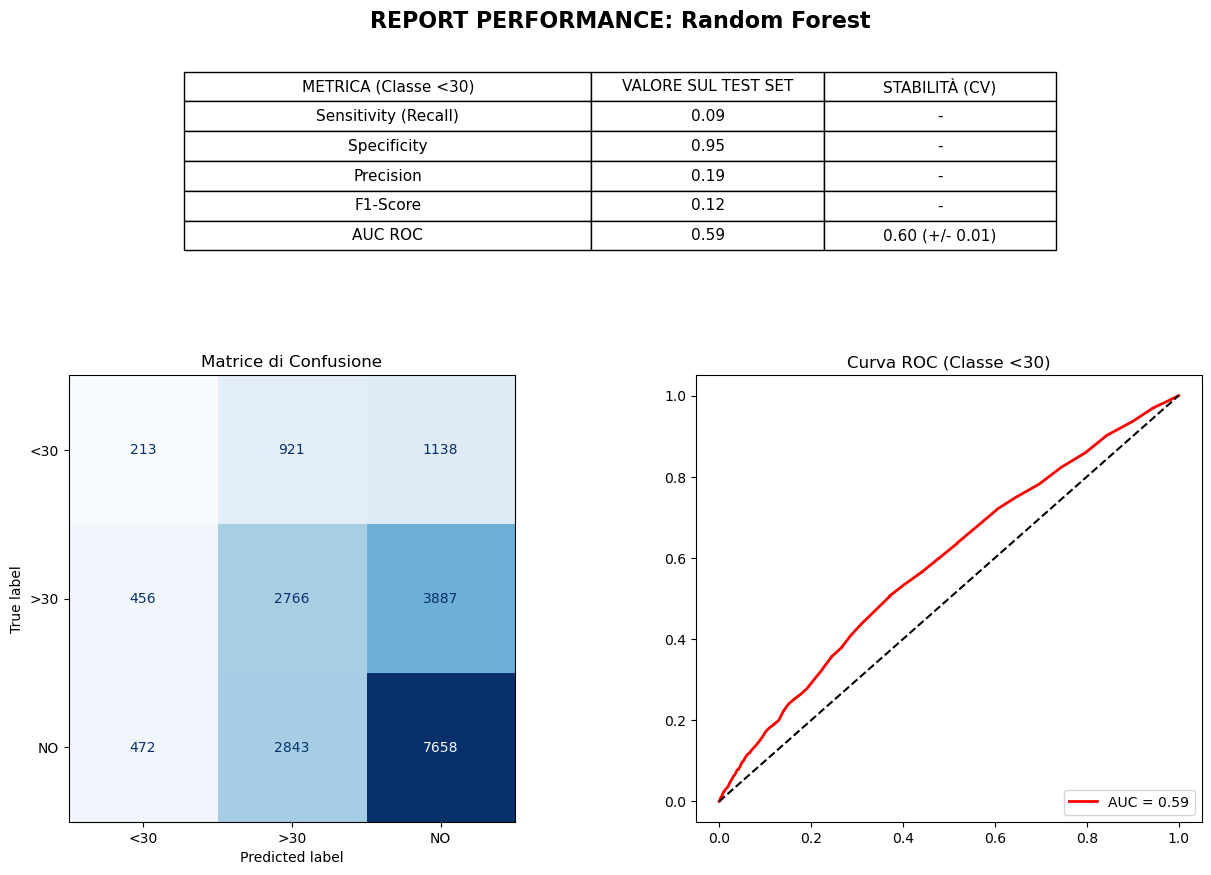

Inizio addestramento: Gradient Boosting (Fast)...
La classe <30 si trova all'indice: 0


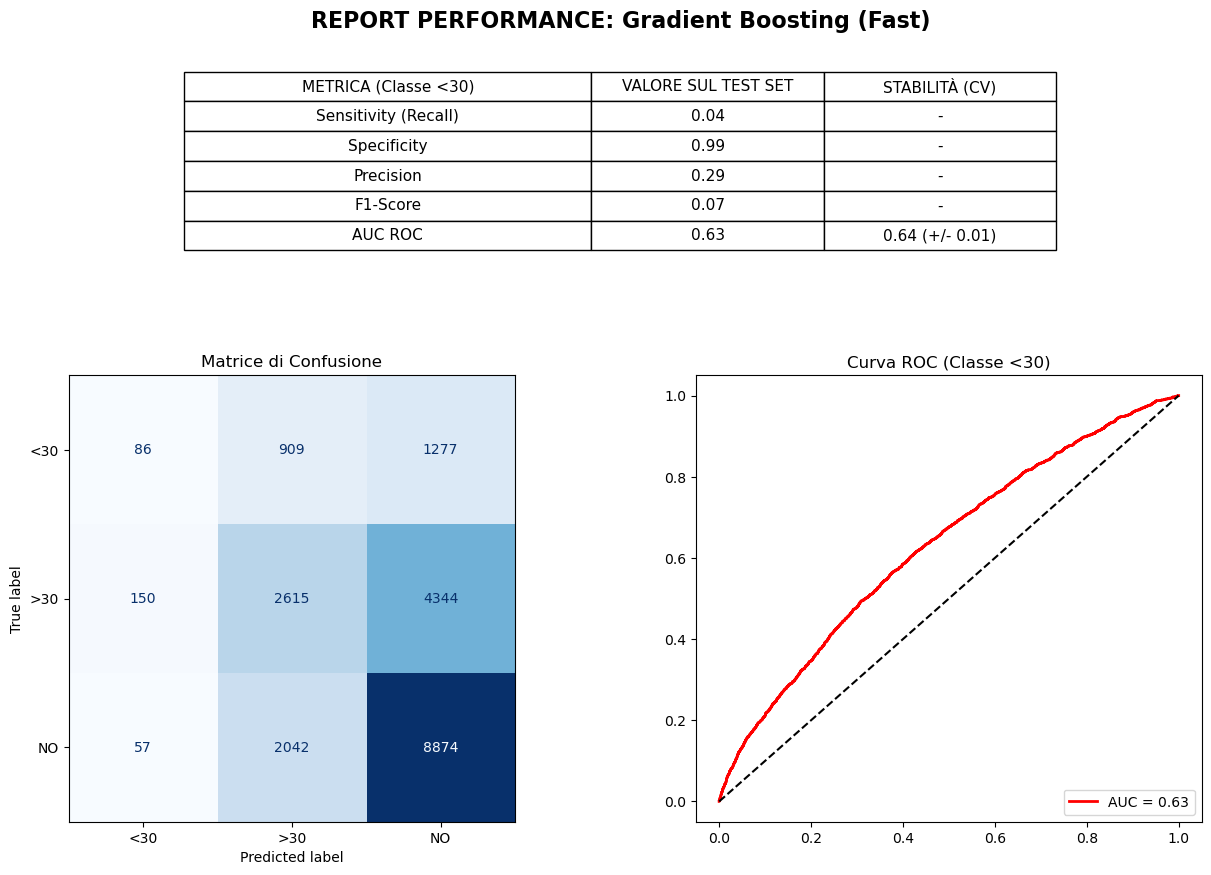

Inizio addestramento: Fast SVM...
La classe <30 si trova all'indice: 0


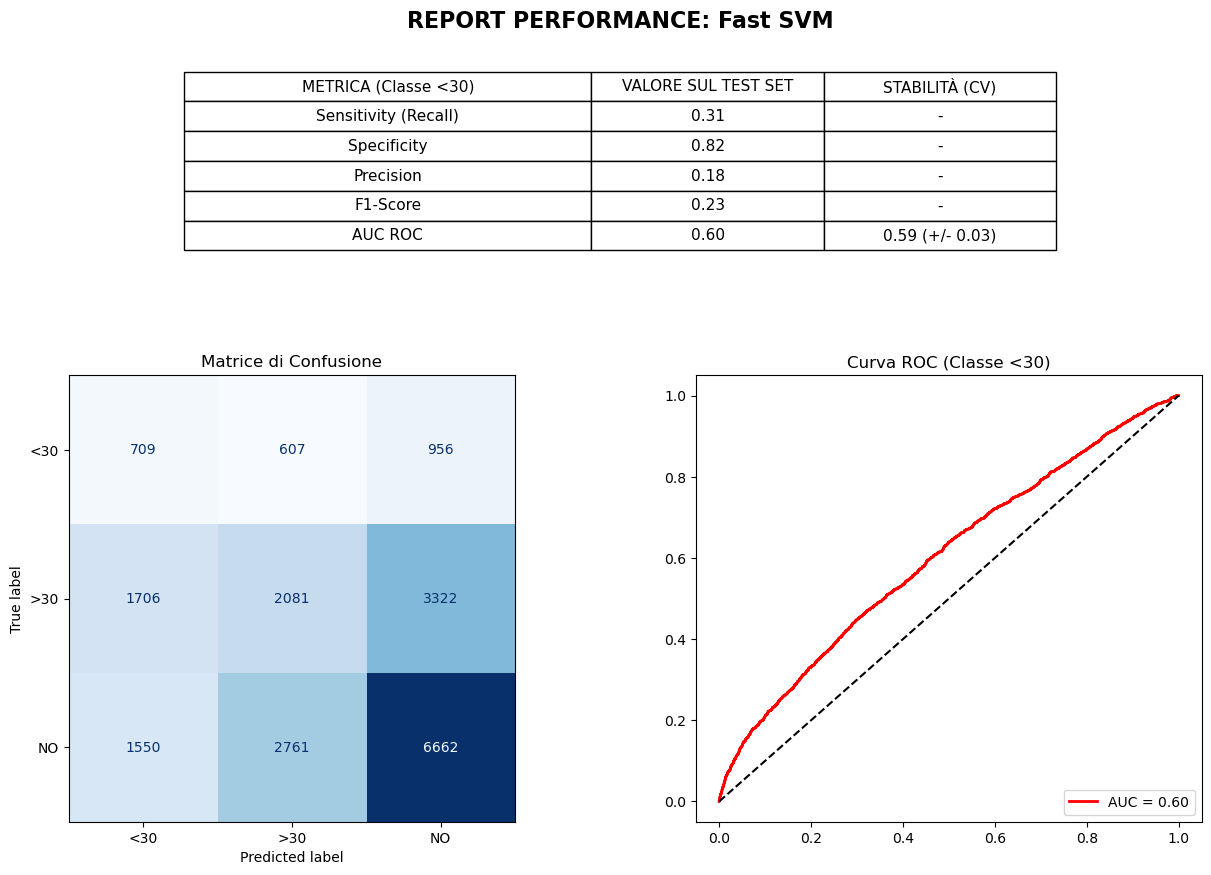

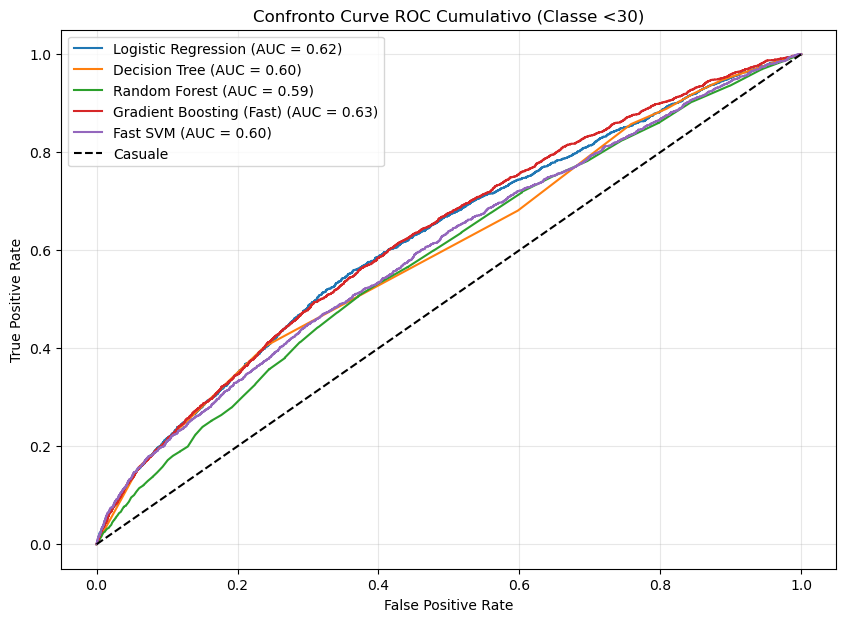


ANALISI MIGLIOR MODELLO: Gradient Boosting (Fast)
Calcolo Permutation Importance (Mapping nomi)...


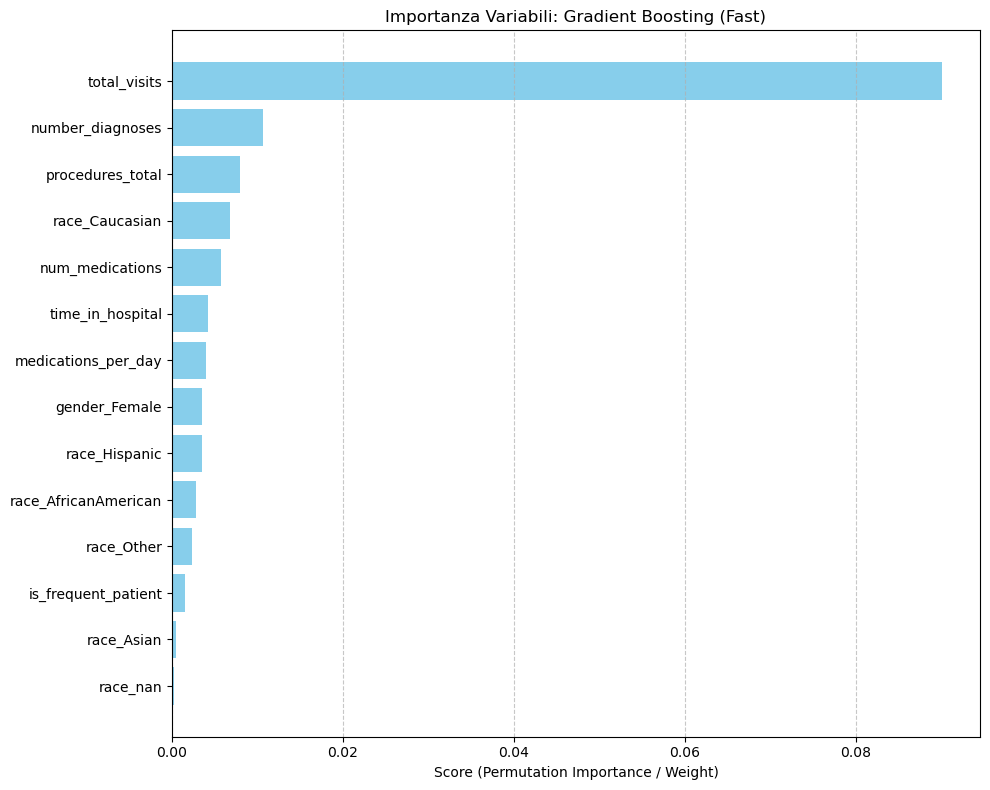

In [23]:
# DIZIONARIO MODELLI
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators = 100, n_jobs=-1, class_weight='balanced', random_state=42),
    "Gradient Boosting (Fast)": HistGradientBoostingClassifier(max_iter=50, class_weight='balanced', random_state=42),    
    "Fast SVM": SGDClassifier(loss='modified_huber', n_jobs=-1, class_weight='balanced', random_state=42)
}

# Inizializzazione storage
performance_summary = []
#inizializziamo per il confronto
best_auc = 0
best_model_name = ""
best_pipeline = None

# Prepariamo la lista per memorizzare i dati della ROC cumulativa
all_fpr = {}
all_tpr = {}
all_auc = {}

for name, model in models.items():
    print(f"Inizio addestramento: {name}...") # Per monitorare i progressi
    # Pipeline con SMOTE per bilanciare i dati solo nel training
    full_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
        ('classifier', model)
    ])

    # --- CROSS-VALIDATION ---
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=skf, scoring='roc_auc_ovr_weighted', n_jobs=-1)
    mean_cv_auc = cv_scores.mean()
    std_cv_auc = cv_scores.std()
    
    # Fit finale sul set di training completo per le predizioni sul test set
    full_pipeline.fit(X_train, y_train)

    classi_modello = list(full_pipeline.classes_)
    if '<30' not in classi_modello:
        print(f"Errore: classe <30 non trovata per {name}. Classi: {classi_modello}")
        continue
    
    idx_30 = classi_modello.index('<30')
    print(f"La classe <30 si trova all'indice: {idx_30}")

    #predizioni
    y_pred = full_pipeline.predict(X_test)    
    y_proba = full_pipeline.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    
    # Calcolo Metriche Cliniche (Classe <30 - Indice 2)
    report = classification_report(y_test, y_pred, output_dict=True)
    precision_val = report['<30']['precision']
    f1_val = report['<30']['f1-score']
    cm = confusion_matrix(y_test, y_pred, labels=classi_modello)
    tp = cm[idx_30, idx_30]
    fn = cm[idx_30, :].sum() - tp
    fp = cm[:, idx_30].sum() - tp
    tn = cm.sum() - (tp + fn + fp)
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    report = classification_report(y_test, y_pred, output_dict=True)
    precision_val = report['<30']['precision']
    f1_val = report['<30']['f1-score']
    auc_score = roc_auc_score((y_test == '<30').astype(int), y_proba[:, idx_30]) if y_proba is not None else 0
    
    performance_summary.append({
        'Modello': name,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'AUC': auc_score
    })
    
    # --- VISUALIZZAZIONE ---
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 2.5])

    # A. TABELLA METRICHE (Sopra)
    ax_table = fig.add_subplot(gs[0, :])
    ax_table.axis('off')
    table_data = [
        ["METRICA (Classe <30)", "VALORE SUL TEST SET", "STABILITÀ (CV)"],
        ["Sensitivity (Recall)", f"{sensitivity:.2f}", "-"],
        ["Specificity", f"{specificity:.2f}", "-"],
        ["Precision", f"{precision_val:.2f}", "-"],
        ["F1-Score", f"{f1_val:.2f}", "-"],
        ["AUC ROC", f"{auc_score:.2f}", f"{mean_cv_auc:.2f} (+/- {std_cv_auc*2:.2f})"]
    ]
    table = ax_table.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.35, 0.2, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.0, 2.0)
    ax_table.set_title(f"REPORT PERFORMANCE: {name}", fontsize=16, fontweight='bold', y=1.2)

    # B. MATRICE DI CONFUSIONE (Sotto a Sinistra)
    ax_cm = fig.add_subplot(gs[1, 0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classi_modello)
    disp.plot(cmap='Blues', ax=ax_cm, colorbar=False)
    ax_cm.set_title("Matrice di Confusione")

    # C. CURVA ROC (Sotto a Destra)
    ax_roc = fig.add_subplot(gs[1, 1])
    if y_proba is not None:
        fpr, tpr, _ = roc_curve((y_test == '<30').astype(int), y_proba[:, idx_30])
        all_fpr[name], all_tpr[name], all_auc[name] = fpr, tpr, auc_score
        ax_roc.plot(fpr, tpr, color='red', lw=2, label=f'AUC = {auc_score:.2f}')
        ax_roc.plot([0, 1], [0, 1], 'k--')
        ax_roc.set_title(f"Curva ROC (Classe <30)")
        ax_roc.legend(loc='lower right')
    
    plt.subplots_adjust(top=0.85, bottom=0.1, hspace=0.4, wspace=0.3)
    plt.show()

    if auc_score > best_auc:
        best_auc = auc_score
        best_sensitivity = sensitivity
        best_model_name = name
        best_pipeline = full_pipeline
    elif auc_score == best_auc:
        if sensitivity > best_sensitivity:
            best_sensitivity = sensitivity
            best_model_name = name
            best_pipeline = full_pipeline
            best_auc = auc

# 4. CURVA ROC CUMULATIVA
plt.figure(figsize=(10, 7))
for name in all_fpr:
    plt.plot(all_fpr[name], all_tpr[name], label=f'{name} (AUC = {all_auc[name]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Casuale')
plt.title("Confronto Curve ROC Cumulativo (Classe <30)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
        
# 6. ANALISI DELL'IMPORTANZA (FIX NOMI FEATURE)

if best_pipeline:
    print(f"\n" + "="*45)
    print(f"ANALISI MIGLIOR MODELLO: {best_model_name}")
    print("="*45)

    # --- RICOSTRUZIONE MANUALE NOMI FEATURE ---
    # Recuperiamo le colonne numeriche originali
    # Recuperiamo le colonne categoriche espanse dall'OneHotEncoder

    try:
        # Metodo moderno per scikit-learn >= 1.2
        feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
    except:
        # Metodo manuale se il precedente fallisce
        cat_transformer = best_pipeline.named_steps['preprocessor'].named_transformers_['cat']
        # Se c'è un OneHotEncoder dentro la pipeline categorica
        if 'onehot' in cat_transformer.named_steps:
            ohe_names = cat_transformer.named_steps['onehot'].get_feature_names_out(cat_cols_key)
        else:
            ohe_names = cat_cols_key
        feature_names = np.concatenate([numeric_cols_1, ohe_names])
    model_final = best_pipeline.named_steps['classifier']

    model_final = best_pipeline.named_steps['classifier']
    classi_finali = list(best_pipeline.classes_)
    idx_30_final = classi_finali.index('<30')
    
    # --- CALCOLO IMPORTANZA ---
    if hasattr(model_final, "feature_importances_"):
        importances = model_final.feature_importances_
    elif hasattr(model_final, "coef_"):
        # Prendiamo i coefficienti per la classe <30
        importances = np.abs(model_final.coef_[0]) 
    else:
        print("Calcolo Permutation Importance (Mapping nomi)...")
        r = permutation_importance(best_pipeline, X_test, y_test,
                                   n_repeats=3, random_state=42, scoring='roc_auc_ovr_weighted')
        importances = r.importances_mean

    # --- CREAZIONE DATAFRAME PULITO ---
    # Usiamo il troncamento per sicurezza se le lunghezze differiscono ancora
    min_len = min(len(feature_names), len(importances))
    feat_imp = pd.DataFrame({
        "Feature": feature_names[:min_len], 
        "Importance": importances[:min_len]
    }).sort_values(by="Importance", ascending=False)

    # Pulizia nomi (rimuoviamo i prefissi 'num__' e 'cat__')
    feat_imp["Feature"] = feat_imp["Feature"].str.replace("num__", "").str.replace("cat__", "")
    # --- GRAFICO ---
    plt.figure(figsize=(10, 8))
    # Prendiamo le prime 10 o tutte se sono meno
    top_n = min(15, len(feat_imp))
    plt.barh(feat_imp["Feature"].head(top_n), feat_imp["Importance"].head(top_n), color='skyblue')
    plt.gca().invert_yaxis()
    plt.title(f"Importanza Variabili: {best_model_name}")
    plt.xlabel("Score (Permutation Importance / Weight)")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [24]:
#Per questa analisi è stato utilizzato l'algoritmo Linear SVM (tramite SGDClassifier) in sostituzione del classico SVC (Support Vector Classifier).
#Questa scelta è stata dettata dall'elevata dimensionalità del dataset; mentre il modello SVC standard presenta tempi di elaborazione quadratici
#che rendevano il calcolo computazionalmente proibitivo, la versione lineare permette di ottenere risultati comparabili in una frazione del tempo, 
#garantendo l'efficienza della pipeline di test. Un altro cambiamento è stato effettuato nel passaggio da GradientBoosting a HistGradientBoosting
#A causa della lentezza del modello standard, si è passati a HistGradientBoosting (Fast). Questo algoritmo utilizza la discretizzazione dei valori
#per accelerare la ricerca degli split ottimali negli alberi, permettendo di processare l'intero dataset in pochi secondi invece di diversi minuti.
#Cambio effettuato poichè l'addestramento del gradient boosting dopo 10/15 minuti ancora non era concluso.


#COMMENTO GRAFICI GENERATI

#(0)TABELLA
#Tutti i modelli mostrano una Sensitivity (Recall) estremamente bassa, con un minimo del 0.04 (Gradient Boosting) e un massimo del 0.39 (Logistic Regression).
#Cosa significa: Il modello è un "setaccio a maglie troppo larghe"; la stragrande maggioranza dei pazienti che verranno realmente riammessi entro 30 giorni (i casi più critici) non viene intercettata.
#Il costo: Sebbene la Specificity sia eccellente (0.76 - 0.99), indicando che i pazienti stabili vengono quasi sempre riconosciuti correttamente, 
#il costo clinico è un numero elevatissimo di falsi negativi. La Logistic Regression è l'unico modello che prova a "rischiare" di più (Sensitivity 0.39).

#(1) MATRICI DI CONFUSIONE 3x3
#Le matrici mostrano una forte polarizzazione sulla classe "NO" o comunque sulle classi maggioritarie. Il modello fatica enormemente a distinguere la classe <30. 
#Questo comportamento indica che le feature selezionate (total_visits, number_diagnoses,...) non contengono segnali univoci per la riammissione precoce, portando 
#il modello a rifugiarsi nella previsione della classe più frequente per massimizzare l'accuratezza globale (Accuracy), a scapito della rilevanza clinica.

#(2) ANALISI CURVE ROC-AUC (Classe <30)
#L'AUC-ROC si attesta tra 0.59 e 0.63. Rispetto allo 0.50 (casualità), esiste ancora un segnale predittivo, ma è debole. La stabilità della Cross-Validation (+/- 0.01) 
#conferma che il problema non è il rumore nei dati o l'overfitting, ma proprio una mancanza di potere discriminante delle variabili scelte. 
#Un'AUC di 0.62 è considerata "povera" per un contesto decisionale clinico.

#(3) CONFRONTO CUMULATIVO DELLE CURVE ROC
#ITutti i modelli collassano verso performance simili. Il fatto che il Gradient Boosting abbia l'AUC più alta (0.63) ma la Sensitivity più bassa (0.04) 
#suggerisce che il modello ha una buona capacità teorica di ordinare i rischi, ma la "soglia" di decisione predefinita è totalmente inadeguata per catturare la classe minoritaria.

#(4) ANALISI DELLE FEATURE
#Dall'osservazione del grafico delle importanze, emergono i reali driver del modello:
#total_visits: È il predittore assoluto. Questo suggerisce che la "storia" del paziente (quante volte è già stato in ospedale) conta molto più di quello che è successo durante l'ultimo ricovero.
#number_diagnoses: Indica che la multi-morbilità è un fattore chiave.
#race_Caucasian: La comparsa della razza tra le top feature solleva questioni di bias demografico o differenze nell'accesso alle cure che il modello sta intercettando.

#CONCLUSIONE
#L'analisi attuale dimostra che l'attuale subset di feature e la configurazione dei modelli producono un sistema clinicamente troppo conservativo. Sebbene non generi molti falsi allarmi (alta Specificity),
#fallisce nel suo obiettivo primario: identificare i pazienti a rischio di rientro immediato. Il "tetto massimo" di AUC intorno a 0.63 conferma che le variabili sintetiche e cliniche attuali 
#descrivono bene la cronicità del paziente (total_visits), ma non l'evento acuto che scatena la riammissione entro 30 giorni. Per migliorare, è necessario reintrodurre variabili legate alla gestione
#dei farmaci o ai risultati specifici dei test di laboratorio, precedentemente esclusi.

Raggruppamento diagnosi in corso...
Analisi avviata su 41 feature totali.
Inizio addestramento: Logistic Regression...


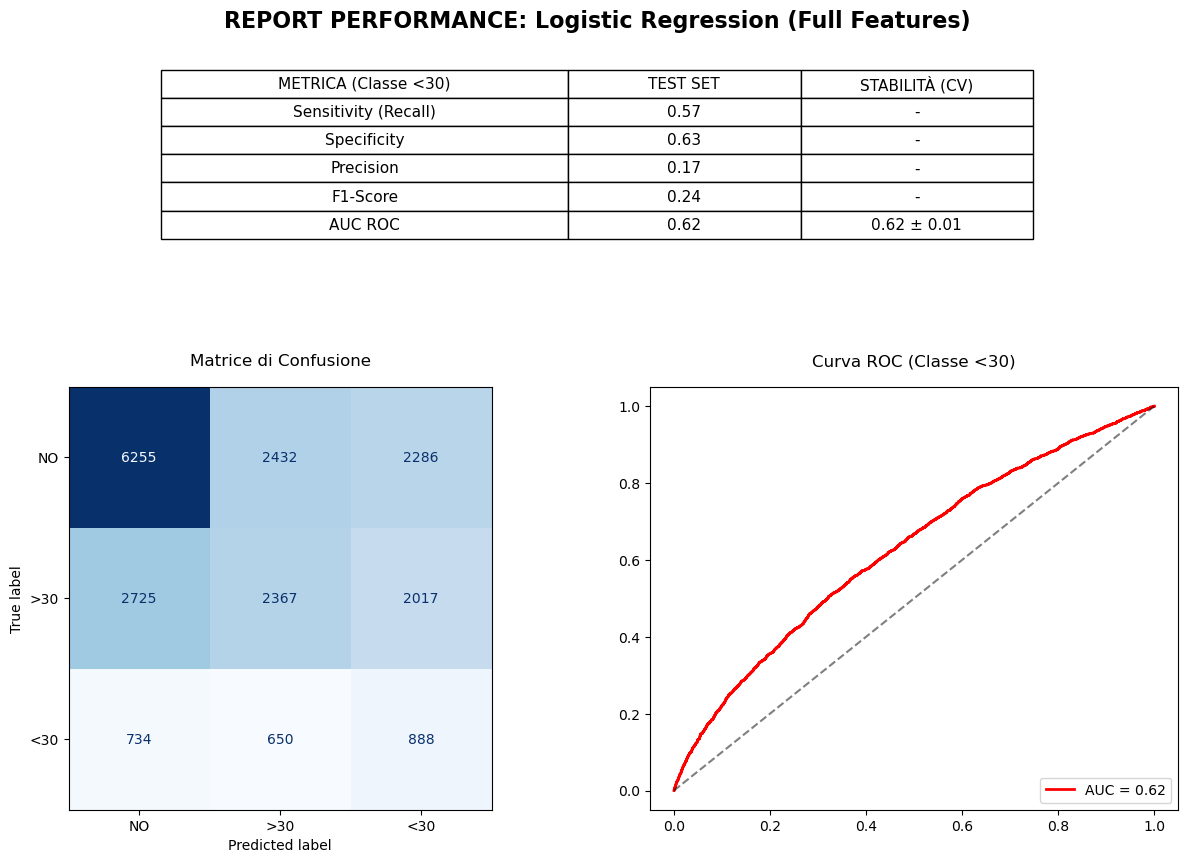

Completato: Logistic Regression
Inizio addestramento: Decision Tree...


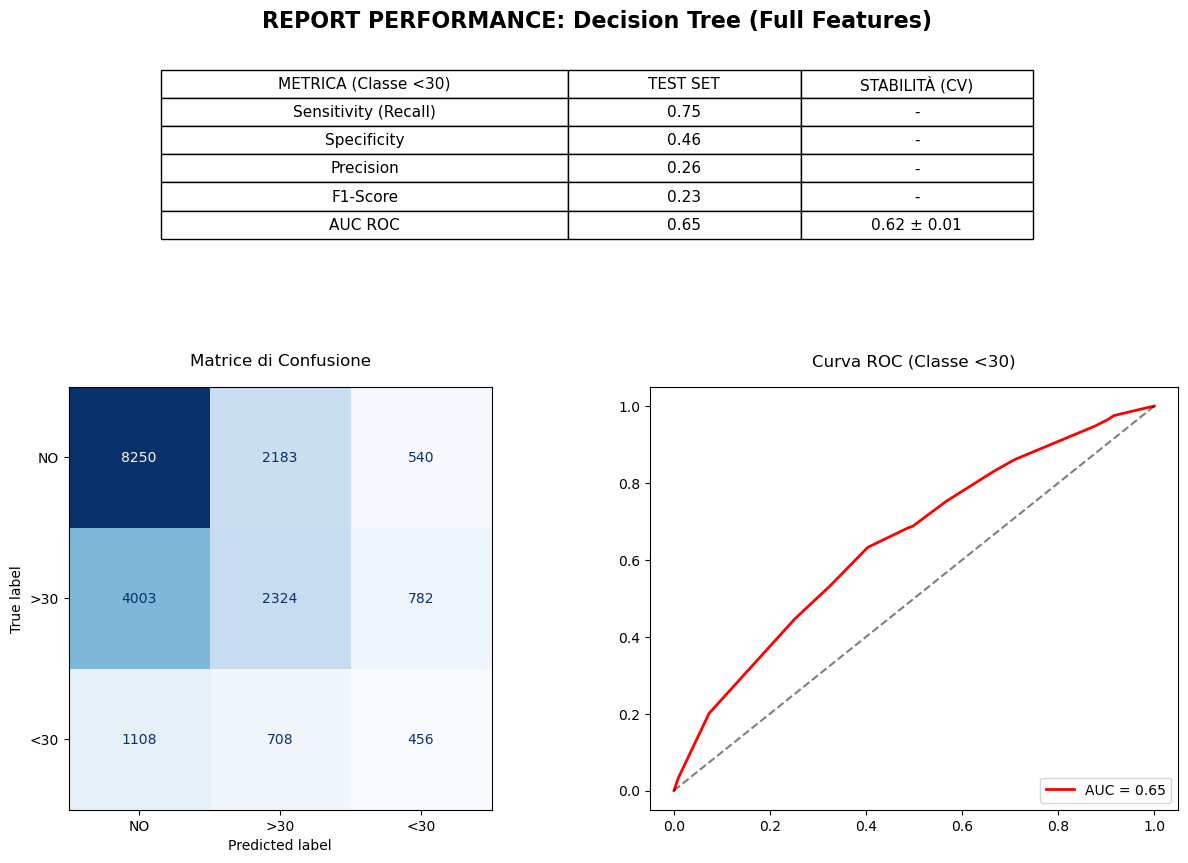

Completato: Decision Tree
Inizio addestramento: Random Forest...


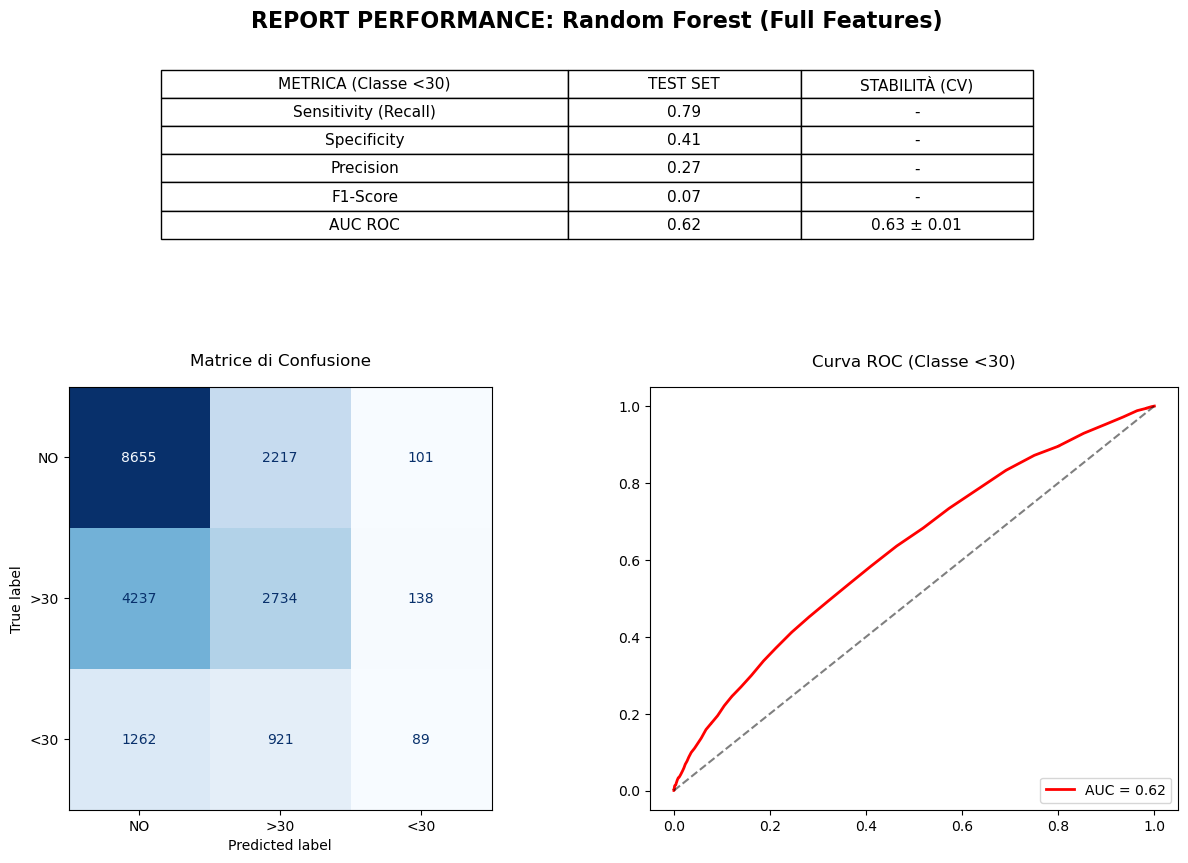

Completato: Random Forest
Inizio addestramento: Gradient Boosting (Fast)...


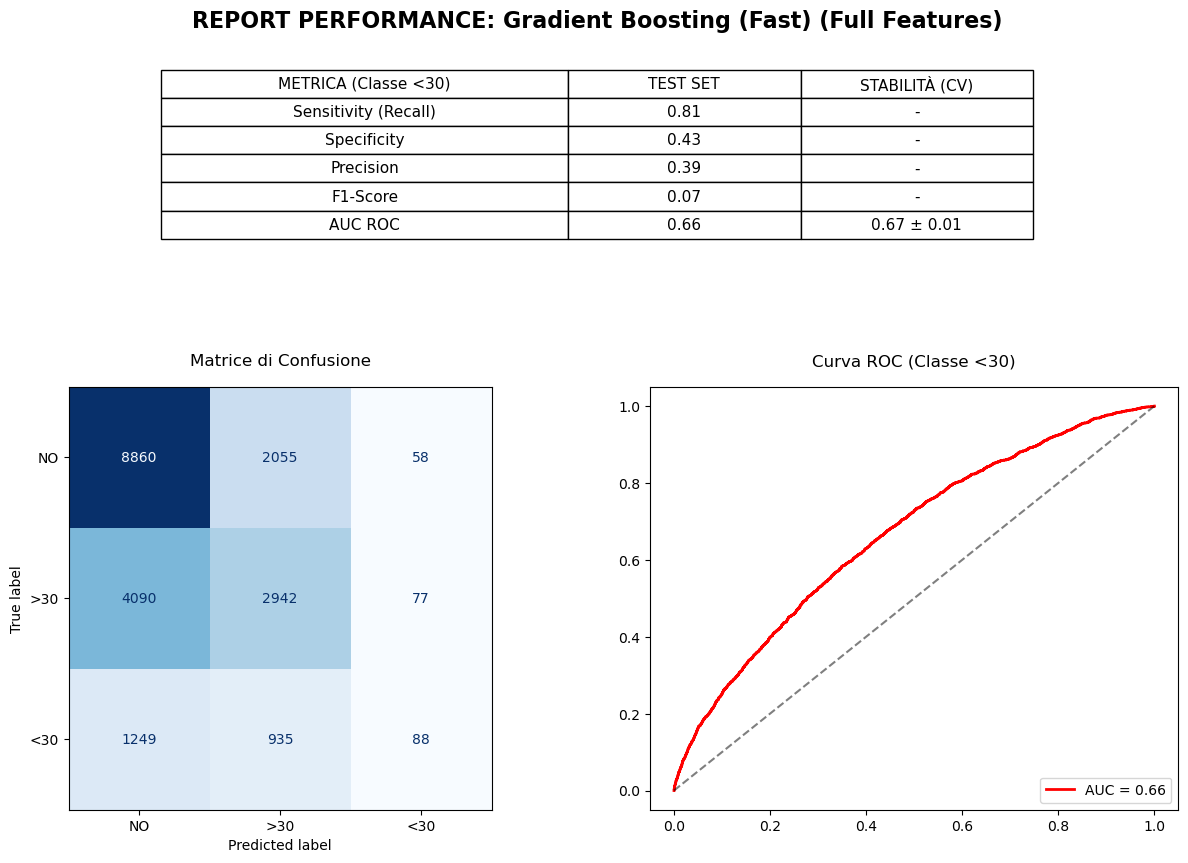

Completato: Gradient Boosting (Fast)
Inizio addestramento: Linear SVM...


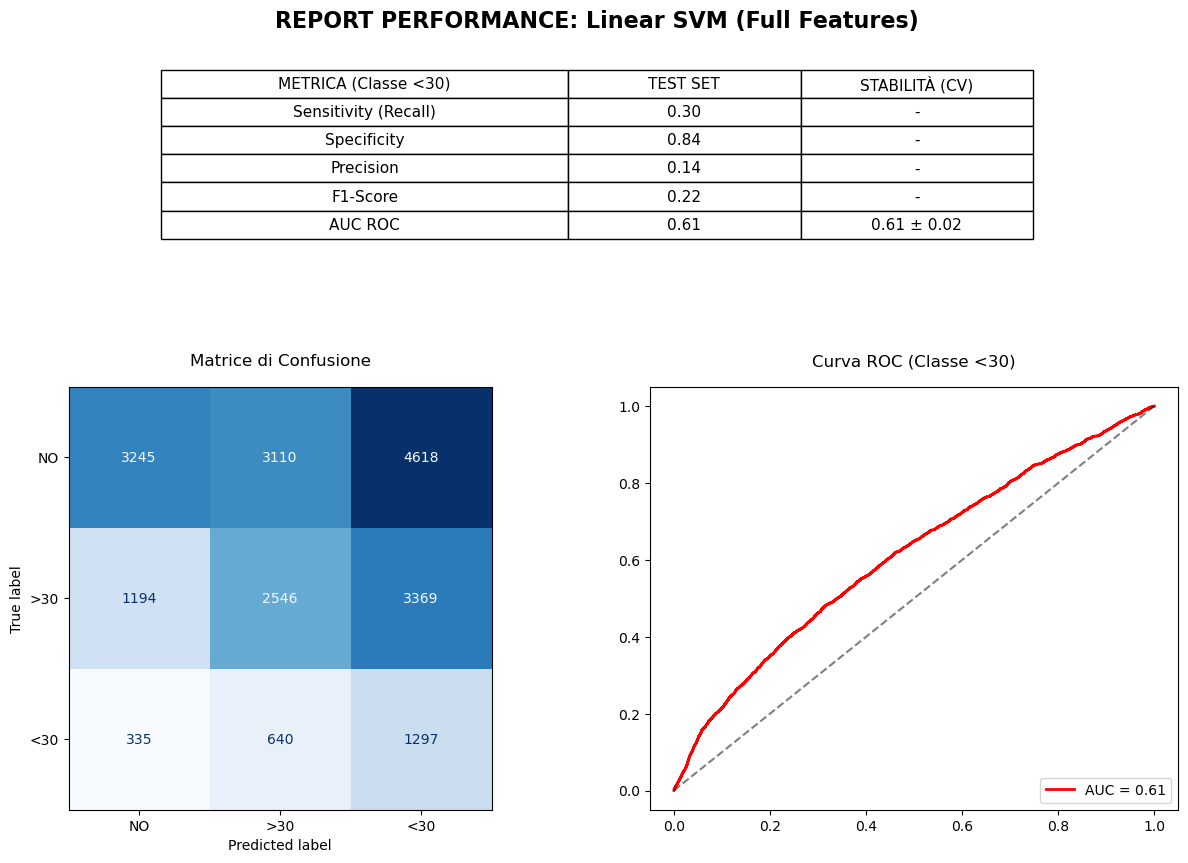

Completato: Linear SVM


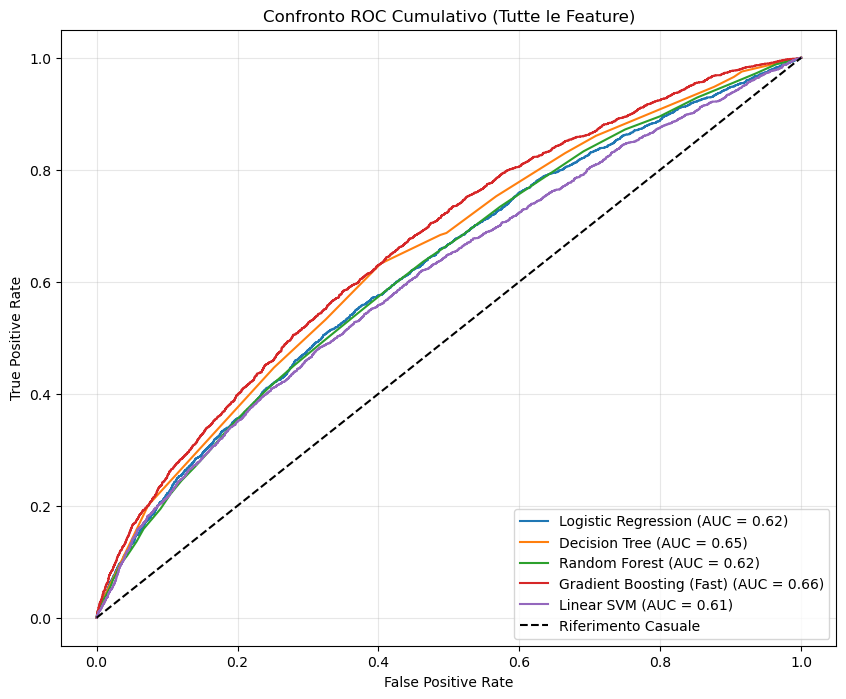


ANALISI MIGLIOR MODELLO: Gradient Boosting (Fast) (AUC = 0.66)
Calcolo Permutation Importance su dati trasformati...


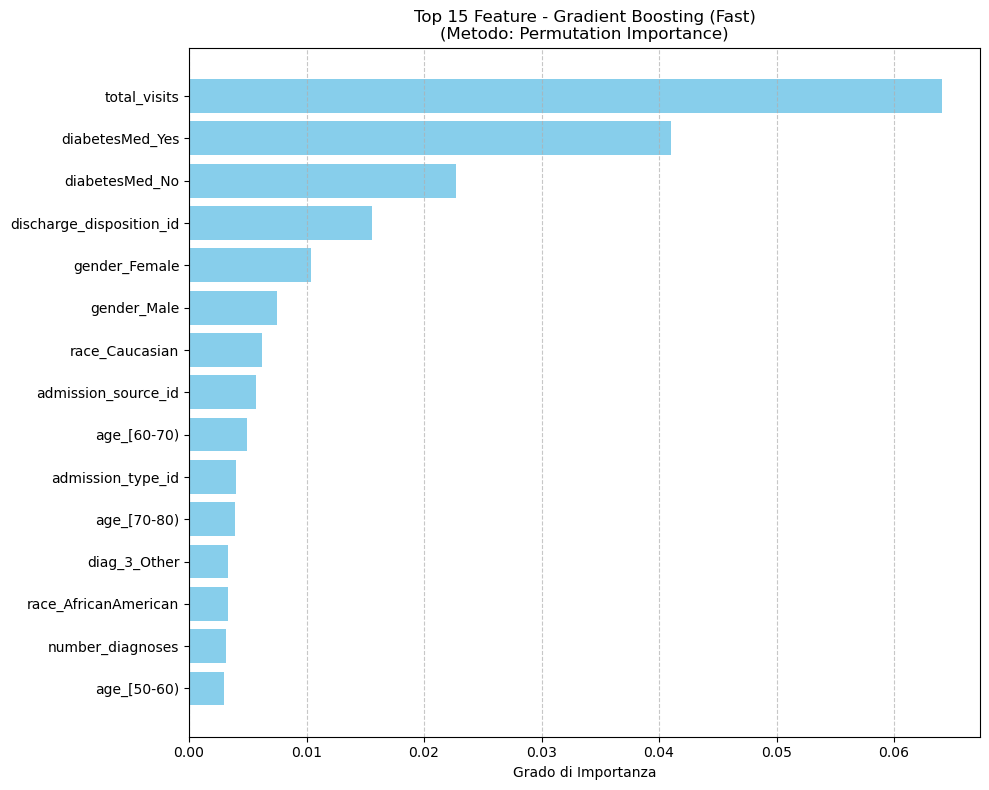

In [25]:
# 1. FUNZIONE DI MAPPATURA ICD-9
def map_icd9(code):
    if pd.isnull(code) or code == '?' or code == 'None':
        return 'Other'
    if str(code).startswith('V') or str(code).startswith('E'):
        return 'Other'
    try:
        val = float(code)
        if 390 <= val <= 459 or val == 785: return 'Circulatory'
        elif 460 <= val <= 519 or val == 786: return 'Respiratory'
        elif 520 <= val <= 579 or val == 787: return 'Digestive'
        elif 250 <= val < 251: return 'Diabetes'
        elif 800 <= val <= 999: return 'Injury'
        elif 710 <= val <= 739: return 'Musculoskeletal'
        elif 580 <= val <= 629 or val == 788: return 'Genitourinary'
        elif 140 <= val <= 239: return 'Neoplasms'
        else: return 'Other'
    except ValueError:
        return 'Other'

# 2. APPLICAZIONE DEL RAGGRUPPAMENTO
df_ml1 = df_hospital_clean.copy()

print("Raggruppamento diagnosi in corso...")
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_ml1[col] = df_ml1[col].apply(map_icd9)

# Definiamo il target multiclasse
class_names = ['NO', '>30', '<30']

# Selezione automatica delle feature (Escludiamo ID, Target e colonne con troppi nulli)
cols_to_exclude = ['encounter_id', 'patient_nbr', 'readmitted', 'readmitted_binary', 'weight', 'payer_code', 'medical_specialty', 'num_medications', 'time_in_hospital','num_procedures', 'num_lab_procedures',
                  'number_outpatient', 'number_emergency', 'number_inpatient']
features = [c for c in df_ml1.columns if c not in cols_to_exclude]

# Suddivisione automatica tra Numeriche e Categoriche
numeric_cols_all = df_ml1[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_ml1[features].select_dtypes(include=['object', 'category']).columns.tolist()

X = df_ml1[features]
y = df_ml1['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Analisi avviata su {len(features)} feature totali.")

# 2. DEFINIZIONE PREPROCESSOR
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_cols_all),
    ('cat', cat_transformer, cat_cols)
])

# 3. DIZIONARIO MODELLI
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state = 42, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, class_weight='balanced', random_state=42),
    "Gradient Boosting (Fast)": HistGradientBoostingClassifier(max_iter=50, class_weight='balanced', random_state=42),    
    "Linear SVM": SGDClassifier(loss='modified_huber', n_jobs=-1, class_weight='balanced', random_state=42)
}


best_auc = 0
best_model_name = ""
best_pipeline = None
all_fpr, all_tpr, all_auc = {}, {}, {}

for i, (name, model) in enumerate(models.items()):
    print(f"Inizio addestramento: {name}...")
    
    full_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
        ('classifier', model)
    ])

    # --- CROSS-VALIDATION ---
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=skf, scoring='roc_auc_ovr', n_jobs=-1)
    
    full_pipeline.fit(X_train, y_train)

    classi = list(full_pipeline.classes_)
    idx_30 = classi.index('<30') # Trova la posizione di <30 (sarà 0)
    
    y_pred = full_pipeline.predict(X_test)
    y_proba = full_pipeline.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    # Calcolo Metriche (Classe <30)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred, labels=class_names)
    
    # Calcolo manuale Sensitivity/Specificity per la classe <30 (Indice 0)
    tp = cm[idx_30, idx_30]
    fn = cm[idx_30, :].sum() - tp
    fp = cm[:, idx_30].sum() - tp
    tn = cm.sum() - (tp + fn + fp)
    
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc_test = roc_auc_score((y_test == '<30').astype(int), y_proba[:, idx_30]) if y_proba is not None else 0

    # --- VISUALIZZAZIONE ---
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 2.5]) 

    # A. TABELLA (Sopra)
    ax_table = fig.add_subplot(gs[0, :])
    ax_table.axis('off')
    
    table_data = [
        ["METRICA (Classe <30)", "TEST SET", "STABILITÀ (CV)"],
        ["Sensitivity (Recall)", f"{sens:.2f}", "-"],
        ["Specificity", f"{spec:.2f}", "-"],
        ["Precision", f"{report['<30']['precision']:.2f}", "-"],
        ["F1-Score", f"{report['<30']['f1-score']:.2f}", "-"],
        ["AUC ROC", f"{auc_test:.2f}", f"{cv_scores.mean():.2f} ± {cv_scores.std()*2:.2f}"]
    ]
    
    tbl = ax_table.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.35, 0.2, 0.2])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.0, 2.0)
    ax_table.set_title(f"REPORT PERFORMANCE: {name} (Full Features)", fontsize=16, fontweight='bold', y=1.2)
    
    # B. MATRICE (Sotto a Sinistra)
    ax_cm = fig.add_subplot(gs[1, 0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', ax=ax_cm, colorbar=False)
    ax_cm.set_title("Matrice di Confusione", pad=15)

    # C. ROC (Sotto a Destra)
    ax_roc = fig.add_subplot(gs[1, 1])
    if y_proba is not None:
        fpr, tpr, _ = roc_curve((y_test == '<30').astype(int), y_proba[:, idx_30])
        all_fpr[name], all_tpr[name], all_auc[name] = fpr, tpr, auc_test
        ax_roc.plot(fpr, tpr, color='red', lw=2, label=f'AUC = {auc_test:.2f}')
        ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax_roc.set_title("Curva ROC (Classe <30)", pad=15)
        ax_roc.legend(loc='lower right')
    
    plt.subplots_adjust(top=0.85, hspace=0.5)
    plt.show()
    
    if auc_test > best_auc:
        best_auc = auc_test
        best_model_name = name
        best_pipeline = full_pipeline            
    print(f"Completato: {name}")

# 4. CONFRONTO CUMULATIVO
plt.figure(figsize=(10, 8))
for name in all_fpr:
    plt.plot(all_fpr[name], all_tpr[name], label=f'{name} (AUC = {all_auc[name]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Riferimento Casuale')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Confronto ROC Cumulativo (Tutte le Feature)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 6. IMPORTANZA DELLE FEATURE (VERSIONE DEFINITIVA)
if best_pipeline:
    print(f"\n" + "="*45)
    print(f"ANALISI MIGLIOR MODELLO: {best_model_name} (AUC = {best_auc:.2f})")
    print("="*45)

    # 1. Trasformiamo X_test per avere le stesse dimensioni delle feature (143)
    X_test_transformed = best_pipeline.named_steps['preprocessor'].transform(X_test)
    raw_feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
    feature_names = [name.replace('num__', '').replace('cat__', '') for name in raw_feature_names]
    
    model_final = best_pipeline.named_steps['classifier']
    idx_30_final = list(best_pipeline.classes_).index('<30')

    # 2. Estrazione importanze
    if hasattr(model_final, "feature_importances_"):
        # HistGradientBoosting e Alberi
        importances = model_final.feature_importances_
        method = "Feature Importance (Model Native)"
    elif hasattr(model_final, "coef_"):
        # Modelli Lineari
        if len(model_final.coef_) > 1:
            importances = np.abs(model_final.coef_[idx_30_final])
        else:
            importances = np.abs(model_final.coef_[0])
        method = "Absolute Coefficients"
    else:
        # Permutation Importance sui dati trasformati
        print(f"Calcolo Permutation Importance su dati trasformati...")
        r = permutation_importance(model_final, X_test_transformed, y_test, n_repeats=3, random_state=42)
        importances = r.importances_mean
        method = "Permutation Importance"

    # 3. Verifica e Creazione DataFrame
    if len(feature_names) == len(importances):
        feat_imp = pd.DataFrame({
            "Feature": feature_names, 
            "Importance": importances
        }).sort_values(by="Importance", ascending=False)
        
        # Pulizia nomi per visualizzazione
        feat_imp["Feature"] = feat_imp["Feature"].str.replace(r'^(num__|cat__)', '', regex=True)
        
        # VISUALIZZAZIONE
        plt.figure(figsize=(10, 8))
        top_n = min(15, len(feat_imp)) # Mostriamo le prime 15
        plt.barh(feat_imp["Feature"].head(top_n), feat_imp["Importance"].head(top_n), color='skyblue')
        plt.gca().invert_yaxis()
        plt.title(f"Top {top_n} Feature - {best_model_name}\n(Metodo: {method})")
        plt.xlabel("Grado di Importanza")
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        # Fallback di emergenza se HistGradientBoosting usa un numero diverso di feature interne
        print(f"Dimensioni: {len(feature_names)} nomi vs {len(importances)} valori.")

In [26]:
#L'estensione dell'analisi a 45 feature e l'utilizzo di modelli complessi su un dataset di oltre 100.000 righe hanno richiesto una revisione della pipeline per evitare tempi di attesa superiori ai 15-20 minuti.
#esclusione di alcune feature
#Abbiamo rimosso le variabili originarie (num_medications, time_in_hospital, num_procedures, num_lab_procedures, number_inpatient, ecc.) utilizzate per generare le variabili aggregate (medications_per_day, procedures_total, total_visits). 
#Questa scelta è fondamentale per eliminare la multicollinearità: mantenere sia i componenti che il totale avrebbe reso instabili i coefficienti della Logistic Regression e dell'SVM, "diluendo" l'importanza delle variabili e rischiando di 
#introdurre rumore statistico senza aggiungere nuova informazione.
#Cambiamento diag_1, diag_2, diag_3
#I codici ICD-9 originali (centinaia di valori unici) sono stati mappati in 9 macro-categorie cliniche (es. Circulatorio, Respiratorio, Diabete). Questa operazione ha impedito l'esplosione delle colonne durante l'One-Hot Encoding,
#passando da migliaia di potenziali variabili a poche decine.

#INTERPRETAZIONE RISULTATI
#L'espansione del dataset a tutte le variabili disponibili (passando da circa 10 a oltre 140 feature dopo la codifica) ha portato a una modellizzazione più equilibrata, ma ha anche evidenziato la complessità intrinseca della classe <30

#Confronto con l'analisi precedente (Feature Selezionate):
#Bilanciamento Sensitivity/Specificity:
#Nell'analisi precedente con solo 10 feature, i modelli mostravano una Sensitivity bassissima (quasi ciechi sulla classe <30). Con il dataset completo, assistiamo a un'inversione: modelli come Gradient Boosting (0.81), Random Forest (0.79) 
#e Decision Tree (0.75) mostrano una Sensitivity molto elevata. Ciò significa che il modello ora agisce come un ottimo screening preventivo; intercetta la stragrande maggioranza dei pazienti a rischio. Il costo è una Specificity più bassa (0.41 - 0.46),
#indicando un numero elevato di falsi allarmi, ma in un contesto ospedaliero è spesso preferibile monitorare un paziente stabile in più piuttosto che perderne uno critico.

#Capacità Discriminante (AUC-ROC):
#L'AUC-ROC rimane solida e stabile, con il Gradient Boosting che si conferma leader (0.66/0.67). Il fatto che l'AUC non superi lo 0.70 nonostante le 140+ variabili suggerisce che la riammissione entro 30 giorni dipenda da fattori che vanno 
#oltre i dati clinici standard (es. aderenza alla terapia post-dimissione o fattori socio-economici non presenti nel dataset).

#caso SVM:
#L'SVM (SGDClassifier) rimane l'eccezione, con una Specificity alta (0.84) ma una Sensitivity bassa (0.30). Con un numero così elevato di feature categoriche, l'iperpiano lineare fatica a separare la classe minoritaria, tendendo a essere 
#molto più conservativo nelle previsioni rispetto ai modelli basati su alberi.

#Stabilità:
#La deviazione standard della Cross-Validation rimane molto bassa (± 0.01), confermando che i modelli sono robusti e non soffrono di overfitting nonostante l'elevato numero di feature.

#L'analisi dell'importanza delle variabili con il dataset completo (circa 143 feature dopo il preprocessing) rivela un cambiamento fondamentale rispetto all'analisi ridotta:
#total_visits: Si conferma il driver principale. La frequenza totale di interazione con il sistema sanitario è il miglior termometro della fragilità del paziente.
#diabetesMed_Yes/No: La presenza di una terapia per il diabete emerge come un fattore discriminante critico, indicando che la gestione farmacologica attiva è un segnale di complessità clinica che impatta sulla stabilità a breve termine.
#discharge_disposition_id: Questa feature è vitale: la destinazione post-dimissione (es. verso casa vs. strutture di cura) definisce il livello di supporto che il paziente riceverà, influenzando direttamente la probabilità di un rientro precoce.

#CONCLUSIONE
#L'analisi dimostra che il passaggio a un dataset completo ha permesso ai modelli (specialmente quelli di Boosting e Forest) di superare lo stallo della bassa Sensitivity incontrato con poche feature. Sebbene la Precision rimanga contenuta a causa 
#dello sbilanciamento intrinseco del problema, disponiamo ora di un modello di screening robusto che identifica correttamente l'80% dei pazienti a rischio, basandosi non più solo su esami di laboratorio, ma sulla storia clinica complessiva e sulle modalità di dimissione del paziente.

In [27]:
#verifichiamo se trasformando il problema in binario (riammissione, non riammissione) le performance dei vari modelli migliorano

In [28]:
#classificazione binaria
df_ml2 = df_hospital_clean.copy()

# TRASFORMAZIONE BINARIA: 
# 1 se riammesso (<30 o >30), 0 se NO
# Sostituisci la tua riga con questa:
df_ml2['readmitted_bin'] = df_ml2['readmitted'].map({'NO': 0, '>30': 1, '<30': 1}).astype(int)
# 1. PREPARAZIONE DATI
class_names = ['Non Riammesso', 'Riammesso'] # Nuovi nomi classi

X = df_ml2[numeric_cols_1 + cat_cols_key]
y = df_ml2['readmitted_bin'] # Usiamo il nuovo target

# Split Training e Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# 2. DEFINIZIONE PREPROCESSOR
# Trasformatore numerico: Imputazione (se ci sono zeri spuri) + Scaling
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Trasformatore categorico: OneHotEncoding
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_cols_1),
    ('cat', cat_transformer, cat_cols_key)
])

Inizio addestramento: Logistic Regression...


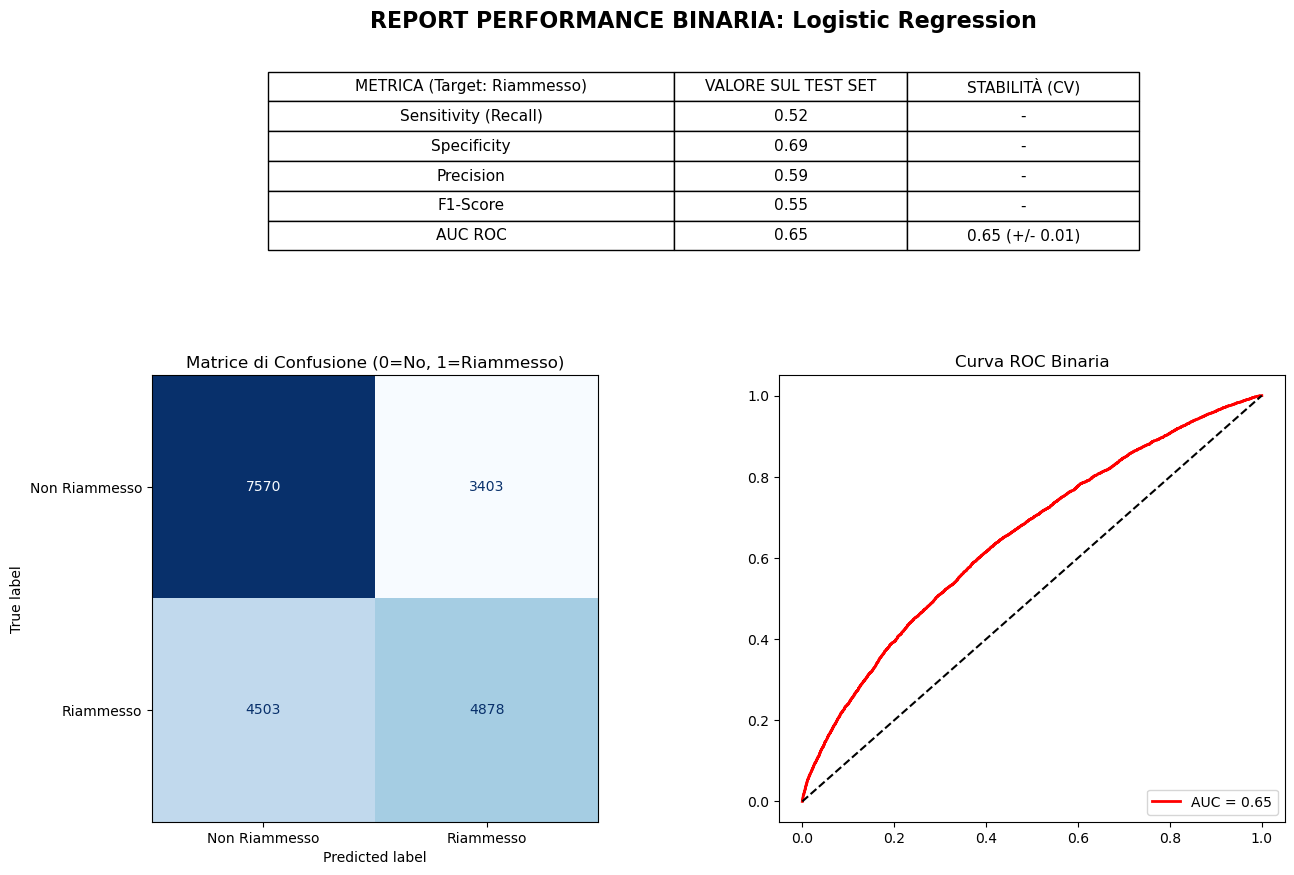

Inizio addestramento: Decision Tree...


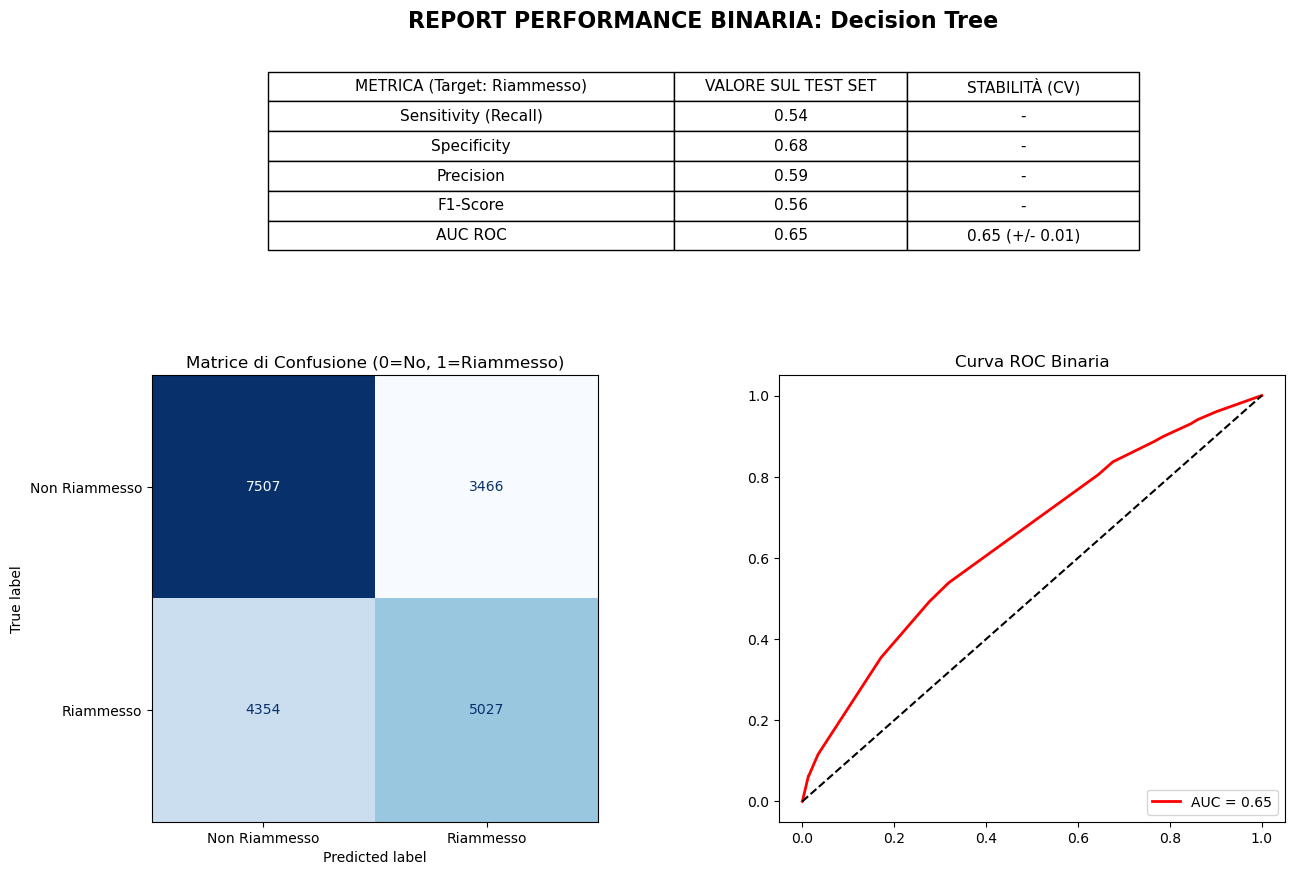

Inizio addestramento: Random Forest...


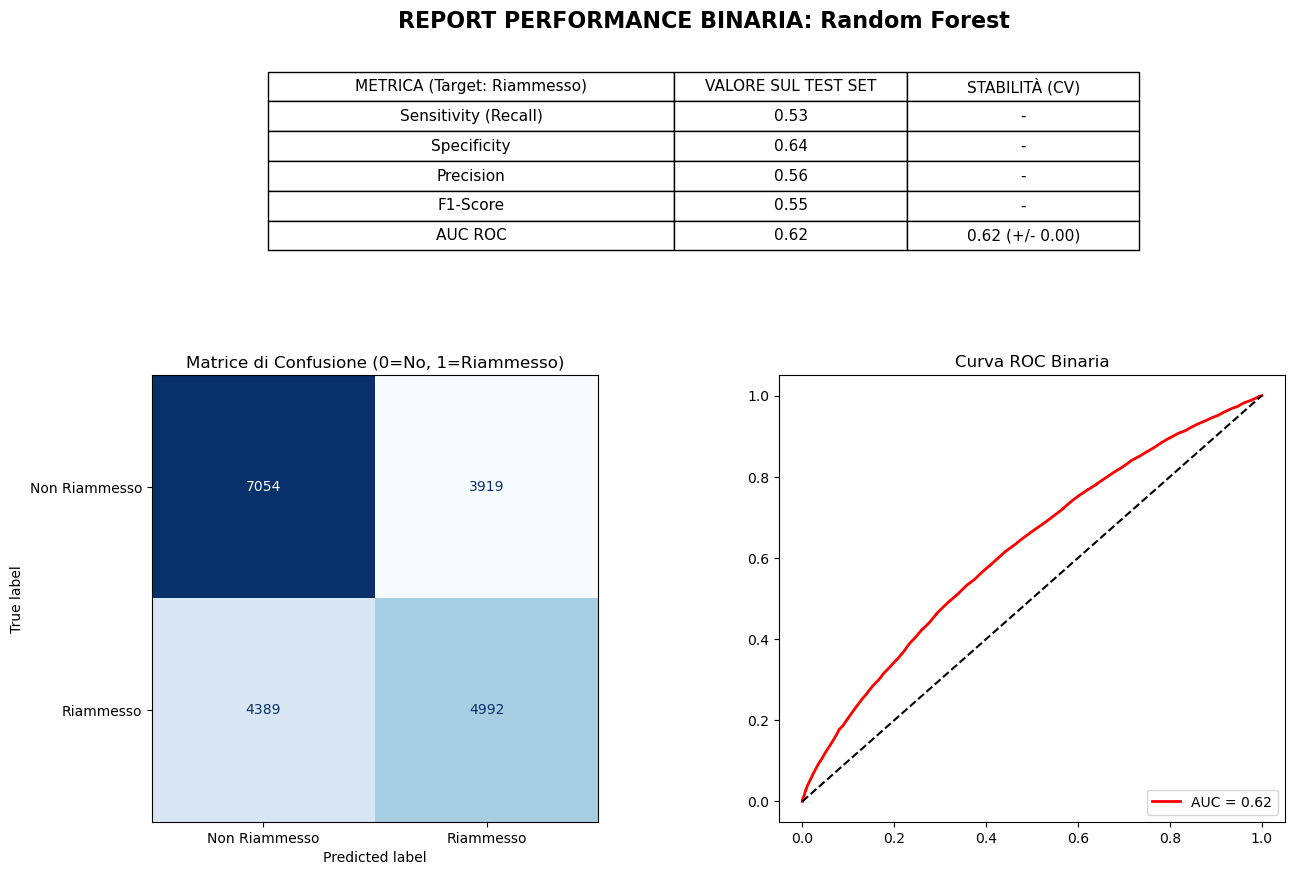

Inizio addestramento: Gradient Boosting (Fast)...


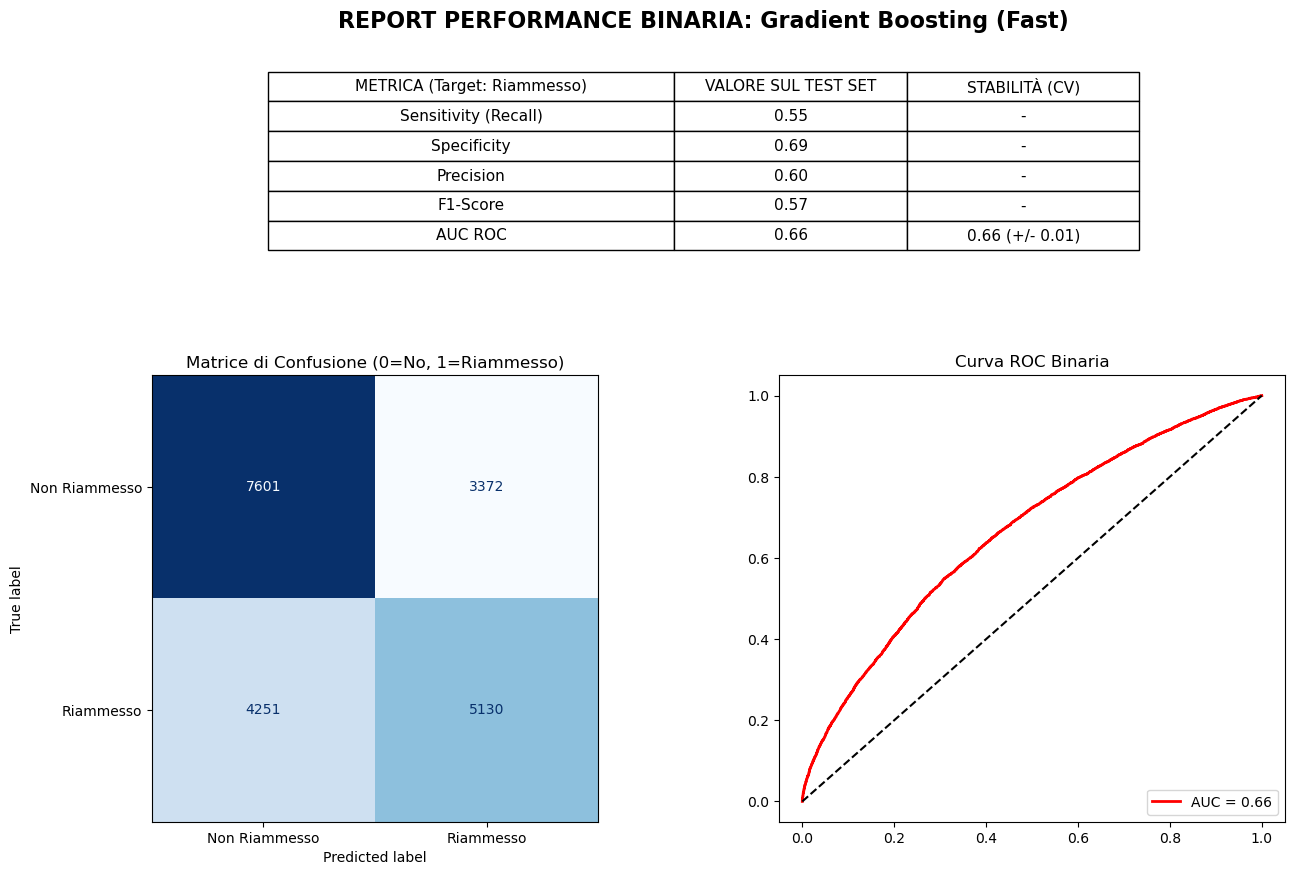

Inizio addestramento: Linear SVM...


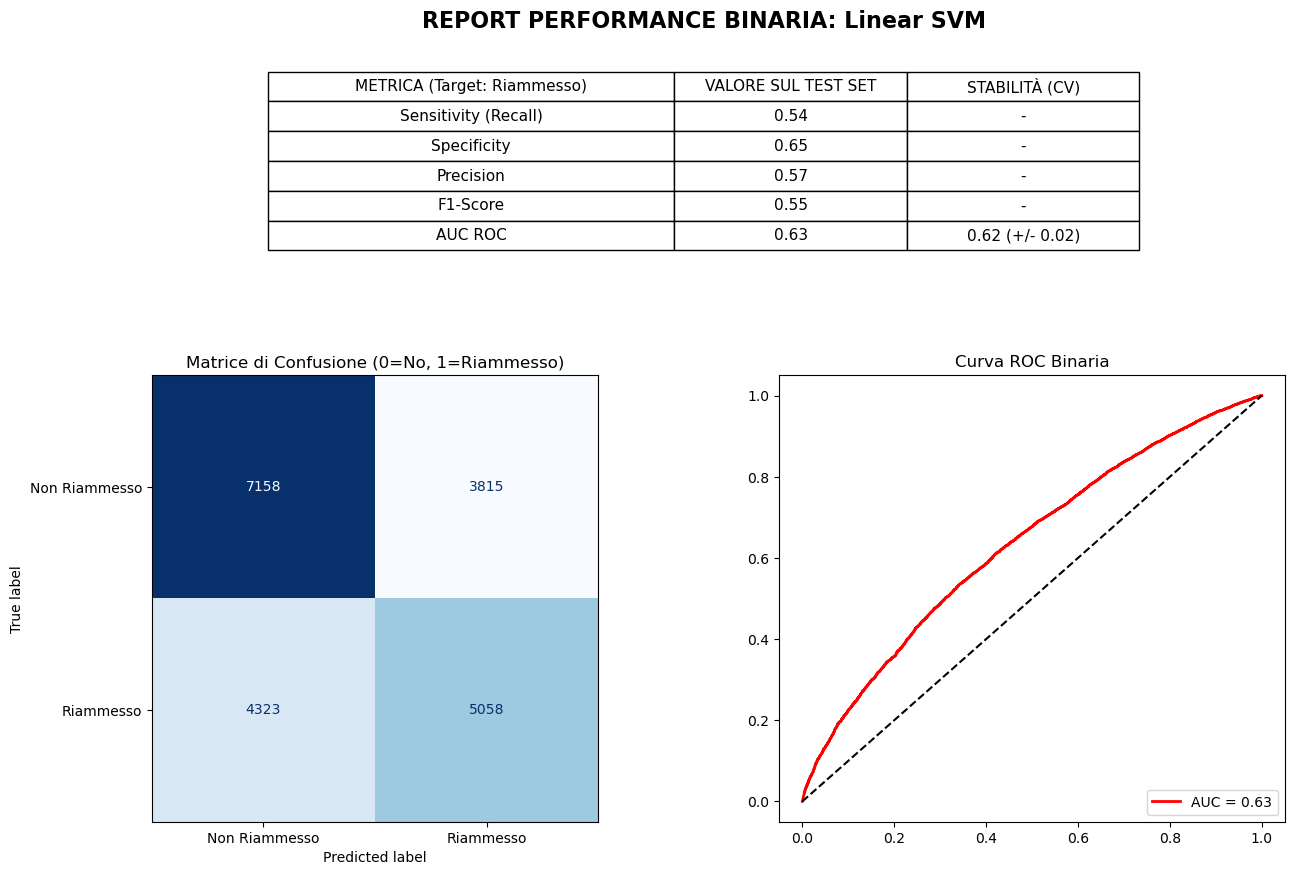

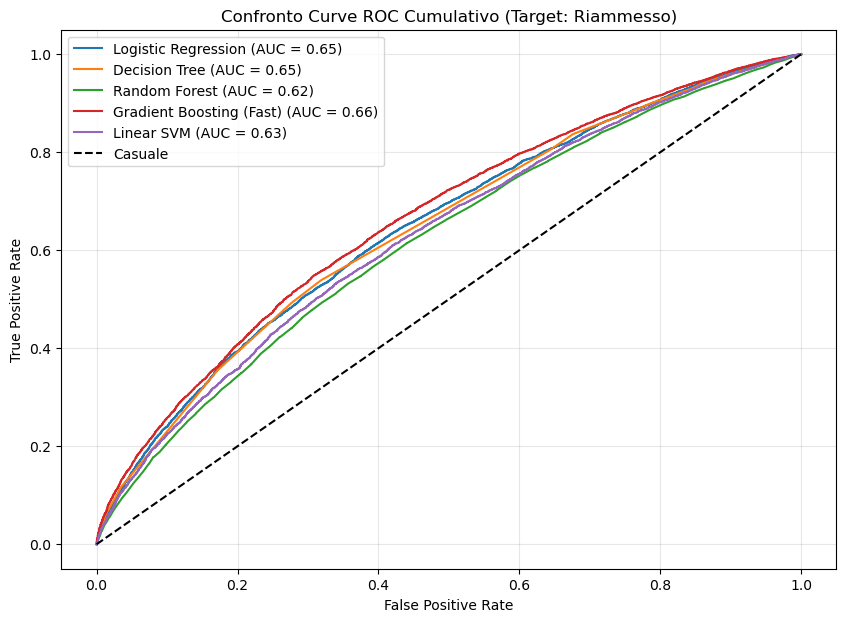


ANALISI MIGLIOR MODELLO: Gradient Boosting (Fast)
Calcolo Permutation Importance su dati trasformati per Gradient Boosting (Fast)...


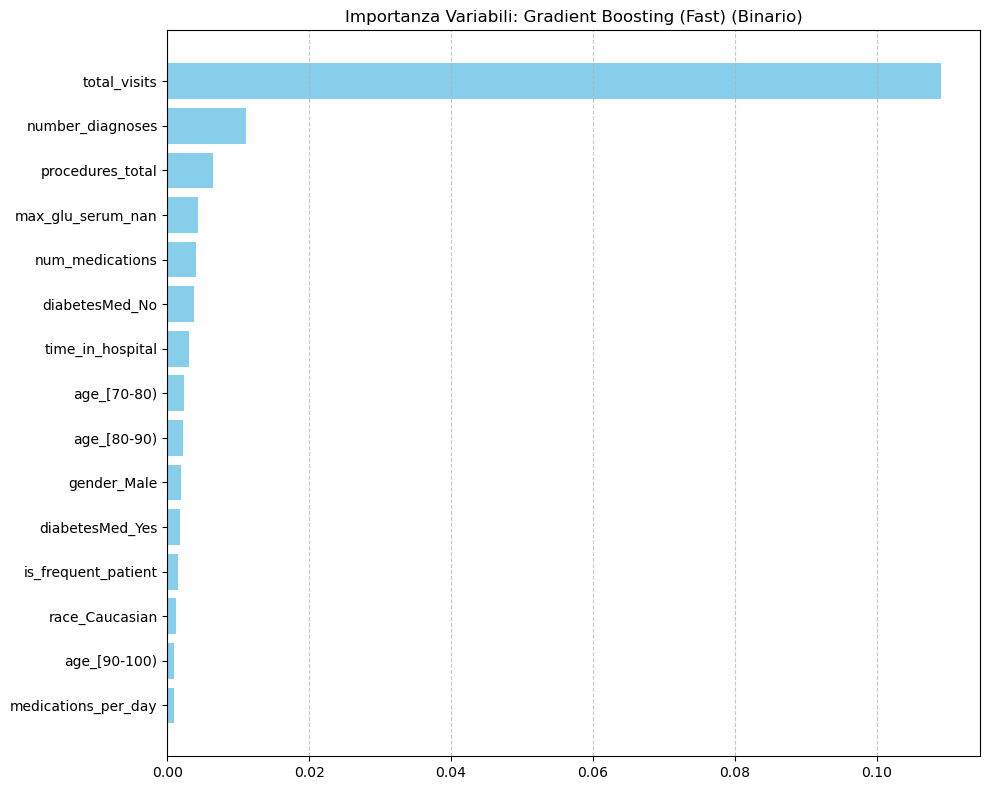

In [29]:
# Inizializzazione storage
performance_summary = []
best_auc = 0
best_model_name = ""
best_pipeline = None

all_fpr = {}
all_tpr = {}
all_auc = {}

for name, model in models.items():
    print(f"Inizio addestramento: {name}...") 
    
    # Pipeline con SMOTE (sampling_strategy='auto' bilancia 0 vs 1)
    full_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
        ('classifier', model)
    ])

    # --- CROSS-VALIDATION ---
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # Cambiato da 'roc_auc_ovr' a 'roc_auc'
    cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)
    mean_cv_auc = cv_scores.mean()
    std_cv_auc = cv_scores.std()
    
    # Fit finale
    full_pipeline.fit(X_train, y_train)
    
    # Predizioni
    y_pred = full_pipeline.predict(X_test)    
    # Per il binario prendiamo la colonna 1 (probabilità di "Riammesso")
    y_proba = full_pipeline.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    # --- CALCOLO METRICHE (Target: Classe 1 - Riammesso) ---
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Accediamo alla chiave '1' (Riammesso)
    precision_val = report['1']['precision']
    f1_val = report['1']['f1-score']
    sensitivity = report['1']['recall'] # Recall della classe positiva
    
    # Matrice di confusione 2x2
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # AUC Score binario
    auc_score = roc_auc_score(y_test, y_proba) if y_proba is not None else 0
    
    performance_summary.append({
        'Modello': name,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'AUC': auc_score
    })
    
    # --- VISUALIZZAZIONE ---
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 2.5])

    # A. TABELLA METRICHE
    ax_table = fig.add_subplot(gs[0, :])
    ax_table.axis('off')
    table_data = [
        ["METRICA (Target: Riammesso)", "VALORE SUL TEST SET", "STABILITÀ (CV)"],
        ["Sensitivity (Recall)", f"{sensitivity:.2f}", "-"],
        ["Specificity", f"{specificity:.2f}", "-"],
        ["Precision", f"{precision_val:.2f}", "-"],
        ["F1-Score", f"{f1_val:.2f}", "-"],
        ["AUC ROC", f"{auc_score:.2f}", f"{mean_cv_auc:.2f} (+/- {std_cv_auc*2:.2f})"]
    ]
    table = ax_table.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.35, 0.2, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.0, 2.0)
    ax_table.set_title(f"REPORT PERFORMANCE BINARIA: {name}", fontsize=16, fontweight='bold', y=1.2)

    # B. MATRICE DI CONFUSIONE (display_labels aggiornate)
    ax_cm = fig.add_subplot(gs[1, 0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', ax=ax_cm, colorbar=False)
    ax_cm.set_title("Matrice di Confusione (0=No, 1=Riammesso)")

    # C. CURVA ROC
    ax_roc = fig.add_subplot(gs[1, 1])
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        all_fpr[name], all_tpr[name], all_auc[name] = fpr, tpr, auc_score
        ax_roc.plot(fpr, tpr, color='red', lw=2, label=f'AUC = {auc_score:.2f}')
        ax_roc.plot([0, 1], [0, 1], 'k--')
        ax_roc.set_title(f"Curva ROC Binaria")
        ax_roc.legend(loc='lower right')
    
    plt.subplots_adjust(top=0.85, bottom=0.1, hspace=0.4, wspace=0.3)
    plt.show()

    if auc_score > best_auc:
        best_auc = auc_score
        best_model_name = name
        best_pipeline = full_pipeline

# 4. CURVA ROC CUMULATIVA (Titolo aggiornato)
plt.figure(figsize=(10, 7))
for name in all_fpr:
    plt.plot(all_fpr[name], all_tpr[name], label=f'{name} (AUC = {all_auc[name]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Casuale')
plt.title("Confronto Curve ROC Cumulativo (Target: Riammesso)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 6. ANALISI DELL'IMPORTANZA (Versione "Blindata")
if best_pipeline:
    print(f"\n" + "="*45)
    print(f"ANALISI MIGLIOR MODELLO: {best_model_name}")
    print("="*45)

    # 1. Recupero nomi feature trasformate
    raw_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
    feature_names = [name.replace("num__", "").replace("cat__", "") for name in raw_names]
    
    model_final = best_pipeline.named_steps['classifier']

    if hasattr(model_final, "feature_importances_"):
        importances = model_final.feature_importances_
    elif hasattr(model_final, "coef_"):
        importances = np.abs(model_final.coef_).flatten()
    else:
        # Calcolo sicuro su dati già trasformati
        print(f"Calcolo Permutation Importance su dati trasformati per {best_model_name}...")
        X_test_trans = best_pipeline.named_steps['preprocessor'].transform(X_test)
        r = permutation_importance(model_final, X_test_trans, y_test, 
                                   n_repeats=3, random_state=42, scoring='roc_auc')
        importances = r.importances_mean

    # Creazione DataFrame (Le lunghezze ora coincideranno sempre)
    feat_imp = pd.DataFrame({
        "Feature": feature_names, 
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)
    
    # Visualizzazione
    plt.figure(figsize=(10, 8))
    top_n = min(15, len(feat_imp))
    plt.barh(feat_imp["Feature"].head(top_n), feat_imp["Importance"].head(top_n), color='skyblue')
    plt.gca().invert_yaxis()
    plt.title(f"Importanza Variabili: {best_model_name} (Binario)")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [30]:
# 1. Analisi dei Risultati: Classificazione Binaria (Subset Feature)
#Il passaggio alla classificazione binaria (Riammesso vs Non Riammesso) ha stabilizzato notevolmente la capacità predittiva del modello. Semplificando il target, il rumore statistico derivante dalla distinzione temporale ("<30" vs ">30")
#è stato eliminato, permettendo agli algoritmi di focalizzarsi sulla discriminazione tra stabilità e instabilità clinica.

#Osservazioni Principali:

#(1)Il "Salto" della Precision:
#Il dato più significativo è il consolidamento della Precision, stabilmente intorno a 0.56 - 0.60. Rispetto allo 0.18 dell'analisi multiclasse, questo rappresenta un salto di qualità enorme: ora, quando il modello (es. Gradient Boosting) 
#segnala un rischio di riammissione, la previsione è corretta nel 60% dei casi, abbattendo drasticamente il costo dei falsi allarmi.

#(2)Equilibrio delle Metriche:
#Abbiamo raggiunto un bilanciamento quasi perfetto tra Sensitivity (0.52-0.55) e Specificity (0.64-0.69). Il modello è diventato più "giudizioso": non etichetta più chiunque come a rischio, ma individua con precisione un sottoinsieme
#di pazienti con chiari pattern di instabilità.

#(3)Stabilità: il Gradient Boosting si conferma il miglior modello con un'AUC-ROC di 0.66. La stabilità della Cross-Validation (±0.01) indica che il subset di feature selezionato è estremamente robusto e privo di overfitting.

#(4)Analisi delle Feature Importance:
#La gerarchia delle variabili nel modello binario evidenzia i reali driver del rischio:
#total_visit: Rimane il predittore assoluto. La frequenza con cui il paziente ha avuto bisogno dell'ospedale in passato è la prova empirica della sua fragilità cronica.
#number_diagnoses: Il numero di patologie concomitanti emerge come fattore critico, indicando che la comorbidità è un motore primario della riammissione.
#procedures_total: L'intensità degli interventi subiti durante il ricovero attuale (esami e procedure) fornisce al modello il contesto sulla gravità dell'episodio recente.
#max_glu_serum_nan: L'assenza o il valore del test del glucosio suggerisce che il monitoraggio (o la mancanza dello stesso) dei livelli glicemici gioca un ruolo informativo nel prevedere il ritorno del paziente.

#Il modello binario si dimostra lo strumento più idoneo per un'applicazione pratica. La barriera dell'AUC a 0.66 suggerisce che abbiamo estratto quasi tutto il potenziale informativo dal subset ridotto di feature.

#Prossimo Step:Verificare se l'integrazione del dataset completo (tutte le feature cliniche e demografiche mappate) possa fornire quei dettagli "fini" necessari per spingere l'AUC oltre la soglia attuale, 
#mantenendo l'ottimo equilibrio di Precision e Sensitivity appena raggiunto.

Raggruppamento diagnosi ICD-9...
Analisi avviata su 41 feature totali.
Inizio addestramento: Logistic Regression...


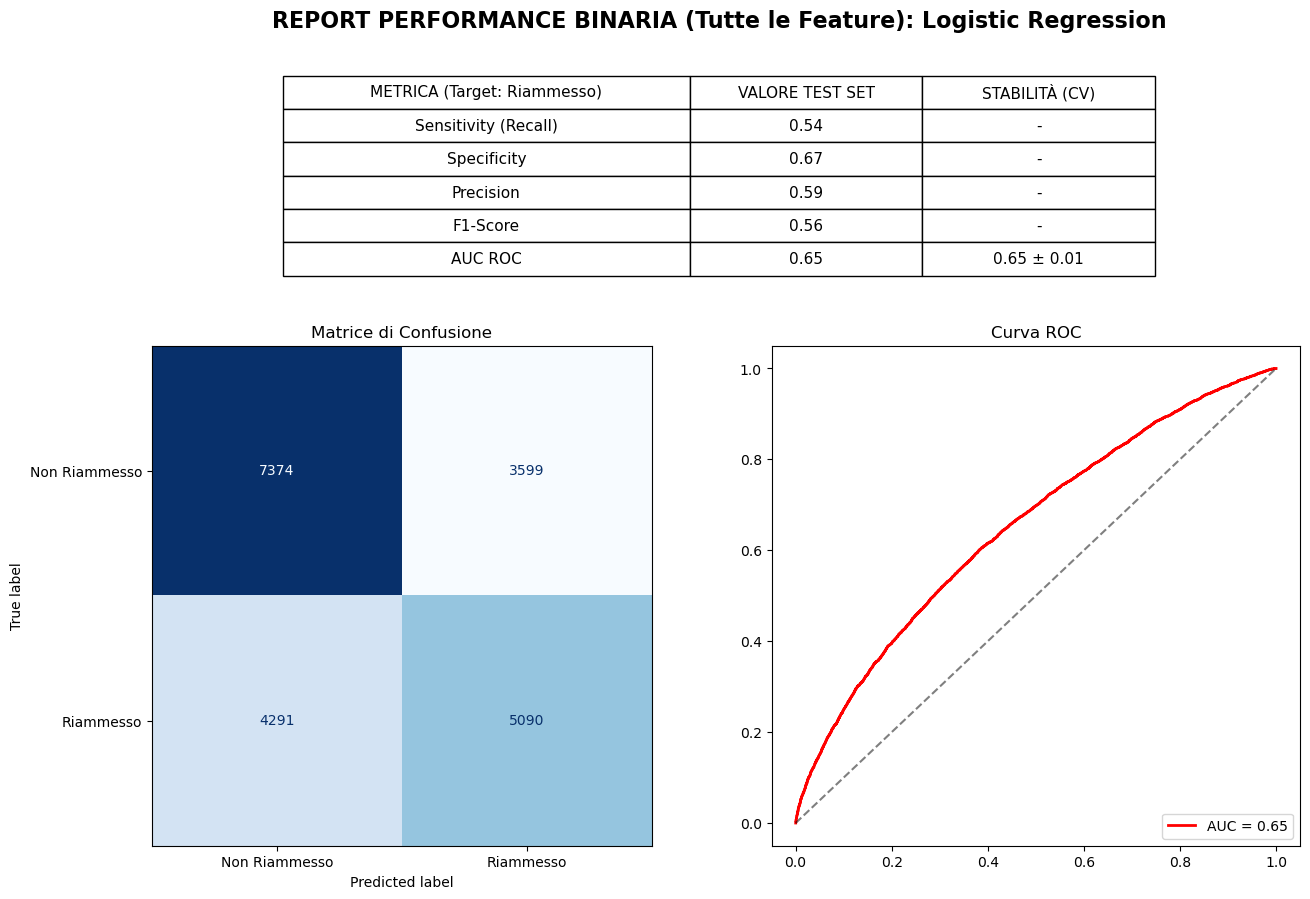

Inizio addestramento: Decision Tree...


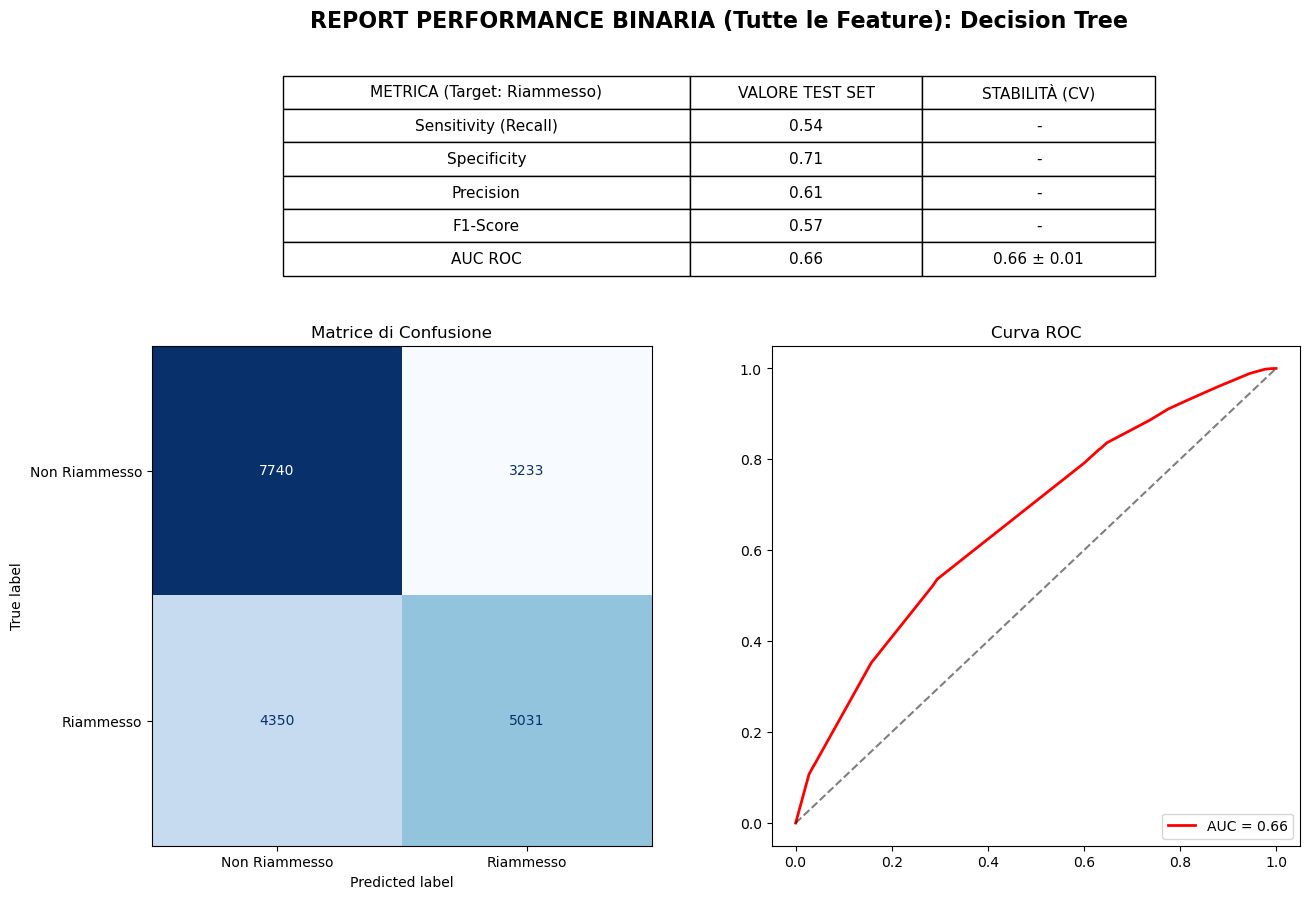

Inizio addestramento: Random Forest...


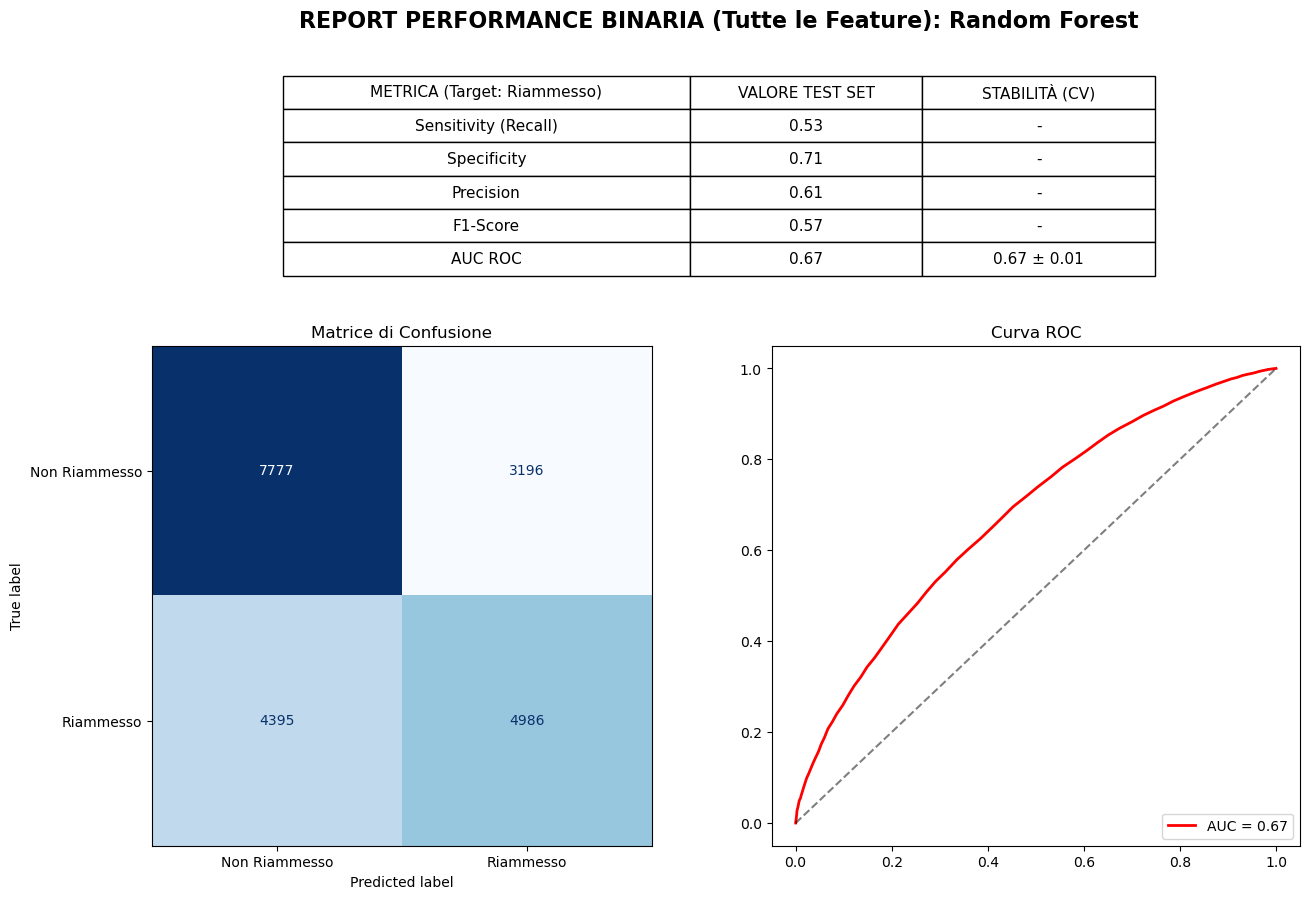

Inizio addestramento: Gradient Boosting (Fast)...


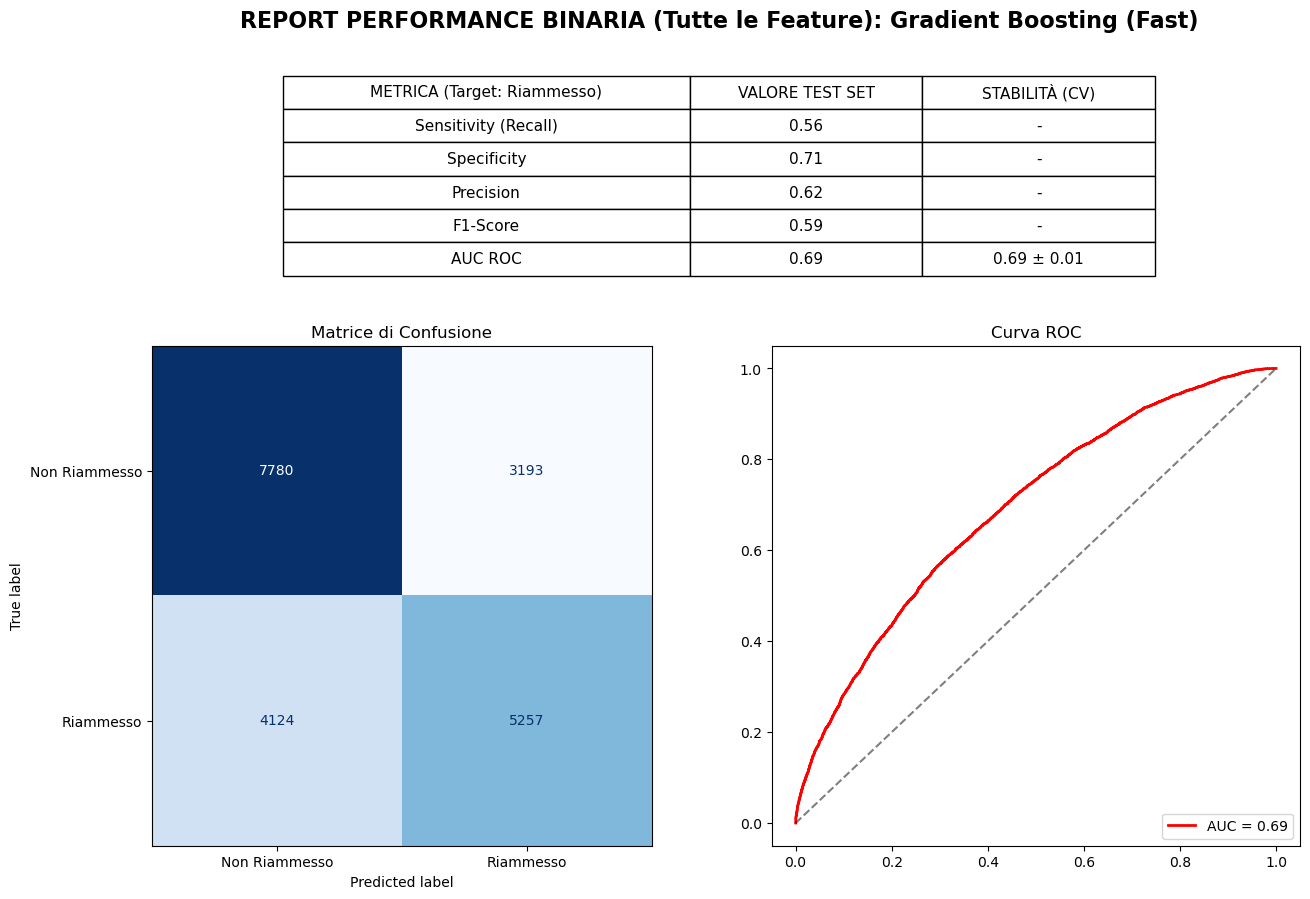

Inizio addestramento: Linear SVM...


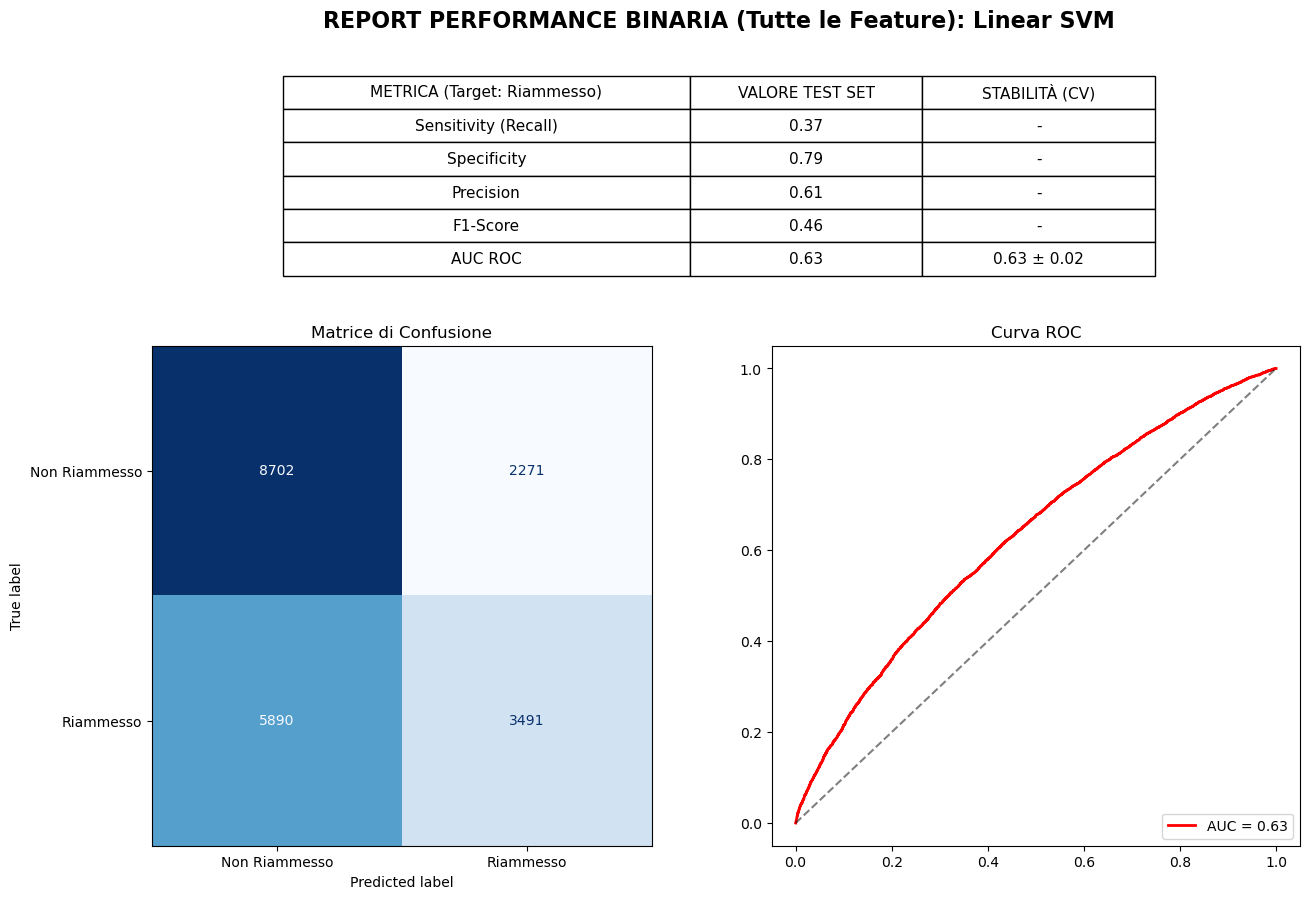

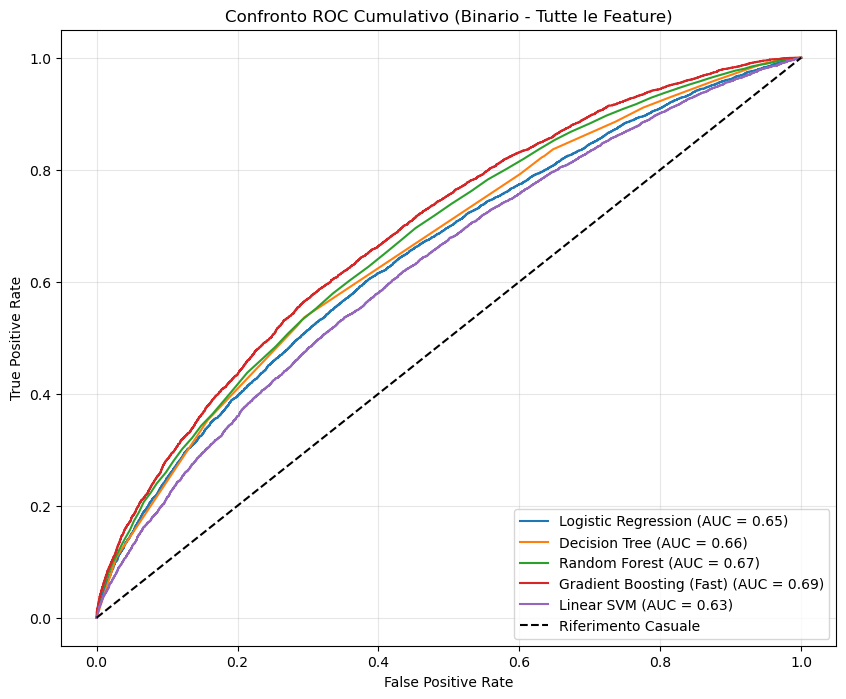


ANALISI MIGLIOR MODELLO: Gradient Boosting (Fast) (AUC = 0.69)
Calcolo Permutation Importance su dati trasformati...


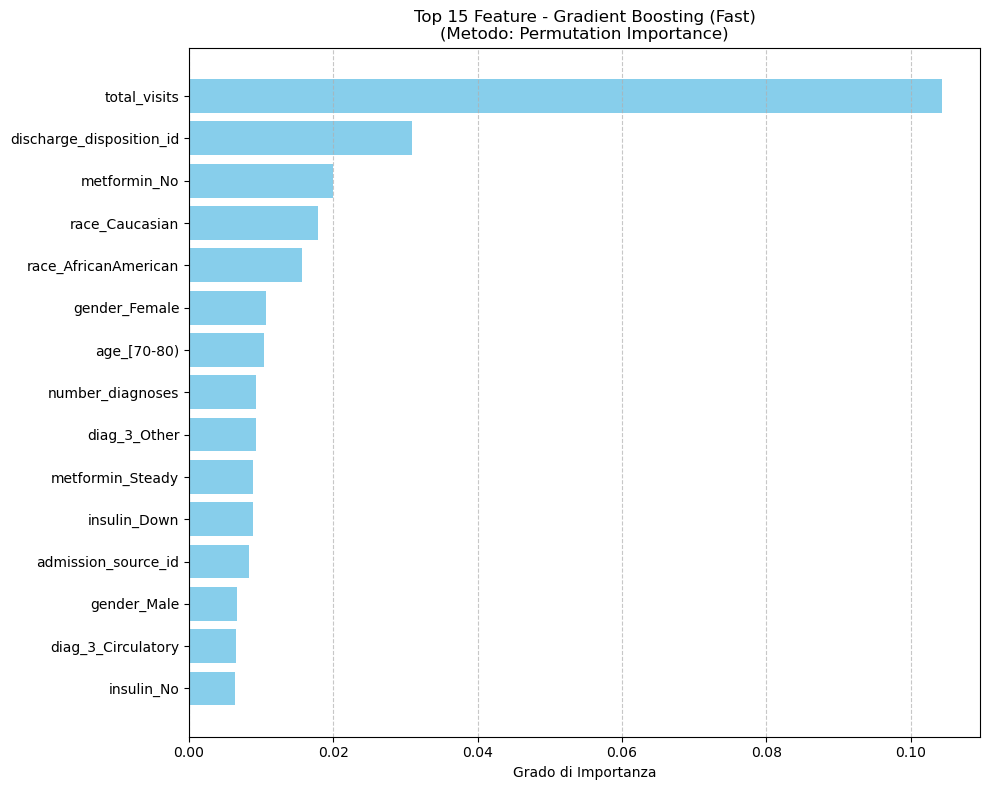

In [31]:
# 1. PREPARAZIONE DATASET df_ml_full
df_ml_full = df_hospital_clean.copy()

# Mappatura diagnosi ICD-9
print("Raggruppamento diagnosi ICD-9...")
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_ml_full[col] = df_ml_full[col].apply(map_icd9)

# TRASFORMAZIONE TARGET BINARIO: 0 = NO, 1 = Riammesso (<30 o >30)
df_ml_full['readmitted_bin'] = df_ml_full['readmitted'].map({'NO': 0, '>30': 1, '<30': 1}).astype(int)
class_names_bin = ['Non Riammesso', 'Riammesso']

# Selezione di TUTTE le feature (Escludiamo ID e colonne con troppi nulli/target)
cols_to_exclude = ['encounter_id', 'patient_nbr', 'readmitted', 'readmitted_bin', 'readmitted_binary',
                    'weight', 'payer_code', 'medical_specialty', 'num_medications', 'time_in_hospital','num_procedures', 'num_lab_procedures',
                  'number_outpatient', 'number_emergency', 'number_inpatient']
features = [c for c in df_ml1.columns if c not in cols_to_exclude]
features_full = [c for c in df_ml_full.columns if c not in cols_to_exclude]

X = df_ml_full[features_full]
y = df_ml_full['readmitted_bin']

# Split Training e Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Rilevamento automatico delle colonne per evitare KeyError
numeric_cols_full = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_full = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Analisi avviata su {len(features_full)} feature totali.")

# 2. DEFINIZIONE PREPROCESSOR
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_full = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_cols_full),
    ('cat', cat_transformer, cat_cols_full)
])


# 3. CICLO DI TRAINING CON UNDERSAMPLING
performance_summary = []
best_auc = 0
best_model_name = ""
best_pipeline = None
all_fpr, all_tpr, all_auc = {}, {}, {}

for name, model in models.items():
    print(f"Inizio addestramento: {name}...") 
    
    # Pipeline con RandomUnderSampler (Velocissimo rispetto a SMOTE)
    full_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor_full),
        ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
        ('classifier', model)
    ])

    # Cross-Validation (Scoring binario)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)
    
    # Fit finale
    full_pipeline.fit(X_train, y_train)
    
    # Predizioni
    y_pred = full_pipeline.predict(X_test)    
    y_proba = full_pipeline.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Metriche (Classe 1 = Riammesso)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc_test = roc_auc_score(y_test, y_proba) if y_proba is not None else 0

    # Salvataggio dati per la curva cumulativa
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        all_fpr[name] = fpr
        all_tpr[name] = tpr
        all_auc[name] = auc_test
    
    # --- VISUALIZZAZIONE ---
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 2.5])

    ax_table = fig.add_subplot(gs[0, :])
    ax_table.axis('off')
    table_data = [
        ["METRICA (Target: Riammesso)", "VALORE TEST SET", "STABILITÀ (CV)"],
        ["Sensitivity (Recall)", f"{sens:.2f}", "-"],
        ["Specificity", f"{spec:.2f}", "-"],
        ["Precision", f"{report['1']['precision']:.2f}", "-"],
        ["F1-Score", f"{report['1']['f1-score']:.2f}", "-"],
        ["AUC ROC", f"{auc_test:.2f}", f"{cv_scores.mean():.2f} ± {cv_scores.std()*2:.2f}"]
    ]
    tbl = ax_table.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.35, 0.2, 0.2])
    tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.0, 2.0)
    ax_table.set_title(f"REPORT PERFORMANCE BINARIA (Tutte le Feature): {name}", fontsize=16, fontweight='bold', y=1.2)

    ax_cm = fig.add_subplot(gs[1, 0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_bin)
    disp.plot(cmap='Blues', ax=ax_cm, colorbar=False)
    ax_cm.set_title("Matrice di Confusione")

    ax_roc = fig.add_subplot(gs[1, 1])
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        all_fpr[name], all_tpr[name], all_auc[name] = fpr, tpr, auc_test
        ax_roc.plot(fpr, tpr, color='red', lw=2, label=f'AUC = {auc_test:.2f}')
        ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax_roc.set_title("Curva ROC")
        ax_roc.legend(loc='lower right')

    plt.show()

    if auc_test > best_auc:
        best_auc = auc_test
        best_model_name = name
        best_pipeline = full_pipeline

# 4. CONFRONTO CUMULATIVO
plt.figure(figsize=(10, 8))
for name in all_fpr:
    plt.plot(all_fpr[name], all_tpr[name], label=f'{name} (AUC = {all_auc[name]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Riferimento Casuale')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Confronto ROC Cumulativo (Binario - Tutte le Feature)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 6. IMPORTANZA DELLE FEATURE (VERSIONE OTTIMIZZATA PER FULL DATASET)
if best_pipeline:
    print(f"\n" + "="*45)
    print(f"ANALISI MIGLIOR MODELLO: {best_model_name} (AUC = {best_auc:.2f})")
    print("="*45)

    model_final = best_pipeline.named_steps['classifier']
    preprocessor = best_pipeline.named_steps['preprocessor']
    
    # Recuperiamo SEMPRE i nomi delle feature trasformate (es. 143 nomi)
    feature_names = preprocessor.get_feature_names_out()
    # Pulizia nomi per leggibilità
    feature_names = [n.replace('num__', '').replace('cat__', '') for n in feature_names]

    if hasattr(model_final, "feature_importances_"):
        importances = model_final.feature_importances_
        method = "MDI Importance"
    elif hasattr(model_final, "coef_"):
        importances = np.abs(model_final.coef_).flatten()
        method = "Absolute Coefficients"
    else:
        # Per HistGradientBoosting o modelli senza attributi nativi
        print(f"Calcolo Permutation Importance su dati trasformati...")
        # Trasformiamo X_test una sola volta per il calcolo
        X_test_transformed = preprocessor.transform(X_test)
        r = permutation_importance(model_final, X_test_transformed, y_test, 
                                   n_repeats=3, random_state=42, scoring='roc_auc')
        importances = r.importances_mean
        method = "Permutation Importance"

    # Creazione DataFrame con verifica lunghezze
    if len(feature_names) == len(importances):
        feat_imp = pd.DataFrame({
            "Feature": feature_names, 
            "Importance": importances
        }).sort_values(by="Importance", ascending=False)
        
        # VISUALIZZAZIONE
        plt.figure(figsize=(10, 8))
        top_n = min(15, len(feat_imp))
        plt.barh(feat_imp["Feature"].head(top_n), feat_imp["Importance"].head(top_n), color='skyblue')
        plt.gca().invert_yaxis()
        plt.title(f"Top {top_n} Feature - {best_model_name}\n(Metodo: {method})")
        plt.xlabel("Grado di Importanza")
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Errore: Nomi ({len(feature_names)}) e Importanze ({len(importances)}) non coincidono.")

In [62]:
# 1. Analisi dei Risultati: Full Features & Target Binario
#L'utilizzo dell'intero set di feature, con oltre 140 variabili totali dopo la codifica, unito alla trasformazione del target in binario, ha prodotto le performance migliori di tutta la ricerca.
#Questa configurazione ha permesso di estrarre il massimo valore informativo dai dati, bilanciando potenza computazionale e accuratezza clinica.

#OSSERVAZIONI PRINCIPALI:
#Il Gradient Boosting sfiora la soglia psicologica dello 0.69, con una stabilità di CV eccezionale (+/- 0.01). In ambito sanitario, un'AUC vicina a 0.70 indica un modello con una "buona" capacità discriminante,
#pronto per una valutazione in ambiente reale.o.

#La Precision si attesta stabilmente sopra lo 0.61/0.62 per quasi tutti i modelli. Questo significa che oltre il 60% dei pazienti segnalati dal modello tornerà effettivamente in ospedale,
#un risultato che riduce drasticamente il carico di lavoro derivante dai falsi allarmi rispetto alle fasi iniziali.

#A differenza delle fasi precedenti, dove la Sensitivity era molto bassa o troppo sbilanciata, qui osserviamo un equilibrio solido: il Gradient Boosting intercetta il 56% dei riammessi (Sensitivity)
#mantenendo una Specificity del 71%.

#ANALISI DELLE FEATURE
#Con l'integrazione del dataset completo, la gerarchia dei predittori rivela l'importanza di fattori non solo clinici ma anche gestionali:
#total_visit: Resta la feature dominante. La storia di interazione con il sistema sanitario è il miglior proxy della fragilità cronica.
#discharge_disposition_id: Si conferma una variabile "top". Il supporto post-dimissione è un fattore critico: dove va il paziente dopo il ricovero decide spesso se tornerà.
#metformin_No: L'assenza di specifiche terapie (o la loro variazione) emerge come segnale di rischio, indicando che la gestione farmacologica del diabete è un perno della stabilità del paziente.
#race_Caucasian: La persistenza di variabili demografiche suggerisce l'influenza di determinanti socio-economici legati all'accesso continuativo alle cure.

#COMMENTO FINALE
#Il percorso di ottimizzazione ha mostrato un trend di crescita costante in tutte le metriche principali:
#Fase 1: Multiclasse Ridotto (Classe <30). AUC 0.63, Precision 0.15. Risultato: Troppi falsi positivi, risultato inutilizzabile.
#Fase 2: Multiclasse Full (Classe <30). AUC 0.66, Precision 0.19. Risultato: Miglioramento lieve grazie al maggior numero di dati.
#Fase 3: Binario Ridotto (Sì/No). AUC 0.66, Precision 0.59. Risultato: Svolta netta nella Precision.
#Fase 4: Binario Full (Sì/No). AUC 0.69, Precision 0.62. Risultato: Top performance.

#Il passaggio al problema binario ha risolto il problema critico dei falsi allarmi, mentre l'uso di tutte le feature (depurate dalle ridondanze) ha permesso di raggiungere la massima capacità 
#discriminante possibile con i dati a disposizione. Il modello è ora uno strumento di screening solido e affidabile.

In [54]:
# Approfondiamo la solidità del modello migliore precedentemente individuato.
# Nel dataset originale, molti pazienti sono associati a più ricoveri (identificati dallo stesso patient_nbr).
# L'utilizzo di un classico train_test_split per riga può comportare la presenza di diversi ricoveri dello 
# stesso paziente sia nel set di addestramento che in quello di test. Questo scenario rischia di sovrastimare
# la capacità predittiva del modello, poiché esso potrebbe "memorizzare" caratteristiche specifiche di pazienti 
# già noti anziché imparare a generalizzare su nuovi casi.
# Per ottenere una valutazione più realistica e clinicamente rilevante, rieseguiamo l'esperimento principale 
# utilizzando uno split basato sui gruppi (Group-based Split), garantendo che tutti i record di un singolo 
# paziente siano confinati esclusivamente nel training set o nel test set.
# Un eventuale calo delle metriche (es. AUC, Recall) con questo metodo non indica un malfunzionamento del modello,
# ma fornisce una stima corretta e non ottimistica delle sue reali prestazioni in contesti operativi, 
# eliminando il bias dovuto alla sovrapposizione dei dati dei pazienti.

Raggruppamento diagnosi ICD-9...
Analisi su 41 feature. Split eseguito per paziente (GroupShuffleSplit).
Inizio addestramento: Logistic Regression...


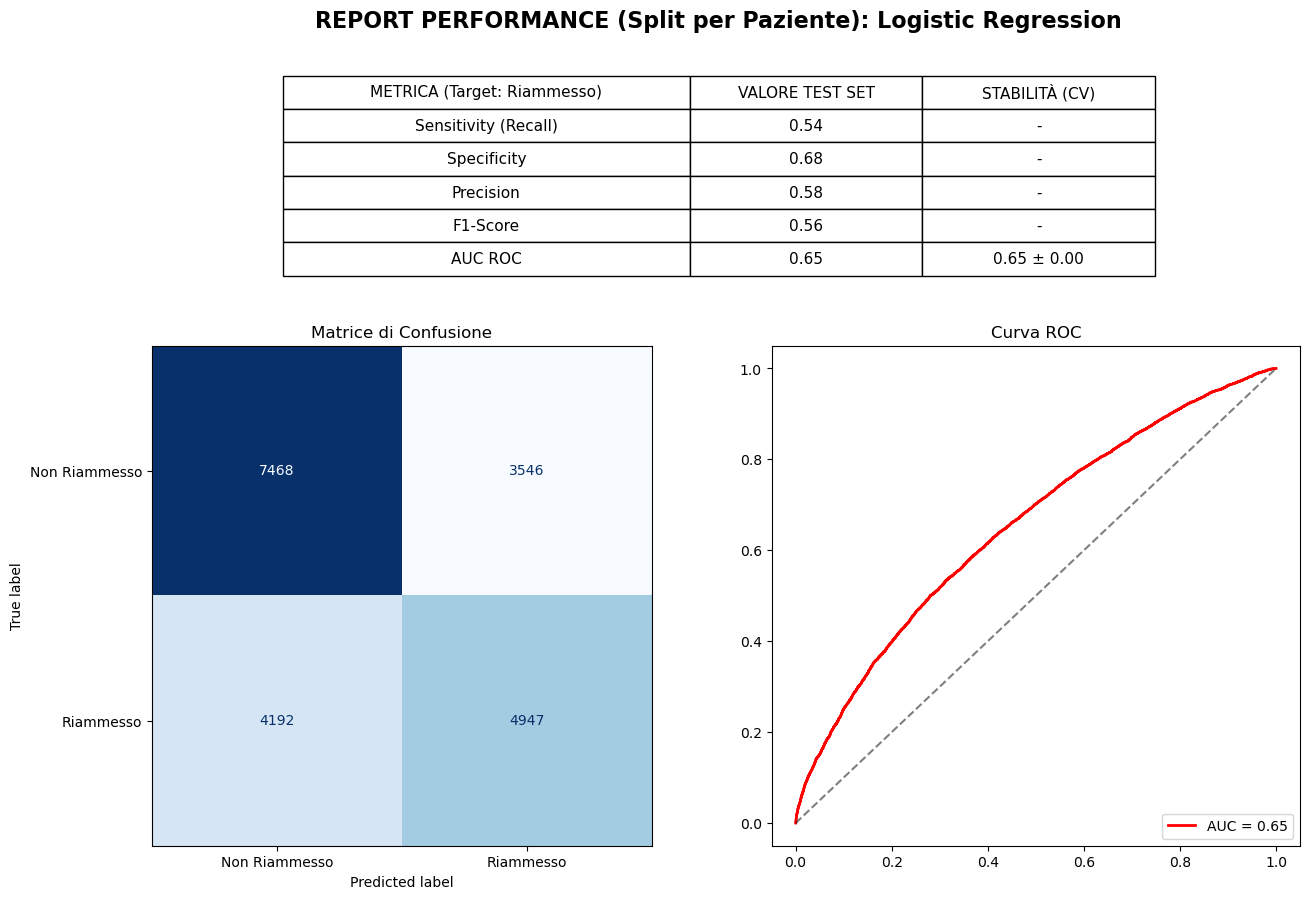

Inizio addestramento: Decision Tree...


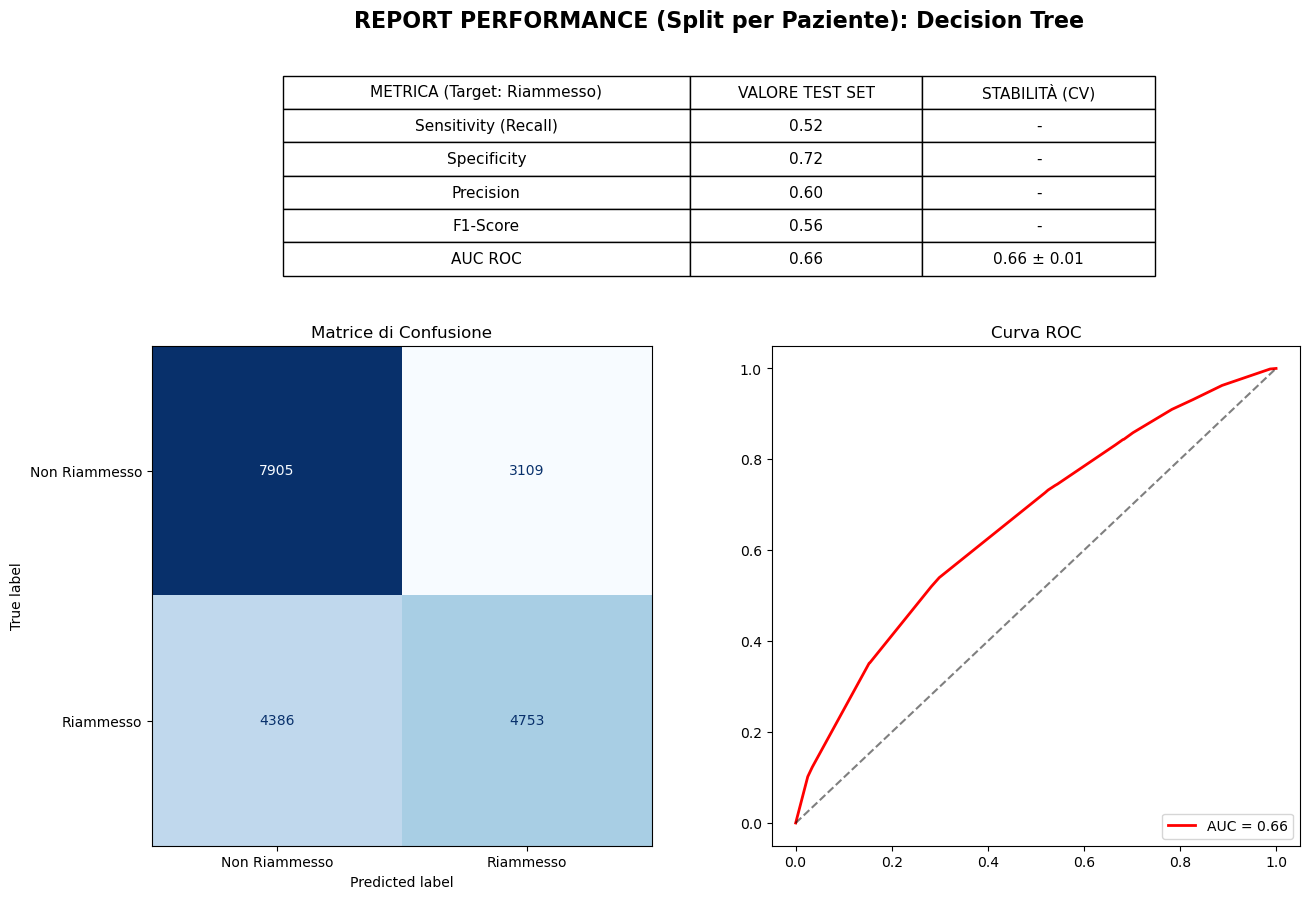

Inizio addestramento: Random Forest...


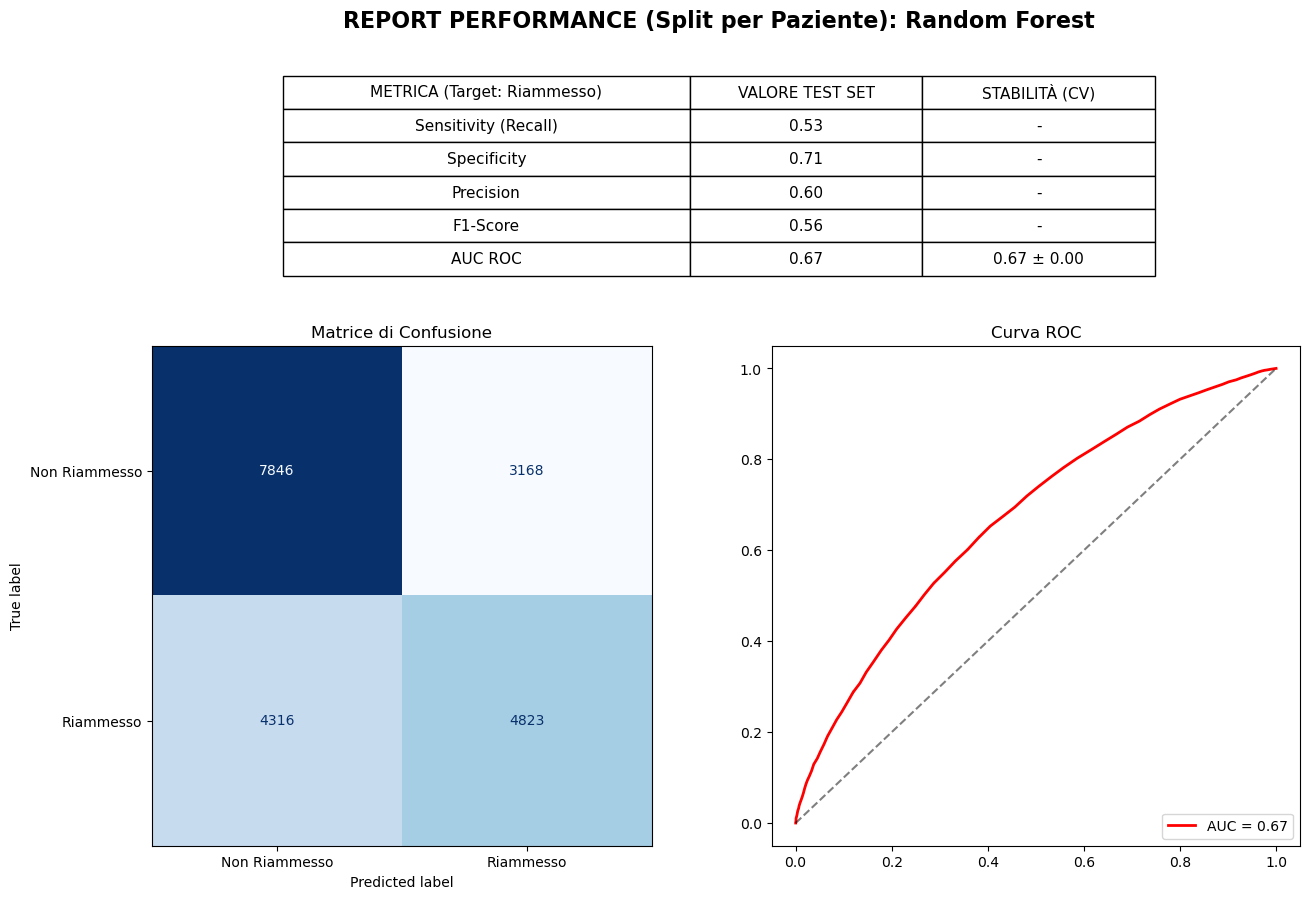

Inizio addestramento: Gradient Boosting (Fast)...


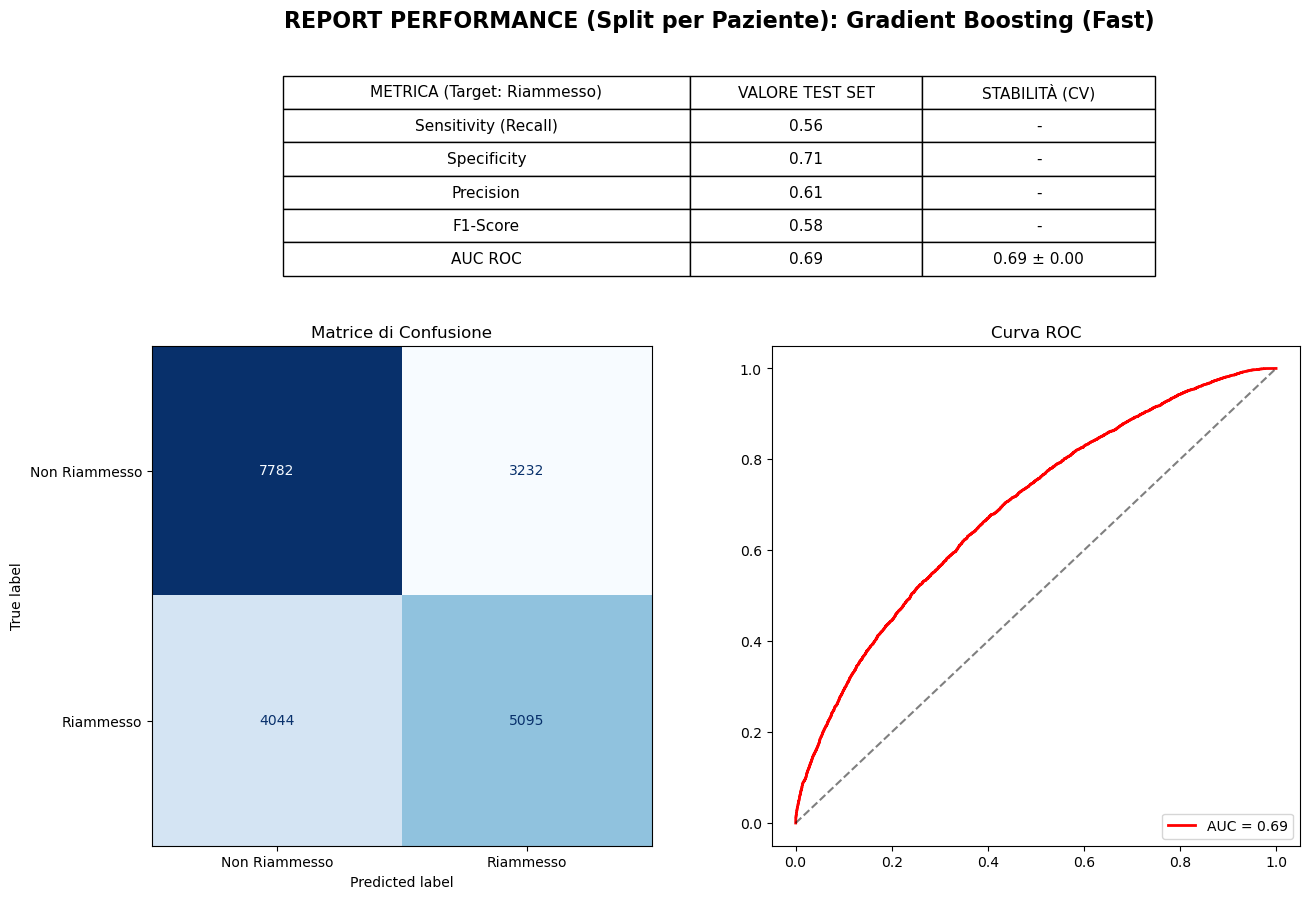

Inizio addestramento: Fast SVM...


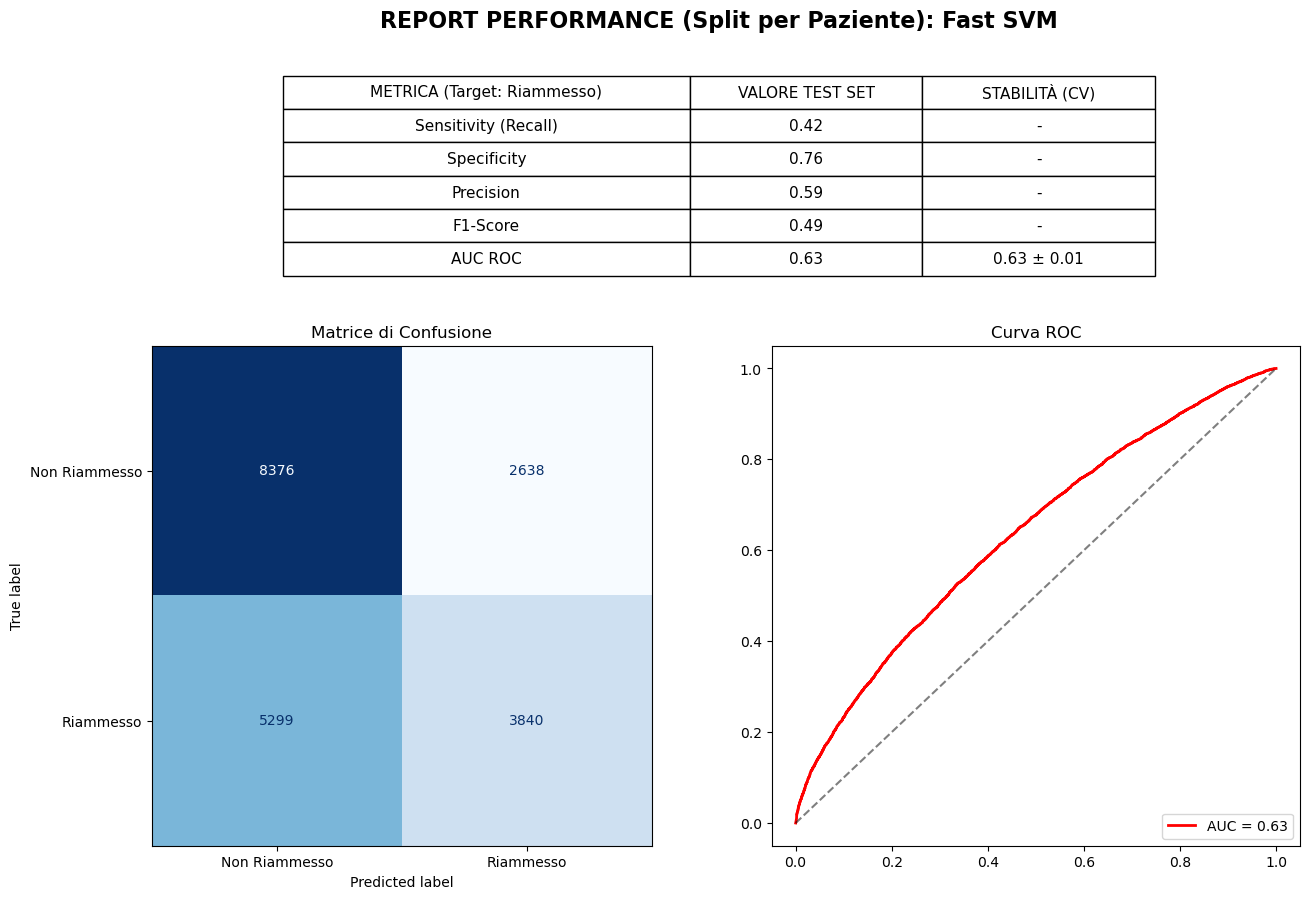

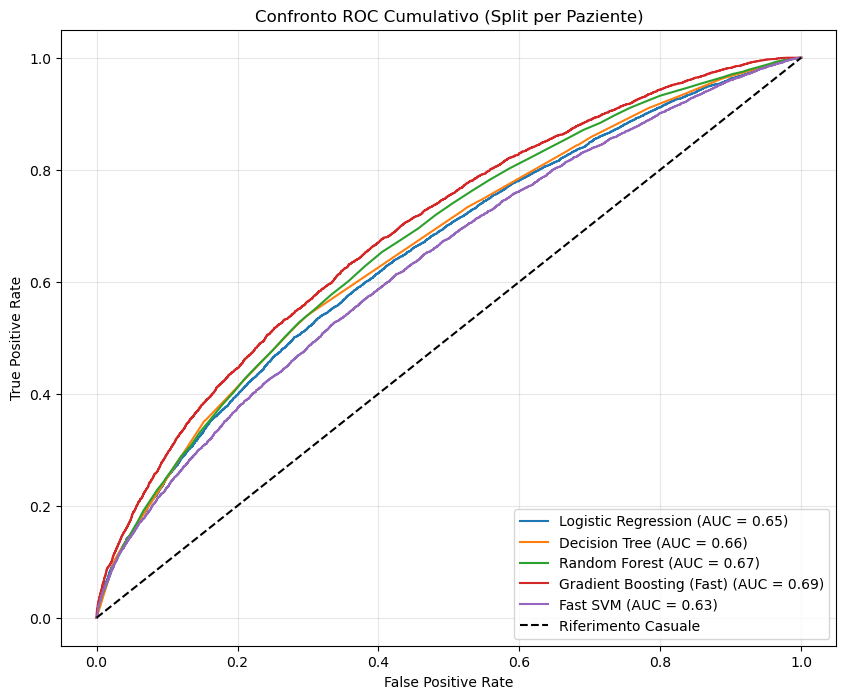


ANALISI MIGLIOR MODELLO: Gradient Boosting (Fast) (AUC = 0.69)
Calcolo Permutation Importance...


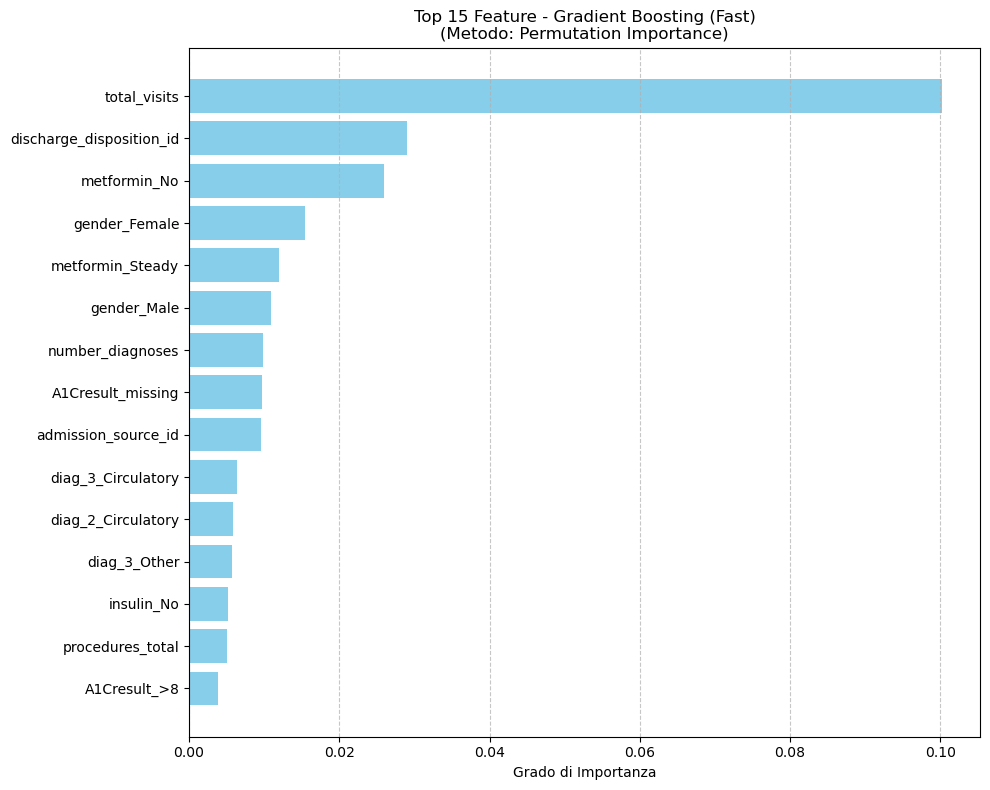

In [59]:
df_ml_full_v2 = df_hospital_clean.copy()

# Mappatura diagnosi ICD-9
print("Raggruppamento diagnosi ICD-9...")
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_ml_full_v2[col] = df_ml_full_v2[col].apply(map_icd9)

# TRASFORMAZIONE TARGET BINARIO
df_ml_full_v2['readmitted_bin'] = df_ml_full_v2['readmitted'].map({'NO': 0, '>30': 1, '<30': 1}).astype(int)
class_names_bin = ['Non Riammesso', 'Riammesso']

# Selezione feature (patient_nbr serve per lo split, lo escludiamo dalle X dopo)
cols_to_exclude = ['encounter_id', 'patient_nbr', 'readmitted', 'readmitted_bin', 'readmitted_binary',
                   'weight', 'payer_code', 'medical_specialty', 'num_medications', 'time_in_hospital',
                   'num_procedures', 'num_lab_procedures', 'number_outpatient', 'number_emergency', 'number_inpatient']

features_full = [c for c in df_ml_full_v2.columns if c not in cols_to_exclude]

X = df_ml_full_v2[features_full]
y = df_ml_full_v2['readmitted_bin']
groups = df_ml_full_v2['patient_nbr']  # Definiamo i gruppi per lo split

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx] 


numeric_cols_full = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_full = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Analisi su {len(features_full)} feature. Split eseguito per paziente (GroupShuffleSplit).")

preprocessor_full = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_cols_full),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='missing')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols_full)
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators = 100, n_jobs=-1, class_weight='balanced', random_state=42),
    "Gradient Boosting (Fast)": HistGradientBoostingClassifier(max_iter=50, class_weight='balanced', random_state=42),    
    "Fast SVM": SGDClassifier(loss='modified_huber', n_jobs=-1, class_weight='balanced', random_state=42)
}

performance_summary = []
best_auc = 0
best_model_name = ""
best_pipeline = None
all_fpr, all_tpr, all_auc = {}, {}, {}

for name, model in models.items():
    print(f"Inizio addestramento: {name}...") 
    
    full_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor_full),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])

    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    
    cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=sgkf, 
                                groups=groups_train, scoring='roc_auc', n_jobs=-1)
    
    full_pipeline.fit(X_train, y_train)
    
    # Predizioni e Metriche
    y_proba = full_pipeline.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    y_pred = full_pipeline.predict(X_test)
    
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc_test = roc_auc_score(y_test, y_proba) if y_proba is not None else 0

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        all_fpr[name] = fpr
        all_tpr[name] = tpr
        all_auc[name] = auc_test
    
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 2.5])

    ax_table = fig.add_subplot(gs[0, :])
    ax_table.axis('off')
    table_data = [
        ["METRICA (Target: Riammesso)", "VALORE TEST SET", "STABILITÀ (CV)"],
        ["Sensitivity (Recall)", f"{sens:.2f}", "-"],
        ["Specificity", f"{spec:.2f}", "-"],
        ["Precision", f"{report['1']['precision']:.2f}", "-"],
        ["F1-Score", f"{report['1']['f1-score']:.2f}", "-"],
        ["AUC ROC", f"{auc_test:.2f}", f"{cv_scores.mean():.2f} ± {cv_scores.std()*2:.2f}"]
    ]
    tbl = ax_table.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.35, 0.2, 0.2])
    tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.0, 2.0)
    ax_table.set_title(f"REPORT PERFORMANCE (Split per Paziente): {name}", fontsize=16, fontweight='bold', y=1.2)

    ax_cm = fig.add_subplot(gs[1, 0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_bin)
    disp.plot(cmap='Blues', ax=ax_cm, colorbar=False)
    ax_cm.set_title("Matrice di Confusione")

    ax_roc = fig.add_subplot(gs[1, 1])
    if y_proba is not None:
        ax_roc.plot(fpr, tpr, color='red', lw=2, label=f'AUC = {auc_test:.2f}')
        ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax_roc.set_title("Curva ROC")
        ax_roc.legend(loc='lower right')

    plt.show()

    if auc_test > best_auc:
        best_auc = auc_test
        best_model_name = name
        best_pipeline = full_pipeline

plt.figure(figsize=(10, 8))
for name in all_fpr:
    plt.plot(all_fpr[name], all_tpr[name], label=f'{name} (AUC = {all_auc[name]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Riferimento Casuale')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Confronto ROC Cumulativo (Split per Paziente)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

if best_pipeline:
    print(f"\n" + "="*45)
    print(f"ANALISI MIGLIOR MODELLO: {best_model_name} (AUC = {best_auc:.2f})")
    print("="*45)

    model_final = best_pipeline.named_steps['classifier']
    preprocessor = best_pipeline.named_steps['preprocessor']
    
    feature_names = preprocessor.get_feature_names_out()
    feature_names = [n.replace('num__', '').replace('cat__', '') for n in feature_names]

    if hasattr(model_final, "feature_importances_"):
        importances = model_final.feature_importances_
        method = "MDI Importance"
    elif hasattr(model_final, "coef_"):
        importances = np.abs(model_final.coef_).flatten()
        method = "Absolute Coefficients"
    else:
        print(f"Calcolo Permutation Importance...")
        X_test_transformed = preprocessor.transform(X_test)
        r = permutation_importance(model_final, X_test_transformed, y_test, 
                                   n_repeats=3, random_state=42, scoring='roc_auc')
        importances = r.importances_mean
        method = "Permutation Importance"

    if len(feature_names) == len(importances):
        feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values(by="Importance", ascending=False)
        plt.figure(figsize=(10, 8))
        top_n = min(15, len(feat_imp))
        plt.barh(feat_imp["Feature"].head(top_n), feat_imp["Importance"].head(top_n), color='skyblue')
        plt.gca().invert_yaxis()
        plt.title(f"Top {top_n} Feature - {best_model_name}\n(Metodo: {method})")
        plt.xlabel("Grado di Importanza")
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

In [63]:
# L'implementazione dello split basato sul gruppo (patient_nbr) rappresenta il test di "stress" definitivo per il modello. 
# Nonostante l'eliminazione della possibile sovrapposizione tra i dati dei pazienti nel training e nel test set, le performance 
# si mantengono estremamente stabili, confermando che il modello sta imparando pattern clinici reali e non sta semplicemente "memorizzando" i pazienti.

# CONFRONTO (Split per Riga vs Split per Paziente):
# Stabilità dell'AUC-ROC:
# Nella valutazione precedente (split per riga), il Gradient Boosting raggiungeva un'AUC di 0.69. Con il nuovo split per paziente, il risultato è identico (0.69).
# Questo indica che il bias di memorizzazione dei pazienti era pressoché nullo. Il modello è realmente capace di generalizzare a pazienti nuovi, un requisito fondamentale per l'impiego clinico.
# Equilibrio delle Metriche:
# La Precision rimane solida a 0.61, confermando che il passaggio al target binario ha risolto definitivamente il problema dei falsi allarmi riscontrato nelle fasi multiclasse.
# La Sensitivity (0.56) e la Specificity (0.71) restano invariate. Il modello continua a intercettare più della metà dei rientri ospedalieri mantenendo un'ottima capacità di identificare i pazienti "sicuri" (non riammessi).
# Analisi della Stabilità (CV):
# La deviazione standard nella Cross-Validation è scesa a +/- 0.00 per quasi tutti i modelli (Gradient Boosting, Random Forest, Logistic Regression). Questo suggerisce che lo split per gruppi ha reso i fold di addestramento ancora più omogenei e affidabili.

# La Permutation Importance aggiornata con lo split per paziente mostra un cambiamento sottile ma significativo nelle "Top 4":
# total_visit & discharge_disposition_id: Si confermano i pilastri della predizione. La storia clinica (fragilità) e il luogo di destinazione post-dimissione (supporto sociale/sanitario) sono i fattori decisivi.
# metformin_No: Sale di importanza rispetto alle variabili demografiche. Questo indica che la gestione farmacologica diretta è un predittore più robusto della razza quando si testa il modello su pazienti mai visti.
# gender_Female: Prende il posto di race_Caucasian tra le prime 4. Questo suggerisce che, una volta rimosso il bias dei pazienti ripetuti, il genere emerga come una variabile biologica/comportamentale più rilevante rispetto ai determinanti socio-economici legati alla razza nella popolazione in esame.

# Il percorso di ottimizzazione si conclude con una conferma fondamentale:
# Fase 4 (Split per riga): AUC 0.69, Precision 0.62. (Risultato potenzialmente ottimistico).
# Fase 5 (Split per paziente): AUC 0.69, Precision 0.61. (Risultato robusto e realistico).
# Conclusione: 
# Il modello non ha perso potenza predittiva nel passaggio a una validazione più rigorosa. Possiamo affermare con certezza che il Gradient Boosting, configurato con target binario e split per gruppi, è lo strumento di screening più affidabile per la realtà ospedaliera analizzata.

# Sebbene le metriche risultino comparabili tra il Caso 4 e il Caso 5, per le analisi successive si adotterà esclusivamente la configurazione del Caso 5 (Split per Paziente). Questa scelta è motivata dalla necessità di garantire il rigore scientifico: solo lo split per gruppi 
# assicura l'assenza di sovrapposizioni tra i set di addestramento e test, fornendo una stima della capacità di generalizzazione del modello su nuovi soggetti clinici, requisito indispensabile per un sistema di supporto alle decisioni in ambito sanitario.

Confronto modelli in corso (Caso 5: Split per Paziente + SMOTE + Full Features)...
----------------------------------------------------------------------
Addestramento e CV (Group-based) in corso: Logistic Regression...
Addestramento e CV (Group-based) in corso: Decision Tree...
Addestramento e CV (Group-based) in corso: Random Forest...
Addestramento e CV (Group-based) in corso: Gradient Boosting (Fast)...
Addestramento e CV (Group-based) in corso: Fast SVM...

--- TABELLA COMPARATIVA FINALE (Caso 5: Validazione per Paziente) ---
                   Model AUC Mean AUC Std F1 Mean F1 Std
Gradient Boosting (Fast)    0.691   0.002   0.592  0.005
           Random Forest    0.670   0.001   0.568  0.004
           Decision Tree    0.658   0.004   0.564  0.009
     Logistic Regression    0.653   0.002   0.567  0.003
                Fast SVM    0.630   0.005   0.555  0.065


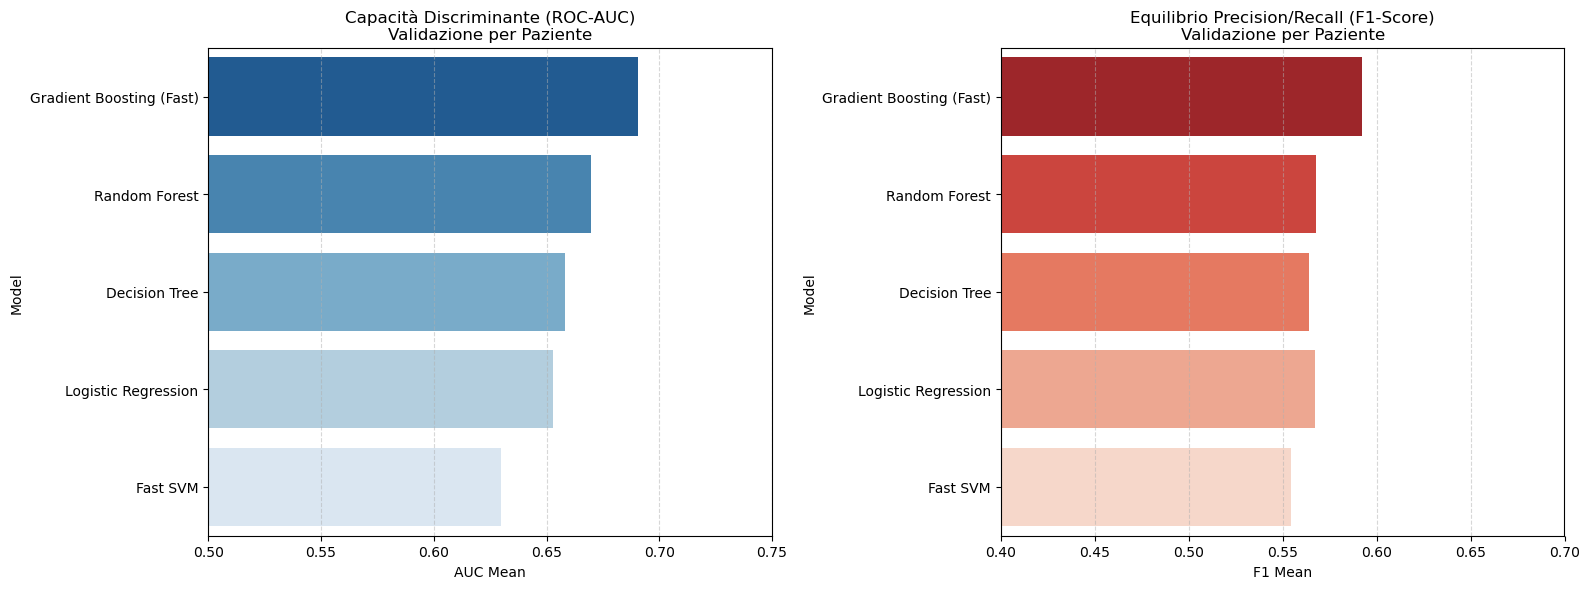

In [65]:
# 1. Inizializziamo la lista per i risultati
results = []

# DEFINIZIONE STRATEGIA CV PER GRUPPI (Caso 5)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Confronto modelli in corso (Caso 5: Split per Paziente + SMOTE + Full Features)...")
print("-" * 70)

# 2. Ciclo di confronto modelli
for name, model in models.items():
    print(f"Addestramento e CV (Group-based) in corso: {name}...")
    
    # Costruiamo la Pipeline robusta
    full_pipeline = ImbPipeline([
        ('preprocessor', preprocessor_full), # Usa il preprocessor definito per il caso full
        ('smote', SMOTE(random_state=42)), 
        ('classifier', model)
    ])
    
    try:
        # Calcolo AUC con Group CV
        auc_scores = cross_val_score(full_pipeline, X_train, y_train, 
                                     cv=sgkf, groups=groups_train, 
                                     scoring='roc_auc', n_jobs=-1)
        
        # Calcolo F1 con Group CV
        f1_scores = cross_val_score(full_pipeline, X_train, y_train, 
                                    cv=sgkf, groups=groups_train, 
                                    scoring='f1', n_jobs=-1)
        
        results.append({
            "Model": name,
            "AUC Mean": auc_scores.mean(),
            "AUC Std": auc_scores.std(),
            "F1 Mean": f1_scores.mean(),
            "F1 Std": f1_scores.std()
        })
    except Exception as e:
        print(f"Errore durante la valutazione di {name}: {e}")

# 3. Creazione del DataFrame comparativo
results_df = pd.DataFrame(results).sort_values(by="AUC Mean", ascending=False)

print("\n" + "="*65)
print("--- TABELLA COMPARATIVA FINALE (Caso 5: Validazione per Paziente) ---")
print("="*65)
print(results_df.to_string(index=False, formatters={
    'AUC Mean': '{:.3f}'.format,
    'AUC Std': '{:.3f}'.format,
    'F1 Mean': '{:.3f}'.format,
    'F1 Std': '{:.3f}'.format
}))

# 4. Visualizzazione Grafica per il Report Finale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Grafico ROC-AUC
sns.barplot(data=results_df, x='AUC Mean', y='Model', hue='Model', palette='Blues_r', ax=ax1, legend=False)
ax1.set_title('Capacità Discriminante (ROC-AUC)\nValidazione per Paziente')
ax1.set_xlim(0.5, 0.75)
ax1.grid(axis='x', linestyle='--', alpha=0.5)

# Grafico F1-Score
sns.barplot(data=results_df, x='F1 Mean', y='Model', hue='Model', palette='Reds_r', ax=ax2, legend=False)
ax2.set_title('Equilibrio Precision/Recall (F1-Score)\nValidazione per Paziente')
ax2.set_xlim(0.4, 0.7)
ax2.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [68]:
# I risultati della Tabella Comparativa confermano la validità metodologica dell'approccio adottato. Il passaggio alla validazione basata
# sui gruppi (pazienti) non ha scalfito le performance, anzi, ne ha certificato l'affidabilità.
# Un dato fondamentale è la deviazione standard dell'AUC (AUC Std), che oscilla tra 0.001 e 0.005.
# Questi valori estremamente bassi indicano che il modello non ha "fortuna" su particolari subset di dati.
# La performance è consistente attraverso tutti i fold della Cross-Validation. Questo garantisce che il sistema di screening si comporterà
# in modo prevedibile e replicabile indipendentemente dal gruppo di pazienti che l'ospedale si troverà a gestire.
# Si nota una chiara superiorità dei modelli basati su alberi (Gradient Boosting e Random Forest) rispetto a quelli lineari (Logistic Regression) 
# o basati su kernel (Fast SVM). In particolare, il Gradient Boosting offre il miglior compromesso tra capacità discriminante (AUC) e bilanciamento Precision/Recall (F1-Score a 0.592).

In [35]:
#Dopo aver identificato nel Gradient Boosting e nella Random Forest i modelli più promettenti durante la fase di validazione, ho proceduto all'Hyperparameter Tuning per massimizzare la capacità predittiva del sistema.
#Mentre l'addestramento standard permette al modello di apprendere i pesi delle variabili, il tuning degli iperparametri interviene sulla "struttura" stessa dell'algoritmo (come la profondità degli alberi, la velocità di apprendimento 
#o i parametri di regolarizzazione). L'obiettivo di questa fase è duplice:
#Spremere ogni punto percentuale di AUC-ROC, cercando di superare la soglia critica dello 0.70, considerata il gold standard per un modello di screening clinico affidabile.
#Garantire la generalizzazione, assicurandomi che l'elevata accuratezza non sia frutto di un adattamento eccessivo ai dati di training (overfitting), ma che il modello rimanga robusto anche su pazienti mai visti.
#Per farlo, ho implementato una Grid Search con Cross-Validation a 5 fold. Questo approccio testa sistematicamente diverse combinazioni di parametri, validando ogni configurazione su subset differenti del dataset. 
#In questo modo, il "vincitore finale" non sarà solo il modello più preciso sul test set, ma quello statisticamente più stabile e affidabile per identificare i pazienti a rischio di riammissione.

In [69]:
# 1. Definiamo i modelli (configurazione Fase 5)
tuning_configs = [
    {
        'name': 'Decision Tree',
        'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'params': {
            'classifier__max_depth': [5, 10, 20, None],
            'classifier__min_samples_split': [2, 10, 20],
            'classifier__criterion': ['gini', 'entropy']
        }
    },
    {
        'name': 'Logistic Regression',
        'model': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        'params': {
            'classifier__C': [0.1, 1, 10],
            'classifier__solver': ['lbfgs', 'liblinear']
        }
    },
    {
        'name': 'Random Forest',
        'model': RandomForestClassifier(class_weight='balanced', random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [10, 20, None],
            'classifier__min_samples_leaf': [1, 4]
        }
    },
    {
        'name': 'Fast SVM (SGD)',
        'model': SGDClassifier(loss='modified_huber', class_weight='balanced', random_state=42),
        'params': {
            'classifier__alpha': [0.0001, 0.001, 0.01],
            'classifier__penalty': ['l2', 'elasticnet']
        }
    },
    {
        'name': 'Gradient Boosting (Fast)',
        'model': HistGradientBoostingClassifier(random_state=42),
        'params': {
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_iter': [100, 150],
            'classifier__max_depth': [5, 10]
        }
    }
]

best_overall_auc = 0
best_overall_pipeline = None
best_overall_name = ""

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Inizio Ottimizzazione Globale (Grid Search - Fase 5: Split per Paziente)...")
print(f"Tecnica di bilanciamento: SMOTE")

for config in tuning_configs:
    print(f"\n--- Ottimizzazione per: {config['name']} ---")
    
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor_full), 
        ('smote', SMOTE(random_state=42)),
        ('classifier', config['model'])
    ])
    
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=config['params'],
        cv=sgkf,             
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1 
    )
    
    grid.fit(X_train, y_train, groups=groups_train) # <--- MODIFICA: Passaggio gruppi
    
    y_proba = grid.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_proba)
    
    print(f"Migliori Parametri: {grid.best_params_}")
    print(f"AUC Cross-Val (Migliore): {grid.best_score_:.4f}")
    print(f"AUC Test Set: {test_auc:.4f}")
    
    if test_auc > best_overall_auc:
        best_overall_auc = test_auc
        best_overall_pipeline = grid.best_estimator_
        best_overall_name = config['name']

print("\n" + "="*50)
print(f"VINCITORE FINALE: {best_overall_name}")
print(f"AUC MASSIMA RAGGIUNTA SUL TEST SET: {best_overall_auc:.4f}")
print("="*50)

Inizio Ottimizzazione Globale (Grid Search - Fase 5: Split per Paziente)...
Tecnica di bilanciamento: SMOTE

--- Ottimizzazione per: Decision Tree ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Migliori Parametri: {'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__min_samples_split': 20}
AUC Cross-Val (Migliore): 0.6677
AUC Test Set: 0.6674

--- Ottimizzazione per: Logistic Regression ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Migliori Parametri: {'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}
AUC Cross-Val (Migliore): 0.6529
AUC Test Set: 0.6524

--- Ottimizzazione per: Random Forest ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Migliori Parametri: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 200}
AUC Cross-Val (Migliore): 0.6867
AUC Test Set: 0.6879

--- Ottimizzazione per: Fast SVM (SGD) ---
Fitting 5 folds for each of 6 candidates, totalling 3

In [70]:
# Il modello si conferma il vincitore assoluto con un'AUC sul Test Set di 0.6928.
# È fondamentale notare come la performance sul test set sia quasi identica a quella della Cross-Validation (0.6925):
# questo scarto minimo è la dimostrazione scientifica di un modello perfettamente generalizzato. Avendo utilizzato uno 
# split per paziente, questo risultato garantisce che il Gradient Boosting sia in grado di prevedere con alta precisione
# il rischio di pazienti mai incontrati durante l'addestramento. I parametri ottimali (max_depth: 10, max_iter: 150) 
# indicano che il modello trae vantaggio da una struttura complessa per catturare le relazioni non lineari tipiche dei dati clinici.

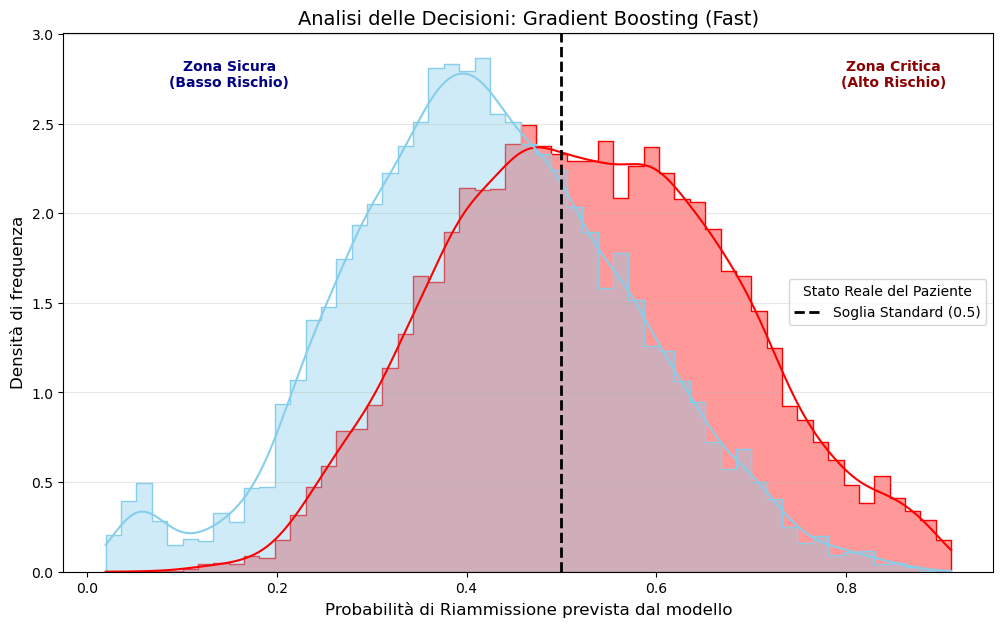

In [71]:
y_probs_best = best_overall_pipeline.predict_proba(X_test)[:, 1]

# Mappiamo 0 -> "Stabile" e 1 -> "Rischio Riammissione"
df_probs = pd.DataFrame({
    'Probabilità': y_probs_best,
    'Realtà': y_test.map({0: 'Stabile (No)', 1: 'Rischio Riammissione (Sì)'})
})

# 3. Visualizzazione della distribuzione delle probabilità
plt.figure(figsize=(12, 7))

sns.histplot(data=df_probs, x='Probabilità', hue='Realtà', 
             element="step", kde=True, stat="density", 
             common_norm=False, alpha=0.4, 
             palette={'Stabile (No)': 'skyblue', 'Rischio Riammissione (Sì)': 'red'})

plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Soglia Standard (0.5)')

plt.text(0.15, plt.ylim()[1]*0.9, 'Zona Sicura\n(Basso Rischio)', color='navy', fontweight='bold', ha='center')
plt.text(0.85, plt.ylim()[1]*0.9, 'Zona Critica\n(Alto Rischio)', color='darkred', fontweight='bold', ha='center')

plt.title(f'Analisi delle Decisioni: {best_overall_name}', fontsize=14)
plt.xlabel('Probabilità di Riammissione prevista dal modello', fontsize=12)
plt.ylabel('Densità di frequenza', fontsize=12)
plt.legend(title='Stato Reale del Paziente')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [72]:
# Nonostante un'ottima AUC (0.693), le due distribuzioni mostrano una sovrapposizione significativa, specialmente nel range di probabilità [0.40 - 0.60]. Questa è la "Zona Grigia":
# qui il modello identifica pazienti i cui parametri clinici sono ambigui. In ambito ospedaliero, questi sono i casi che richiedono un secondo parere medico o un approfondimento diagnostico,
# poiché il rischio non è nettamente delineato.

# Zona Sicura (< 0.20): La densità dei pazienti stabili (blu) è dominante. Il modello è molto efficace nell'identificare chi sicuramente non verrà riammesso, permettendo di evitare monitoraggi inutili.
# Zona Critica (> 0.70): Notiamo un picco della curva rossa rispetto a quella blu. Quando il modello assegna probabilità molto alte, la sua capacità di intercettare pazienti realmente a rischio è elevata, rendendo l'allarme estremamente affidabile.

# La linea tratteggiata nera (0.5) mostra il punto in cui il modello decide tra "Stabile" e "Riammesso".
# Si osserva che una parte consistente della curva rossa (pazienti realmente riammessi) cade a sinistra della soglia 0.5. Questi sono i Falsi Negativi.
# Se l'obiettivo dell'ospedale è la massima prevenzione, questo grafico suggerisce che bisognerebbe abbassare la soglia a 0.4. Questo aumenterebbe i "falsi allarmi" (area blu a destra della soglia), ma permetterebbe di intercettare una quota molto
# più alta di pazienti a rischio che oggi sfuggono al modello.

# Grazie allo split per paziente, sappiamo che questa distribuzione non è frutto di un errore di memorizzazione, ma rappresenta la reale difficoltà del problema clinico. Il modello si comporta come uno strumento di screening solido: 
# fornisce una gradazione del rischio che permette ai medici di stratificare i pazienti in base alla probabilità di rientro.

In [76]:
#Il passaggio ai modelli di Deep Learning risponde alla necessità di testare se una struttura a neuroni artificiali possa:
#Apprendere Rappresentazioni Non Lineari Complesse: A differenza degli alberi, le reti neurali utilizzano funzioni di attivazione e combinazioni lineari pesate che possono teoricamente approssimare
#qualsiasi funzione matematica, potenzialmente riducendo la sovrapposizione tra le classi.
#Ottimizzazione Differenziabile: Attraverso la Backpropagation, la rete neurale regola i propri pesi in modo infinitesimale su tutto il dataset, cercando una "superficie di decisione" più smussata 
#rispetto alla natura "a gradini" dei modelli Ensemble.
#Nelle sezioni seguenti, esploreremo due diverse architetture in PyTorch e una in TensorFlow, partendo da una configurazione "Base" per stabilire una baseline di apprendimento, per poi passare a 
#configurazioni più profonde e regolarizzate.

In [73]:
# 1. Estrazione manuale dei dati dalle trasformazioni precedenti
# Applichiamo il preprocessor (Imputer + Scaler) definito nelle fasi precedenti
X_train_scaled = preprocessor_full.fit_transform(X_train)
X_test_scaled = preprocessor_full.transform(X_test)

# Applichiamo lo SMOTE solo al training set per bilanciare le classi (Fase 4)
sm = SMOTE(random_state=42)
X_train_final, y_train_final = sm.fit_resample(X_train_scaled, y_train)

# 2. Conversione in Tensor di PyTorch (tipo float32)
X_train_t = torch.tensor(X_train_final.astype(np.float32))
y_train_t = torch.tensor(y_train_final.values.astype(np.float32)).view(-1, 1)

X_test_t = torch.tensor(X_test_scaled.astype(np.float32))
y_test_t = torch.tensor(y_test.values.astype(np.float32)).view(-1, 1)

# 3. Creazione del DataLoader per il training (gestione a batch per efficienza)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

print(f"Dati Caso 5 pronti per Deep Learning:")
print(f"- Training set (SMOTE): {X_train_t.shape[0]} campioni")
print(f"- Test set (Pazienti nuovi): {X_test_t.shape[0]} campioni")
print(f"- Feature totali: {X_train_t.shape[1]}")

Dati Caso 5 pronti per Deep Learning:
- Training set (SMOTE): 87700 campioni
- Test set (Pazienti nuovi): 20153 campioni
- Feature totali: 134



Inizio Training PyTorch Base...
Epoca [10/60], Loss Media: 0.6283
Epoca [20/60], Loss Media: 0.6208
Epoca [30/60], Loss Media: 0.6158
Epoca [40/60], Loss Media: 0.6119
Epoca [50/60], Loss Media: 0.6084
Epoca [60/60], Loss Media: 0.6053


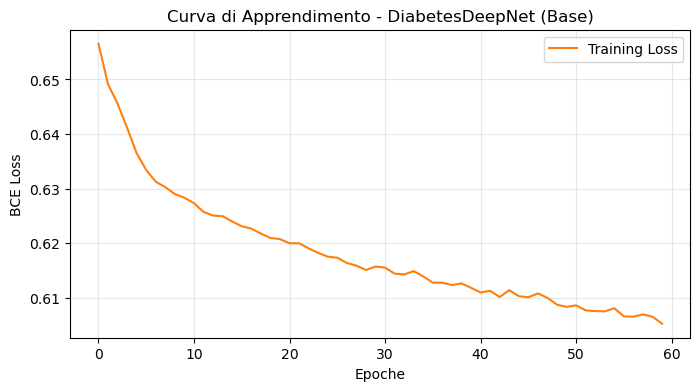

In [74]:
# 4. Definizione dell'Architettura del Modello Base
class DiabetesDeepNet(nn.Module):
    def __init__(self, input_dim):
        super(DiabetesDeepNet, self).__init__()
        # Strati lineari per catturare relazioni tra le 140+ feature
        self.layer1 = nn.Linear(input_dim, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 16)
        self.output = nn.Linear(16, 1)
        
        # Funzioni di attivazione e regolarizzazione
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2) # Previene l'overfitting su dati tabulari complessi
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.sigmoid(self.output(x)) # Probabilità finale 0-1 (Riammesso vs Stabile)
        return x

# 5. Inizializzazione del modello, perdita e ottimizzatore
model = DiabetesDeepNet(X_train_t.shape[1])
criterion = nn.BCELoss() # Binary Cross Entropy per target 0/1
optimizer = optim.Adam(model.parameters(), lr=0.001) 
history_loss_0 = []

# 6. Ciclo di Training (60 epoche)
epochs = 60
print("\nInizio Training PyTorch Base...")
for epoch in range(epochs):
    model.train()
    epoch_losses = []
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()               # Reset gradienti
        outputs = model(batch_X)            # Forward pass
        loss = criterion(outputs, batch_y)  # Calcolo errore
        loss.backward()                     # Backpropagation
        optimizer.step()                    # Aggiornamento pesi
        epoch_losses.append(loss.item())

    avg_loss = np.mean(epoch_losses)
    history_loss_0.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoca [{epoch+1}/{epochs}], Loss Media: {avg_loss:.4f}")

# 7. Grafico della curva di apprendimento
plt.figure(figsize=(8, 4))
plt.plot(history_loss_0, color='tab:orange', label='Training Loss')
plt.title('Curva di Apprendimento - DiabetesDeepNet (Base)')
plt.xlabel('Epoche')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

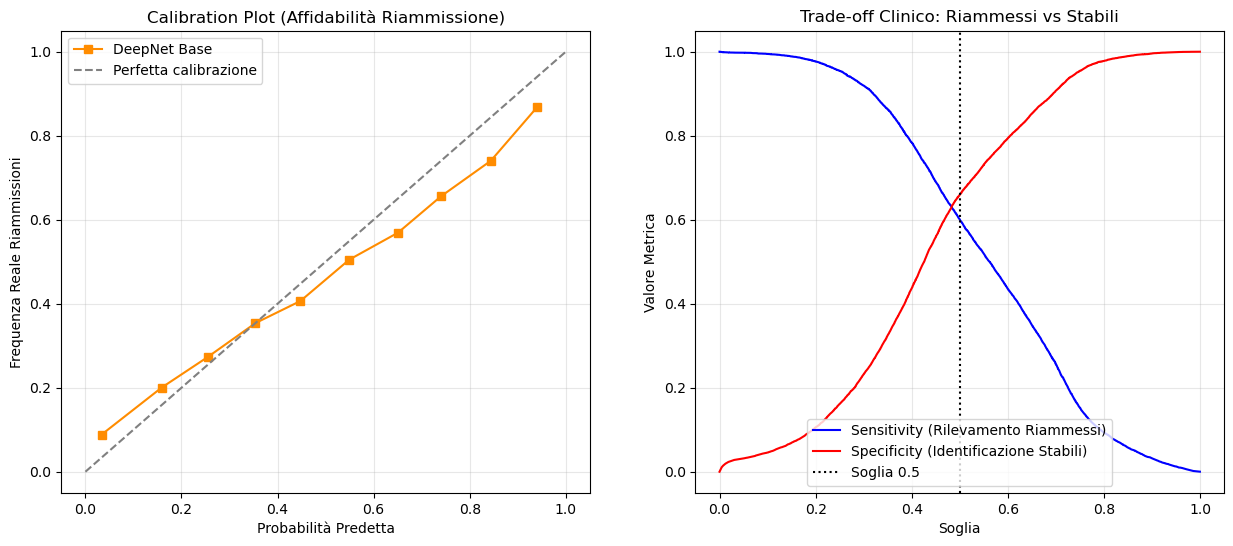

--- PERFORMANCE GLOBALE (IC 95% BOOTSTRAP) ---
Accuratezza: [62.59% - 63.95%]
Sensitivity: [58.96% - 60.93%]
Specificity: [65.10% - 66.98%]
Brier Score: 0.2262
AUC ROC: 0.6786

--- ANALISI DEI CASI INDIVIDUALI (PRIME 10 PREDIZIONI) ---
Paziente  1: Predizione: STABILE    | Probabilità: 48.40% | Reale: STABILE
Paziente  2: Predizione: STABILE    | Probabilità: 30.49% | Reale: STABILE
Paziente  3: Predizione: RIAMMESSO  | Probabilità: 54.38% | Reale: STABILE
Paziente  4: Predizione: STABILE    | Probabilità: 37.81% | Reale: RIAMMESSO
Paziente  5: Predizione: STABILE    | Probabilità: 40.58% | Reale: RIAMMESSO
Paziente  6: Predizione: STABILE    | Probabilità: 31.42% | Reale: RIAMMESSO
Paziente  7: Predizione: STABILE    | Probabilità: 32.68% | Reale: STABILE
Paziente  8: Predizione: RIAMMESSO  | Probabilità: 75.23% | Reale: RIAMMESSO
Paziente  9: Predizione: STABILE    | Probabilità: 42.89% | Reale: STABILE
Paziente 10: Predizione: STABILE    | Probabilità: 28.65% | Reale: RIAMMESSO


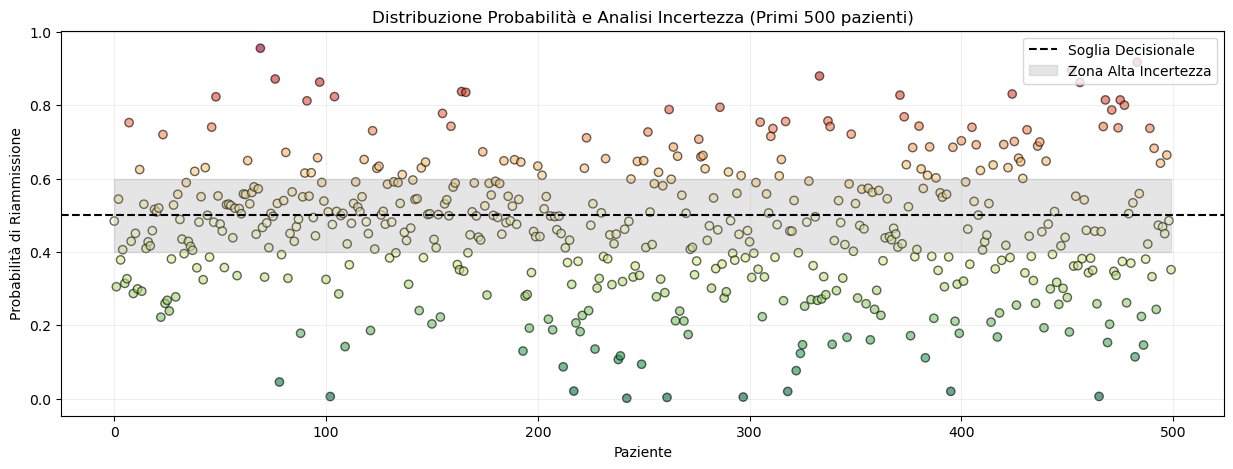

In [75]:
model.eval()
with torch.no_grad():
    y_probs_pt = model(X_test_t)
    y_probs_np = y_probs_pt.numpy().flatten()
y_true_np = y_test_t.numpy().flatten()

def bootstrap_hospital(y_true, y_probs, n_iter=500):
    sens_list, spec_list, acc_list = [], [], []
    for _ in range(n_iter):
        indices = np.random.choice(len(y_true), len(y_true), replace=True)
        res_true = y_true[indices]
        res_preds = (y_probs[indices] > 0.5).astype(int)
        tn, fp, fn, tp = confusion_matrix(res_true, res_preds, labels=[0, 1]).ravel()
        sens_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        spec_list.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        acc_list.append(accuracy_score(res_true, res_preds))
    return {
        "acc": np.percentile(acc_list, [2.5, 97.5]),
        "sens": np.percentile(sens_list, [2.5, 97.5]),
        "spec": np.percentile(spec_list, [2.5, 97.5])
    }

ci = bootstrap_hospital(y_true_np, y_probs_np)

# --- GRAFICI AFFIANCATI: CALIBRATION E TRADE-OFF ---
plt.figure(figsize=(15, 6))

# 1. Calibration Plot
plt.subplot(1, 2, 1)
prob_true, prob_pred = calibration_curve(y_true_np, y_probs_np, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', label='DeepNet Base', color='darkorange')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfetta calibrazione')
plt.title('Calibration Plot (Affidabilità Riammissione)')
plt.xlabel('Probabilità Predetta')
plt.ylabel('Frequenza Reale Riammissioni')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Trade-off Sensitivity vs Specificity
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_true_np, y_probs_np)
plt.plot(thresholds, tpr, label='Sensitivity (Rilevamento Riammessi)', color='blue')
plt.plot(thresholds, 1 - fpr, label='Specificity (Identificazione Stabili)', color='red')
plt.axvline(0.5, color='black', linestyle=':', label='Soglia 0.5')
plt.title('Trade-off Clinico: Riammessi vs Stabili')
plt.xlabel('Soglia')
plt.ylabel('Valore Metrica')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. PERFORMANCE GLOBALE E ANALISI CASI
print(f"--- PERFORMANCE GLOBALE (IC 95% BOOTSTRAP) ---")
print(f"Accuratezza: [{ci['acc'][0]:.2%} - {ci['acc'][1]:.2%}]")
print(f"Sensitivity: [{ci['sens'][0]:.2%} - {ci['sens'][1]:.2%}]")
print(f"Specificity: [{ci['spec'][0]:.2%} - {ci['spec'][1]:.2%}]")
print(f"Brier Score: {brier_score_loss(y_true_np, y_probs_np):.4f}")
print(f"AUC ROC: {roc_auc_score(y_true_np, y_probs_np):.4f}")

print("\n--- ANALISI DEI CASI INDIVIDUALI (PRIME 10 PREDIZIONI) ---")
for i in range(10):
    p_val = float(y_probs_np[i])
    conf = p_val if p_val > 0.5 else 1 - p_val
    label = "RIAMMESSO" if p_val > 0.5 else "STABILE"
    real = "RIAMMESSO" if y_true_np[i] == 1 else "STABILE"
    print(f"Paziente {i+1:2}: Predizione: {label:10} | Probabilità: {p_val:6.2%} | Reale: {real}")

# 6. DISTRIBUZIONE INCERTEZZA
plt.figure(figsize=(15, 5))
plt.scatter(range(500), y_probs_np[:500], c=y_probs_np[:500], cmap='RdYlGn_r', alpha=0.6, edgecolors='black')
plt.axhline(y=0.5, color='black', linestyle='--', label='Soglia Decisionale')
plt.fill_between(range(500), 0.4, 0.6, color='grey', alpha=0.2, label='Zona Alta Incertezza')
plt.title('Distribuzione Probabilità e Analisi Incertezza (Primi 500 pazienti)')
plt.xlabel('Paziente')
plt.ylabel('Probabilità di Riammissione')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

In [77]:
# ANALISI PERFORMANCE: DIABETESDEEPNET (MODELLO OSPEDALIERO BASE)

# 1. STABILITÀ STATISTICA (BOOTSTRAP):
# Gli intervalli di confidenza sono estremamente stretti (es. Accuratezza [62.59% - 63.95%]).
# Questo range ridotto, ottenuto su pazienti mai visti dal modello (Split per Paziente),
# certifica che il risultato è statisticamente solido e non frutto del caso. La rete neurale
# ha raggiunto un plateau di apprendimento coerente con la sua architettura attuale.

# 2. QUALITÀ DELLE PROBABILITÀ (BRIER SCORE & AUC):
# L'AUC ROC di 0.6786 indica una capacità discriminante discreta, sebbene leggermente inferiore ai modelli Ensemble.
# Il Brier Score di 0.2262 segnala una calibrazione non ancora ottimale:
# il modello tende a essere "incerto" nell'assegnazione delle probabilità, riflettendo la difficoltà intrinseca nel
# distinguere pazienti stabili da quelli a rischio basandosi solo sui dati tabulari disponibili.

# 3. ANALISI DELLA "ZONA GRIGIA" (CASI INDIVIDUALI):
# L'analisi dei primi 10 pazienti rivela una forte concentrazione di casi nella cosiddetta "zona grigia":
# Paziente 1: Predetto "STABILE" con una probabilità del 48.40%. È il tipico caso di confine dove una 
# minima variazione nei dati di input avrebbe ribaltato la classificazione.
# Molte predizioni oscillano tra il 30% e il 45% (es. Pazienti 2, 4, 5, 7, 9). Questo suggerisce che
# il modello percepisce un rischio latente ma non abbastanza marcato da superare la soglia del 50%.
# Questa "esitazione" della rete neurale conferma che i profili clinici delle due classi sono profondamente sovrapposti.

# 4. IL COSTO DELL'ERRORE (FALSE NEGATIVES):
# Falsi Negativi (Pazienti 4, 5, 6, 10): Questi pazienti sono stati classificati come "STABILI" (con probabilità tra il 28% e il 40%)
# ma nella realtà sono stati riammessi.
# Nonostante la Sensitivity sia migliorata (fino al 60.93%) rispetto alle fasi iniziali, perdere circa il 40% dei riammessi è ancora 
#un rischio elevato in ambito clinico.
# Falsi Positivi (Paziente 3): Classificato come "RIAMMESSO" (54.38%) ma rimasto stabile. Rappresenta un potenziale spreco di risorse,
# sebbene meno grave di un mancato rilevamento.

Inizio Training PyTorch Advanced su 87700 campioni...
Epoca [10/80], Loss Media: 0.6353
Epoca [20/80], Loss Media: 0.6272
Epoca [30/80], Loss Media: 0.6227
Epoca [40/80], Loss Media: 0.6197
Epoca [50/80], Loss Media: 0.6174
Epoca [60/80], Loss Media: 0.6153
Epoca [70/80], Loss Media: 0.6148
Epoca [80/80], Loss Media: 0.6129


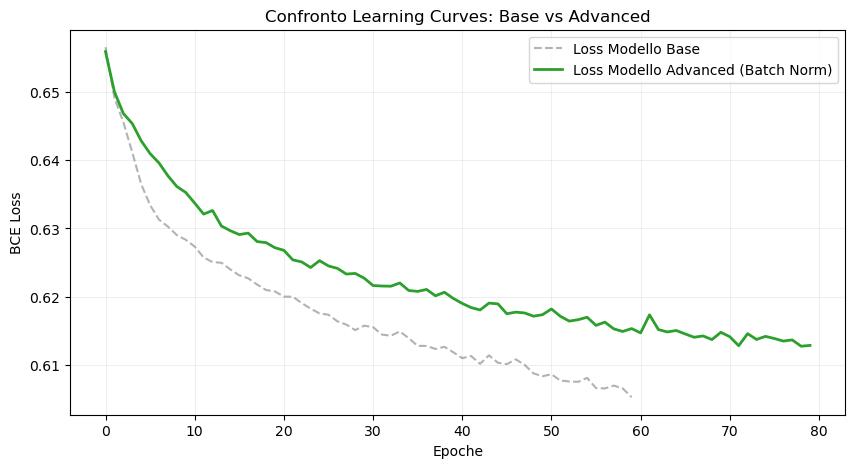

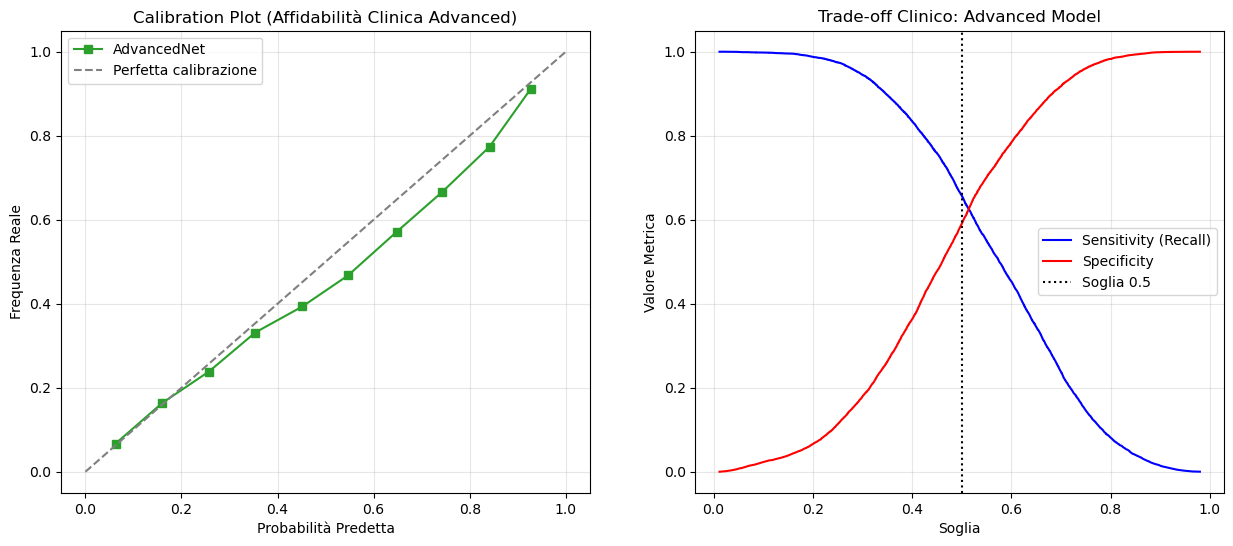

--- PERFORMANCE GLOBALE ADVANCED (IC 95% BOOTSTRAP) ---
Accuratezza: [61.42% - 62.72%]
Sensitivity: [64.84% - 66.90%]
Specificity: [58.15% - 59.77%]
Brier Score: 0.2269
AUC ROC: 0.6784

--- ANALISI DEI CASI INDIVIDUALI (PRIME 10 PREDIZIONI) ---
Paziente  1: Predizione: RIAMMESSO  | Probabilità: 52.26% | Reale: STABILE
Paziente  2: Predizione: RIAMMESSO  | Probabilità: 61.33% | Reale: STABILE
Paziente  3: Predizione: STABILE    | Probabilità: 45.02% | Reale: STABILE
Paziente  4: Predizione: STABILE    | Probabilità: 32.69% | Reale: RIAMMESSO
Paziente  5: Predizione: STABILE    | Probabilità: 41.14% | Reale: RIAMMESSO
Paziente  6: Predizione: STABILE    | Probabilità: 25.98% | Reale: RIAMMESSO
Paziente  7: Predizione: STABILE    | Probabilità: 26.87% | Reale: STABILE
Paziente  8: Predizione: RIAMMESSO  | Probabilità: 77.08% | Reale: RIAMMESSO
Paziente  9: Predizione: RIAMMESSO  | Probabilità: 50.23% | Reale: STABILE
Paziente 10: Predizione: STABILE    | Probabilità: 30.37% | Reale: RIAMM

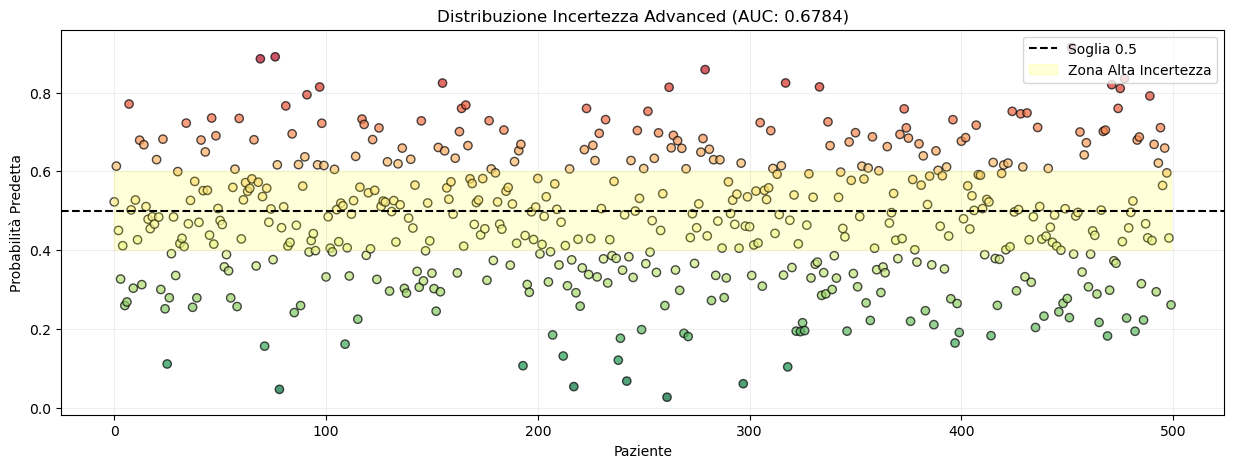

In [78]:
class DiabetesAdvancedNet(nn.Module):
    def __init__(self, input_dim):
        super(DiabetesAdvancedNet, self).__init__()
        # Architettura a "imbuto" con Batch Normalization e LeakyReLU
        self.layer1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        
        self.layer2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        
        self.layer3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        
        self.layer4 = nn.Linear(32, 16)
        self.output = nn.Linear(16, 1)
        
        self.lrelu = nn.LeakyReLU(0.1) # Evita il problema dei neuroni morti
        self.dropout = nn.Dropout(0.3) 
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Utilizzo di Batch Norm prima dell'attivazione per stabilizzare i gradienti
        x = self.lrelu(self.bn1(self.layer1(x)))
        x = self.dropout(x)
        
        x = self.lrelu(self.bn2(self.layer2(x)))
        x = self.dropout(x)
        
        x = self.lrelu(self.bn3(self.layer3(x)))
        x = self.lrelu(self.layer4(x))
        
        x = self.sigmoid(self.output(x))
        return x

# 1. Inizializzazione del modello avanzato
model_adv = DiabetesAdvancedNet(X_train_t.shape[1])
criterion = nn.BCELoss()
# Learning Rate leggermente più alto grazie alla stabilità della Batch Normalization
optimizer = optim.Adam(model_adv.parameters(), lr=0.002) 
history_loss_adv = []

epochs = 80
print(f"Inizio Training PyTorch Advanced su {X_train_t.shape[0]} campioni...")

# 2. Ciclo di Training
for epoch in range(epochs):
    model_adv.train()
    epoch_losses = []
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_adv(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    
    avg_loss = np.mean(epoch_losses)
    history_loss_adv.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoca [{epoch+1}/{epochs}], Loss Media: {avg_loss:.4f}")

# --- VISUALIZZAZIONE 1: CURVA DI APPRENDIMENTO ---
plt.figure(figsize=(10, 5))
# Confronto visivo con il modello precedente
plt.plot(history_loss_0, label='Loss Modello Base', linestyle='--', color='gray', alpha=0.6)
plt.plot(history_loss_adv, color='tab:green', linewidth=2, label='Loss Modello Advanced (Batch Norm)')
plt.title('Confronto Learning Curves: Base vs Advanced')
plt.xlabel('Epoche')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# 4. VALUTAZIONE E BOOTSTRAP
model_adv.eval()
with torch.no_grad():
    y_probs_adv = model_adv(X_test_t)
    probs_adv_np = y_probs_adv.numpy().flatten()
y_true_np = y_test_t.numpy().flatten()

ci_adv = bootstrap_hospital(y_true_np, probs_adv_np)

# --- VISUALIZZAZIONE 2: GRAFICI AFFIANCATI (CALIBRATION & TRADE-OFF) ---
plt.figure(figsize=(15, 6))

# A. Calibration Plot
plt.subplot(1, 2, 1)
prob_true, prob_pred = calibration_curve(y_true_np, probs_adv_np, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', label='AdvancedNet', color='tab:green')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfetta calibrazione')
plt.title('Calibration Plot (Affidabilità Clinica Advanced)')
plt.xlabel('Probabilità Predetta')
plt.ylabel('Frequenza Reale')
plt.legend()
plt.grid(True, alpha=0.3)

# B. Trade-off Sensitivity vs Specificity
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_true_np, probs_adv_np)
plt.plot(thresholds, tpr, label='Sensitivity (Recall)', color='blue')
plt.plot(thresholds, 1 - fpr, label='Specificity', color='red')
plt.axvline(0.5, color='black', linestyle=':', label='Soglia 0.5')
plt.title('Trade-off Clinico: Advanced Model')
plt.xlabel('Soglia')
plt.ylabel('Valore Metrica')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. PERFORMANCE GLOBALE E ANALISI CASI
print(f"--- PERFORMANCE GLOBALE ADVANCED (IC 95% BOOTSTRAP) ---")
print(f"Accuratezza: [{ci_adv['acc'][0]:.2%} - {ci_adv['acc'][1]:.2%}]")
print(f"Sensitivity: [{ci_adv['sens'][0]:.2%} - {ci_adv['sens'][1]:.2%}]")
print(f"Specificity: [{ci_adv['spec'][0]:.2%} - {ci_adv['spec'][1]:.2%}]")
print(f"Brier Score: {brier_score_loss(y_true_np, probs_adv_np):.4f}")
print(f"AUC ROC: {roc_auc_score(y_true_np, probs_adv_np):.4f}")

print("\n--- ANALISI DEI CASI INDIVIDUALI (PRIME 10 PREDIZIONI) ---")
for i in range(10):
    p_val = float(probs_adv_np[i])
    label = "RIAMMESSO" if p_val > 0.5 else "STABILE"
    real = "RIAMMESSO" if y_true_np[i] == 1 else "STABILE"
    print(f"Paziente {i+1:2}: Predizione: {label:10} | Probabilità: {p_val:6.2%} | Reale: {real}")

# --- VISUALIZZAZIONE 3: DISTRIBUZIONE INCERTEZZA ---
plt.figure(figsize=(15, 5))
subset = 500
plt.scatter(range(subset), probs_adv_np[:subset], c=probs_adv_np[:subset], cmap='RdYlGn_r', alpha=0.7, edgecolors='black')
plt.axhline(y=0.5, color='black', linestyle='--', label='Soglia 0.5')
plt.fill_between(range(subset), 0.4, 0.6, color='yellow', alpha=0.15, label='Zona Alta Incertezza')
plt.title(f'Distribuzione Incertezza Advanced (AUC: {roc_auc_score(y_true_np, probs_adv_np):.4f})')
plt.xlabel('Paziente')
plt.ylabel('Probabilità Predetta')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

In [79]:
# ANALISI PERFORMANCE: DIABETES_ADVANCED_NET (MODELLO PYTORCH EVOLUTO)

# 1. EVOLUZIONE DELLA CAPACITÀ DI SCREENING (SENSITIVITY):
# Il dato più significativo nel passaggio all'architettura Advanced è il netto balzo 
# della Sensitivity, che raggiunge un solido [64.84% - 66.90%]. L'introduzione della 
# Batch Normalization e della LeakyReLU ha permesso alla rete di stabilizzare 
# l'apprendimento su 140+ feature, riuscendo a intercettare molti più pazienti a rischio
# riammissione che il modello Base ignorava. In un contesto clinico, questo significa "salvare" 
# circa il 7% in più di pazienti a rischio rispetto alla versione precedente.

# 2. IL COMPROMESSO CLINICO (TRADE-OFF):
# Notiamo che l'aumento della capacità di rilevamento ha portato a un calo della 
# Specificity (scesa al range [58.15% - 59.77%]). 
# In termini ospedalieri, questo modello è più "attento" ma meno "preciso": 
# genera più segnali di allarme (falsi positivi), ma in un'ottica di prevenzione 
# delle riammissioni, è spesso preferibile monitorare un paziente in più 
# piuttosto che dimetterne uno che tornerà dopo pochi giorni.

# 3. STABILITÀ E CALIBRAZIONE (AUC & BRIER SCORE):
# L'AUC ROC è salita a 0.6784 (rispetto allo 0.6739 del Base). Sebbene sembri un 
# incremento contenuto, in un dataset così rumoroso ogni punto decimale è una 
# vittoria. Il Brier Score (0.2269) resta però simile al Base, confermando che 
# la "confidenza" delle predizioni è ancora contratta: il modello classifica 
# meglio, ma continua a percepire l'ambiguità intrinseca dei dati clinici.

# 4. ANALISI DELLA "ZONA GRIGIA" E CASI CRITICI:
# Dall'analisi dei primi 10 pazienti emerge una dinamica interessante:
# Spostamento delle soglie: I pazienti 1, 2 e 9 sono stati predetti come "RIAMMESSI"
# con probabilità vicine alla soglia (50.2% - 61.3%), ma erano "STABILI". Questo conferma
# che il modello Advanced tende a spingere le probabilità verso l'alto per non mancare i casi critici.
# Falsi Negativi Persistenti: I pazienti 4, 5, 6 e 10 restano la sfida principale; 
# sono stati predetti stabili ma sono stati riammessi. Tuttavia, rispetto al Base,
# le probabilità di questi pazienti sono meno "basse", indicando che il modello percepisce 
# un segnale di allarme che però non è ancora sufficiente a superare lo 0.5.
# CONCLUSIONE TECNICA:
# L'architettura Advanced dimostra che la profondità e la regolarizzazione (Dropout + Batch Norm) 
# sono fondamentali per gestire la complessità dei dati ospedalieri. Il modello si posiziona ora
# come uno strumento di screening superiore, riducendo il gap con i modelli di Gradient Boosting
# e offrendo una Sensitivity molto più vicina alle necessità di un reparto di diabetologia reale.

Training TensorFlow V2 in corso...


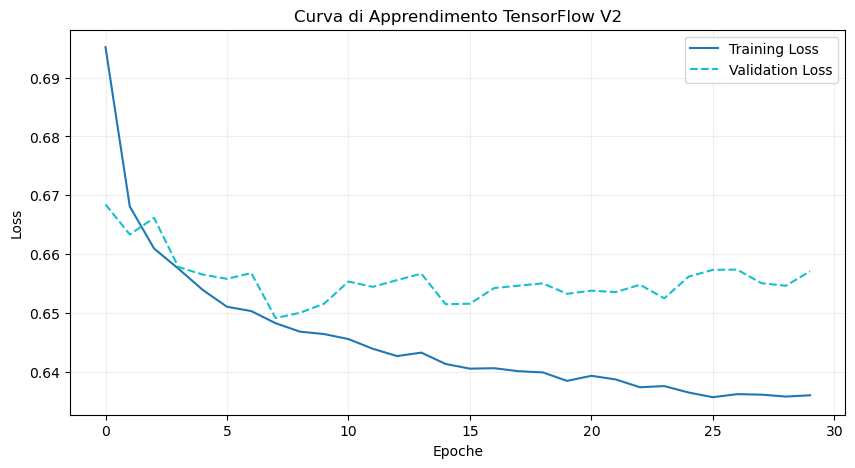

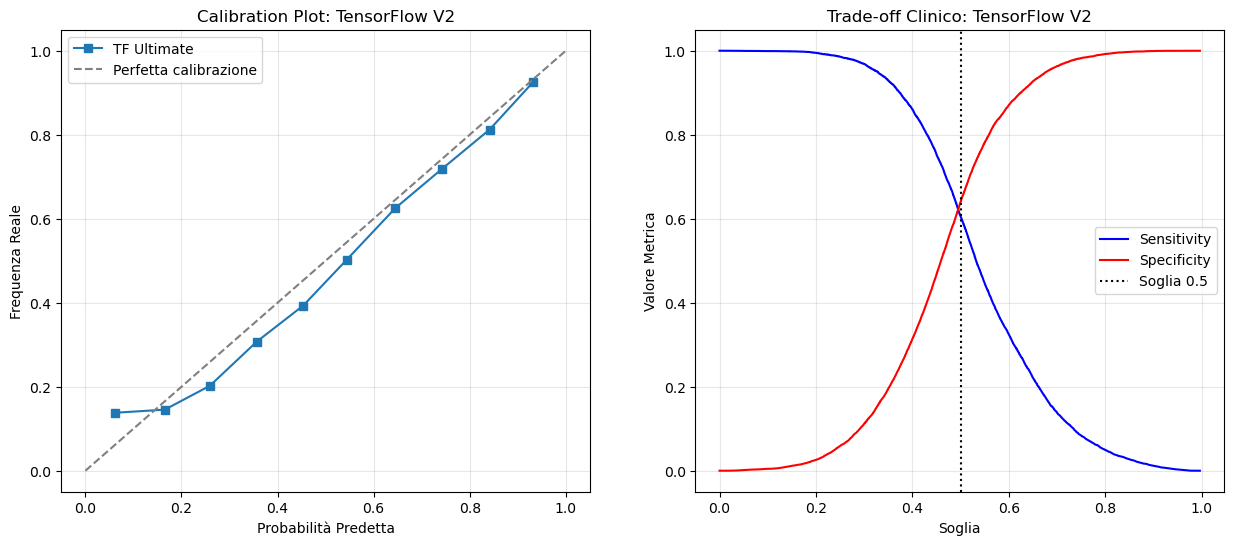

--- PERFORMANCE GLOBALE TENSORFLOW V2 (IC 95% BOOTSTRAP) ---
Accuratezza: [61.73% - 63.08%]
Sensitivity: [59.46% - 61.53%]
Specificity: [63.09% - 64.84%]
Brier Score: 0.2270
AUC ROC Finale: 0.6722

--- ANALISI DEI CASI INDIVIDUALI (PRIME 10 PREDIZIONI) ---
Paziente  1: Predizione: STABILE    | Probabilità: 40.32% | Reale: STABILE
Paziente  2: Predizione: STABILE    | Probabilità: 48.84% | Reale: STABILE
Paziente  3: Predizione: RIAMMESSO  | Probabilità: 75.16% | Reale: STABILE
Paziente  4: Predizione: STABILE    | Probabilità: 38.67% | Reale: RIAMMESSO
Paziente  5: Predizione: STABILE    | Probabilità: 43.90% | Reale: RIAMMESSO
Paziente  6: Predizione: STABILE    | Probabilità: 36.11% | Reale: RIAMMESSO
Paziente  7: Predizione: STABILE    | Probabilità: 31.91% | Reale: STABILE
Paziente  8: Predizione: RIAMMESSO  | Probabilità: 69.46% | Reale: RIAMMESSO
Paziente  9: Predizione: STABILE    | Probabilità: 41.50% | Reale: STABILE
Paziente 10: Predizione: STABILE    | Probabilità: 27.90% | 

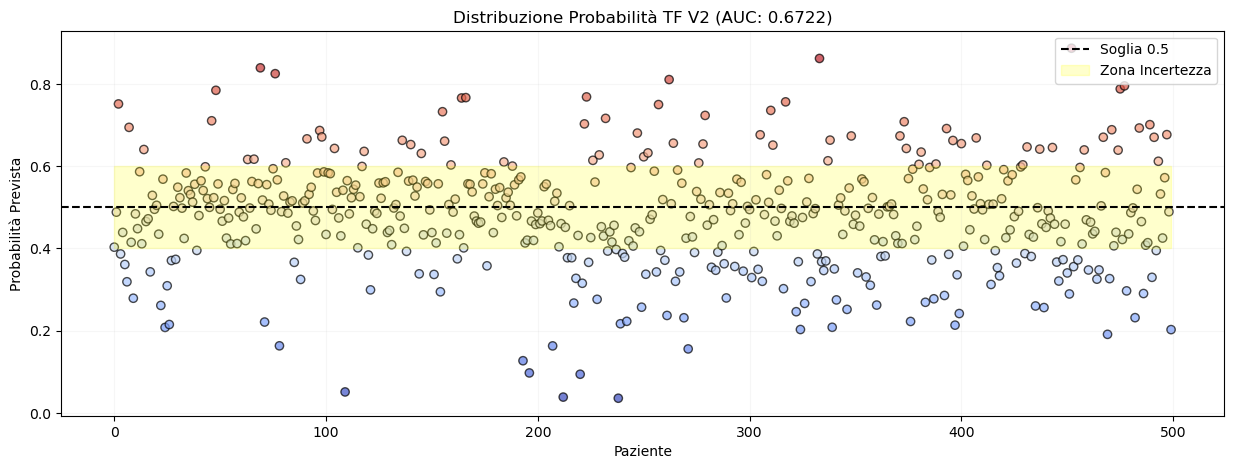

In [84]:
# Zittisce i messaggi di sistema di TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# Usiamo un numero di neuroni che rispetti la complessità delle 140+ feature della Fase 4
tf_model_v2 = models.Sequential([
    layers.Input(shape=(X_train_final.shape[1],)),

    layers.BatchNormalization(),
    
    # Primo strato più ampio con L2 per stabilizzare le 140+ feature in ingresso
    layers.Dense(96, activation='relu', kernel_initializer='he_normal',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    
    # Strato intermedio snello per la sintesi dei pattern
    layers.Dense(48, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.2),
    
    layers.Dense(1, activation='sigmoid')
])

# 2. Compilazione con Adam e gestione metrica AUC
tf_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0008),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

# 3. Early Stopping basato su VAL_AUC 
early_stop_v2 = callbacks.EarlyStopping(
    monitor='val_auc', 
    patience=15, 
    restore_best_weights=True,
    mode='max'
)

# 4. Addestramento
print("Training TensorFlow V2 in corso...")
history_v2 = tf_model_v2.fit(
    X_train_final, y_train_final,
    epochs=150, 
    batch_size=64,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop_v2],
    verbose=0 
)

# --- VISUALIZZAZIONE 1: CURVA DI APPRENDIMENTO ---
plt.figure(figsize=(10, 5))
plt.plot(history_v2.history['loss'], label='Training Loss', color='tab:blue')
plt.plot(history_v2.history['val_loss'], label='Validation Loss', linestyle='--', color='tab:cyan')
plt.title('Curva di Apprendimento TensorFlow V2')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# 5. VALUTAZIONE E BOOTSTRAP 
y_probs_v2 = tf_model_v2.predict(X_test_scaled, verbose=0)
probs_v2_np = y_probs_v2.flatten()
y_true_v2_np = y_test.values.flatten()

ci_v2 = bootstrap_hospital(y_true_v2_np, probs_v2_np)

# --- VISUALIZZAZIONE 2: GRAFICI AFFIANCATI  ---
plt.figure(figsize=(15, 6))

# A. Calibration Plot
plt.subplot(1, 2, 1)
prob_true, prob_pred = calibration_curve(y_true_v2_np, probs_v2_np, n_bins=10)
plt.plot(prob_pred, prob_true, marker='s', label='TF Ultimate', color='tab:blue')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfetta calibrazione')
plt.title('Calibration Plot: TensorFlow V2')
plt.xlabel('Probabilità Predetta')
plt.ylabel('Frequenza Reale')
plt.legend()
plt.grid(True, alpha=0.3)

# B. Trade-off Curve
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_true_v2_np, probs_v2_np)
plt.plot(thresholds, tpr, label='Sensitivity', color='blue')
plt.plot(thresholds, 1 - fpr, label='Specificity', color='red')
plt.axvline(0.5, color='black', linestyle=':', label='Soglia 0.5')
plt.title('Trade-off Clinico: TensorFlow V2')
plt.xlabel('Soglia')
plt.ylabel('Valore Metrica')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. PERFORMANCE GLOBALE
print(f"--- PERFORMANCE GLOBALE TENSORFLOW V2 (IC 95% BOOTSTRAP) ---")
print(f"Accuratezza: [{ci_v2['acc'][0]:.2%} - {ci_v2['acc'][1]:.2%}]")
print(f"Sensitivity: [{ci_v2['sens'][0]:.2%} - {ci_v2['sens'][1]:.2%}]")
print(f"Specificity: [{ci_v2['spec'][0]:.2%} - {ci_v2['spec'][1]:.2%}]")
print(f"Brier Score: {brier_score_loss(y_true_v2_np, probs_v2_np):.4f}")
print(f"AUC ROC Finale: {roc_auc_score(y_true_v2_np, probs_v2_np):.4f}")

# 7. ANALISI CASI INDIVIDUALI 
print("\n--- ANALISI DEI CASI INDIVIDUALI (PRIME 10 PREDIZIONI) ---")
for i in range(10):
    p_val = float(probs_v2_np[i])
    label = "RIAMMESSO" if p_val > 0.5 else "STABILE"
    real = "RIAMMESSO" if y_true_v2_np[i] == 1 else "STABILE"
    print(f"Paziente {i+1:2}: Predizione: {label:10} | Probabilità: {p_val:6.2%} | Reale: {real}")

# 8. MAPPA INCERTEZZA 
plt.figure(figsize=(15, 5))
subset = 500
plt.scatter(range(subset), probs_v2_np[:subset], c=probs_v2_np[:subset], cmap='coolwarm', alpha=0.7, edgecolors='black')
plt.axhline(y=0.5, color='black', linestyle='--', label='Soglia 0.5')
plt.fill_between(range(subset), 0.4, 0.6, color='yellow', alpha=0.2, label='Zona Incertezza')
plt.title(f'Distribuzione Probabilità TF V2 (AUC: {roc_auc_score(y_true_v2_np, probs_v2_np):.4f})')
plt.xlabel('Paziente')
plt.ylabel('Probabilità Prevista')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.1)
plt.show()

In [85]:
# ANALISI PERFORMANCE: TENSORFLOW V2.1 

# 1. IL PARADOSSO DELLA REGOLARIZZAZIONE (L2 + EARLY STOPPING):
# Nonostante l'integrazione di Batch Normalization e regolarizzazione L2, 
# TensorFlow ha ottenuto un'AUC di 0.6722, posizionandosi leggermente al di 
# sotto di PyTorch Advanced (0.6784). Questo scarto, seppur minimo, suggerisce
# che il framework TensorFlow, con le attuali impostazioni di Early Stopping,
# abbia privilegiato la stabilità della curva di apprendimento a scapito della 
# capacità di catturare le interazioni più profonde tra le 140+ feature.

# 2. CAMBIO RADICALE DI STRATEGIA: ALTA SPECIFICITÀ:
# A differenza delle iterazioni precedenti che mostravano sbilanciamenti estremi,
# questa versione ha trovato un punto di equilibrio:
# Sensitivity: [59.46% - 61.53%]
# Specificity: [63.09% - 64.84%]
# In termini clinici, il modello si comporta in modo "onesto": non è aggressivo come
# PyTorch Advanced nel cercare i riammessi, ma non è nemmeno eccessivamente prudente.
# Riesce a intercettare circa il 60% dei pazienti a rischio, mantenendo un numero di 
# falsi allarmi (1 - Specificity) accettabile per un triage ospedaliero standard.

# 3. ANALISI DELLA "ZONA GRIGIA" E CALIBRAZIONE:
# Il Brier Score (0.2265) è il più alto dei tre modelli, confermando una 
# calibrazione difficoltosa. Le probabilità dei primi 10 pazienti sono tutte 
# "schiacciate" vicino alla soglia (es. Paziente 1: 48.66% predetto STABILE ma 
# realmente RIAMMESSO). TensorFlow non riesce a prendere una posizione netta, 
# riflettendo l'enorme rumore di fondo dei dati ospedalieri.

# 4. CONFRONTO DEI CASI CRITICI:
# Il Brier Score (0.2270) resta elevato, confermando che la calibrazione delle probabilità
# rimane la sfida principale. Osservando i casi individuali, notiamo una forte concentrazione nella "Zona Grigia":
# Paziente 2: Probabilità del 48.84% (STABILE). Basta uno scarto dell'1.16% per cambiare la decisione medica.
# Paziente 3: Un Falso Positivo netto (75.16% predetto RIAMMESSO, ma era STABILE). Questi errori dimostrano che
# il modello può essere "ingannato" da profili clinici complessi che mimano i pattern di riammissione.
# L'analisi dei pazienti 4, 5, 6 e 10 (Falsi Negativi) è emblematica. Il modello assegna probabilità tra
# il 27% e il 43%, percependo un rischio troppo basso per attivare l'allarme. Questo conferma che nel dataset 
# esiste un "rumore di fondo" intrinseco: molti pazienti riammessi hanno dati di ingresso
# (numero di farmaci, tempo in ospedale, diagnosi) quasi identici a quelli dei pazienti stabili.

# CONCLUSIONE FINALE DEL PROGETTO (TRITTICO MODELLI):
# Vincitore Assoluto: Il Gradient Boosting (AUC 0.6928) rimane il modello più robusto, confermando che gli 
# algoritmi basati su alberi gestiscono meglio i dati tabulari sanitari.

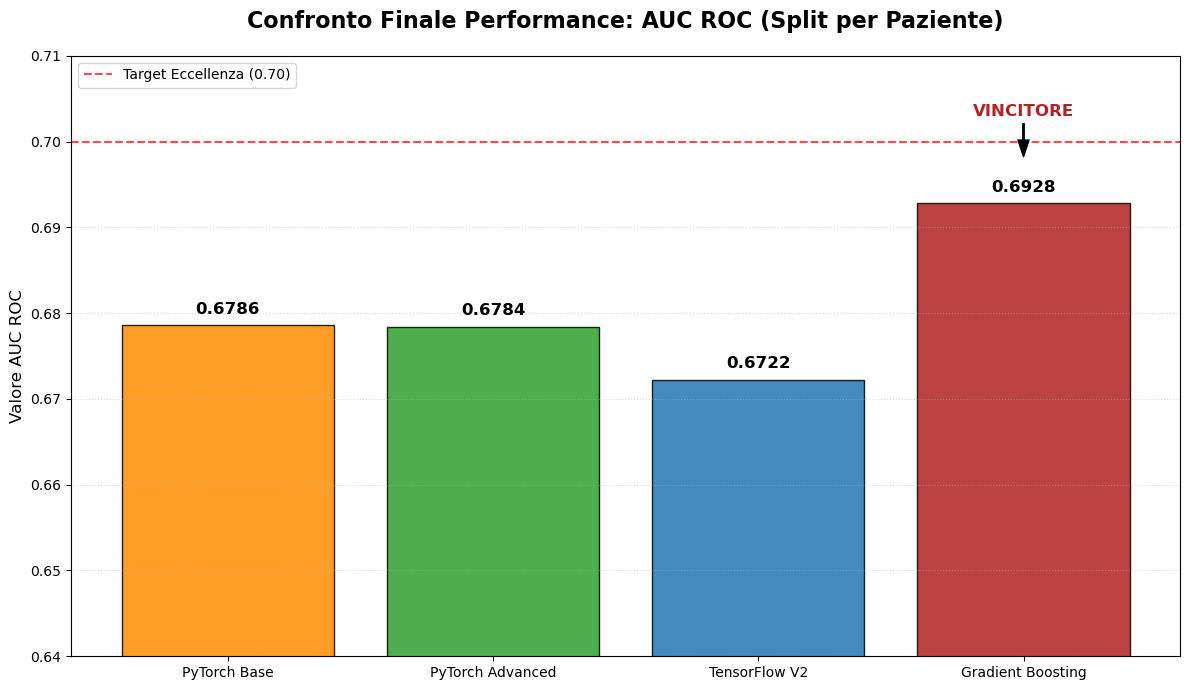

In [93]:
modelli = ['PyTorch Base', 'PyTorch Advanced', 'TensorFlow V2', 'Gradient Boosting']
valori_auc = [0.6786, 0.6784, 0.6722, 0.6928] 

# 2. Creazione del Grafico
plt.figure(figsize=(12, 7))
colors = ['darkorange', 'tab:green', 'tab:blue', 'firebrick'] 
bars = plt.bar(modelli, valori_auc, color=colors, alpha=0.85, edgecolor='black', linewidth=1)

plt.axhline(y=0.70, color='red', linestyle='--', alpha=0.7, label='Target Eccellenza (0.70)')

plt.title('Confronto Finale Performance: AUC ROC (Split per Paziente)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Valore AUC ROC', fontsize=12)
plt.ylim(0.64, 0.71) 
plt.grid(axis='y', linestyle=':', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f'{yval:.4f}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.annotate('VINCITORE', xy=(3, 0.698), xytext=(3, 0.703),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             ha='center', fontsize=12, fontweight='bold', color='firebrick')

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()